# Data Files Upload and Data Cleaning


In [ ]:
"""
Cell 1: Create Project Folder Structure
"""
import os

# Create folder structure in Colab
BASE_PATH = '/content/Rapido_Project/'

folders = [
    'data/raw',
    'data/final',
    'models',
    'visualizations',
    'notebooks'
]

print("📁 Creating folder structure in Colab...")
print("="*60)

for folder in folders:
    folder_path = os.path.join(BASE_PATH, folder)
    os.makedirs(folder_path, exist_ok=True)
    print(f"✅ Created: {folder}")

print("\n" + "="*60)
print("🎉 Folder structure created successfully!")
print(f"\n📂 Base location: {BASE_PATH}")
print("\n📝 Next step: Upload your 5 CSV files using the file upload button")

📁 Creating folder structure in Colab...
✅ Created: data/raw
✅ Created: data/final
✅ Created: models
✅ Created: visualizations
✅ Created: notebooks

🎉 Folder structure created successfully!

📂 Base location: /content/Rapido_Project/

📝 Next step: Upload your 5 CSV files using the file upload button


In [ ]:
"""
Cell 2: Upload CSV Files
Click the 'Choose Files' button and select all 5 CSV files
"""

from google.colab import files
import shutil
import os

print("📤 UPLOAD YOUR CSV FILES")
print("="*60)
print("Please select all 5 CSV files:")
print("  1. bookings.csv")
print("  2. customers.csv")
print("  3. drivers.csv")
print("  4. location_demand.csv")
print("  5. time_features.csv")
print("\n⏳ Waiting for file upload...")
print("="*60)

# Upload files
uploaded = files.upload()

# Move uploaded files to data/raw/
RAW_DATA_PATH = '/content/Rapido_Project/data/raw/'

print("\n📦 Processing uploaded files...")
for filename in uploaded.keys():
    source = f'/content/{filename}'
    destination = os.path.join(RAW_DATA_PATH, filename)
    shutil.move(source, destination)
    size_mb = len(uploaded[filename]) / (1024 * 1024)
    print(f"✅ {filename} ({size_mb:.2f} MB) → {RAW_DATA_PATH}")

print("\n" + "="*60)
print("🎉 All files uploaded successfully!")

# Verify all 5 files
expected_files = ['bookings.csv', 'customers.csv', 'drivers.csv',
                  'location_demand.csv', 'time_features.csv']
print("\n🔍 Verification:")
for csv_file in expected_files:
    file_path = os.path.join(RAW_DATA_PATH, csv_file)
    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  ✅ {csv_file} ({size_mb:.2f} MB)")
    else:
        print(f"  ❌ {csv_file} (missing)")

📤 UPLOAD YOUR CSV FILES
Please select all 5 CSV files:
  1. bookings.csv
  2. customers.csv
  3. drivers.csv
  4. location_demand.csv
  5. time_features.csv

⏳ Waiting for file upload...


Saving time_features.csv to time_features.csv
Saving location_demand.csv to location_demand.csv
Saving drivers.csv to drivers.csv
Saving customers.csv to customers.csv
Saving bookings.csv to bookings.csv

📦 Processing uploaded files...
✅ time_features.csv (0.38 MB) → /content/Rapido_Project/data/raw/
✅ location_demand.csv (1.01 MB) → /content/Rapido_Project/data/raw/
✅ drivers.csv (0.27 MB) → /content/Rapido_Project/data/raw/
✅ customers.csv (0.62 MB) → /content/Rapido_Project/data/raw/
✅ bookings.csv (13.88 MB) → /content/Rapido_Project/data/raw/

🎉 All files uploaded successfully!

🔍 Verification:
  ✅ bookings.csv (13.88 MB)
  ✅ customers.csv (0.62 MB)
  ✅ drivers.csv (0.27 MB)
  ✅ location_demand.csv (1.01 MB)
  ✅ time_features.csv (0.38 MB)


In [ ]:
"""
Cell 3: Install and Import Libraries
"""

# Install additional libraries if needed
print("📦 Installing required libraries...")
!pip install --quiet scikit-learn imbalanced-learn

print("✅ Libraries installed!")

📦 Installing required libraries...
✅ Libraries installed!


In [ ]:
"""
Cell 4: Import All Required Libraries
"""

# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

# Date/Time
from datetime import datetime, timedelta

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency

# File operations
import os
import pickle

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plotting settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

✅ All libraries imported successfully!
📊 Pandas version: 2.2.2
📈 Matplotlib version: 3.10.0
🎨 Seaborn version: 0.13.2


In [ ]:
"""
Cell 5: Define File Paths
Using Colab file system (not Google Drive)
"""

# Define base path
BASE_PATH = '/content/Rapido_Project/'

# Define folder paths
RAW_DATA_PATH = os.path.join(BASE_PATH, 'data/raw/')
FINAL_DATA_PATH = os.path.join(BASE_PATH, 'data/final/')
VIZ_PATH = os.path.join(BASE_PATH, 'visualizations/')
MODEL_PATH = os.path.join(BASE_PATH, 'models/')

print("✅ Paths configured!")
print("="*60)
print(f"📂 Raw data: {RAW_DATA_PATH}")
print(f"📂 Final data: {FINAL_DATA_PATH}")
print(f"📂 Visualizations: {VIZ_PATH}")
print(f"📂 Models: {MODEL_PATH}")
print("\n" + "="*60)

✅ Paths configured!
📂 Raw data: /content/Rapido_Project/data/raw/
📂 Final data: /content/Rapido_Project/data/final/
📂 Visualizations: /content/Rapido_Project/visualizations/
📂 Models: /content/Rapido_Project/models/



In [ ]:
"""
Cell 6: Load All 5 Datasets
"""

print("📥 Loading datasets...")
print("="*60)

try:
    df_bookings = pd.read_csv(os.path.join(RAW_DATA_PATH, 'bookings.csv'))
    print(f"✅ Bookings loaded: {df_bookings.shape[0]:,} rows × {df_bookings.shape[1]} columns")

    df_customers = pd.read_csv(os.path.join(RAW_DATA_PATH, 'customers.csv'))
    print(f"✅ Customers loaded: {df_customers.shape[0]:,} rows × {df_customers.shape[1]} columns")

    df_drivers = pd.read_csv(os.path.join(RAW_DATA_PATH, 'drivers.csv'))
    print(f"✅ Drivers loaded: {df_drivers.shape[0]:,} rows × {df_drivers.shape[1]} columns")

    df_location_demand = pd.read_csv(os.path.join(RAW_DATA_PATH, 'location_demand.csv'))
    print(f"✅ Location Demand loaded: {df_location_demand.shape[0]:,} rows × {df_location_demand.shape[1]} columns")

    df_time_features = pd.read_csv(os.path.join(RAW_DATA_PATH, 'time_features.csv'))
    print(f"✅ Time Features loaded: {df_time_features.shape[0]:,} rows × {df_time_features.shape[1]} columns")

    print("\n" + "="*60)
    print("🎉 All datasets loaded successfully!")

    # Calculate total memory usage
    total_memory = (
        df_bookings.memory_usage(deep=True).sum() +
        df_customers.memory_usage(deep=True).sum() +
        df_drivers.memory_usage(deep=True).sum() +
        df_location_demand.memory_usage(deep=True).sum() +
        df_time_features.memory_usage(deep=True).sum()
    ) / (1024**2)

    print(f"\n💾 Total memory usage: {total_memory:.2f} MB")

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("\n⚠️ Please make sure you uploaded all 5 CSV files in Cell 2")
    print(f"\n📂 Looking in: {RAW_DATA_PATH}")
    if os.path.exists(RAW_DATA_PATH):
        print(f"📄 Files found: {os.listdir(RAW_DATA_PATH)}")
    else:
        print("📂 Directory doesn't exist. Please run Cell 1 first.")

📥 Loading datasets...
✅ Bookings loaded: 100,000 rows × 22 columns
✅ Customers loaded: 10,000 rows × 13 columns
✅ Drivers loaded: 5,000 rows × 14 columns
✅ Location Demand loaded: 17,941 rows × 10 columns
✅ Time Features loaded: 8,760 rows × 7 columns

🎉 All datasets loaded successfully!

💾 Total memory usage: 89.17 MB


In [ ]:
"""
Cell 7: Quick Overview of All Datasets
"""

def dataset_overview(df, name):
    """Display comprehensive overview of a dataset"""
    print(f"\n{'='*70}")
    print(f"📊 {name.upper()} DATASET OVERVIEW")
    print(f"{'='*70}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print(f"\n📋 Columns ({len(df.columns)}):")
    print(df.columns.tolist())

    print(f"\n🔍 First 3 rows:")
    display(df.head(3))

    print(f"\n📊 Data Types:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} columns")

    print(f"\n📈 Basic Statistics:")
    print(f"  Numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")
    print(f"  Object columns: {len(df.select_dtypes(include=['object']).columns)}")
    print(f"  Missing values: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / df.size * 100:.2f}%)")
    print(f"  Duplicate rows: {df.duplicated().sum():,}")

# Overview of each dataset
dataset_overview(df_bookings, "Bookings")
dataset_overview(df_customers, "Customers")
dataset_overview(df_drivers, "Drivers")
dataset_overview(df_location_demand, "Location Demand")
dataset_overview(df_time_features, "Time Features")


📊 BOOKINGS DATASET OVERVIEW
Shape: 100,000 rows × 22 columns
Memory: 78.86 MB

📋 Columns (22):
['booking_id', 'booking_date', 'booking_time', 'day_of_week', 'is_weekend', 'hour_of_day', 'city', 'pickup_location', 'drop_location', 'vehicle_type', 'ride_distance_km', 'estimated_ride_time_min', 'actual_ride_time_min', 'traffic_level', 'weather_condition', 'base_fare', 'surge_multiplier', 'booking_value', 'booking_status', 'incomplete_ride_reason', 'customer_id', 'driver_id']

🔍 First 3 rows:


,booking_id,booking_date,booking_time,day_of_week,is_weekend,hour_of_day,city,pickup_location,drop_location,vehicle_type,ride_distance_km,estimated_ride_time_min,actual_ride_time_min,traffic_level,weather_condition,base_fare,surge_multiplier,booking_value,booking_status,incomplete_ride_reason,customer_id,driver_id
0,B_000001,2025-12-11,00:07:00,Thursday,0,0,Mumbai,Loc_19,Loc_16,Bike,7.01,46.30,NaN,High,Heavy Rain,76.12,2.00,148.22,Cancelled,NaN,C_005097,D_004592
1,B_000002,2025-07-07,06:13:00,Monday,0,6,Mumbai,Loc_32,Loc_38,Cab,9.67,43.54,42.28,Medium,Heavy Rain,254.15,1.80,465.85,Completed,NaN,C_008459,D_000148
2,B_000003,2025-08-23,08:53:00,Saturday,1,8,Chennai,Loc_28,Loc_1,Auto,16.18,48.55,NaN,Low,Heavy Rain,234.20,1.90,457.03,Cancelled,NaN,C_003471,D_004976



📊 Data Types:
  object: 14 columns
  float64: 6 columns
  int64: 2 columns

📈 Basic Statistics:
  Numeric columns: 8
  Object columns: 14
  Missing values: 123,284 (5.60%)
  Duplicate rows: 0

📊 CUSTOMERS DATASET OVERVIEW
Shape: 10,000 rows × 13 columns
Memory: 2.80 MB

📋 Columns (13):
['customer_id', 'customer_gender', 'customer_age', 'customer_city', 'customer_signup_days_ago', 'preferred_vehicle_type', 'total_bookings', 'completed_rides', 'cancelled_rides', 'incomplete_rides', 'cancellation_rate', 'avg_customer_rating', 'customer_cancel_flag']

🔍 First 3 rows:


,customer_id,customer_gender,customer_age,customer_city,customer_signup_days_ago,preferred_vehicle_type,total_bookings,completed_rides,cancelled_rides,incomplete_rides,cancellation_rate,avg_customer_rating,customer_cancel_flag
0,C_000001,Non-Binary,56,Bangalore,556,Cab,10,9,1,0,0.10,3.80,0
1,C_000002,Male,46,Bangalore,82,Bike,8,7,1,0,0.12,4.10,0
2,C_000003,Female,32,Delhi,969,Bike,7,4,1,2,0.14,3.80,0



📊 Data Types:
  int64: 7 columns
  object: 4 columns
  float64: 2 columns

📈 Basic Statistics:
  Numeric columns: 9
  Object columns: 4
  Missing values: 0 (0.00%)
  Duplicate rows: 0

📊 DRIVERS DATASET OVERVIEW
Shape: 5,000 rows × 14 columns
Memory: 1.21 MB

📋 Columns (14):
['driver_id', 'driver_age', 'driver_city', 'vehicle_type', 'driver_experience_years', 'total_assigned_rides', 'accepted_rides', 'incomplete_rides', 'delay_count', 'acceptance_rate', 'delay_rate', 'avg_driver_rating', 'avg_pickup_delay_min', 'driver_delay_flag']

🔍 First 3 rows:


...


📊 Data Types:
  int64: 7 columns
  float64: 4 columns
  object: 3 columns

📈 Basic Statistics:
  Numeric columns: 11
  Object columns: 3
  Missing values: 0 (0.00%)
  Duplicate rows: 0

📊 LOCATION DEMAND DATASET OVERVIEW
Shape: 17,941 rows × 10 columns
Memory: 4.54 MB

📋 Columns (10):
['city', 'pickup_location', 'hour_of_day', 'vehicle_type', 'total_requests', 'completed_rides', 'cancelled_rides', 'avg_wait_time_min', 'avg_surge_multiplier', 'demand_level']

🔍 First 3 rows:


,city,pickup_location,hour_of_day,vehicle_type,total_requests,completed_rides,cancelled_rides,avg_wait_time_min,avg_surge_multiplier,demand_level
0,Bangalore,Loc_1,0,Auto,2,2,0,87.94,1.40,Low
1,Bangalore,Loc_1,0,Bike,5,5,0,68.09,1.46,Low
2,Bangalore,Loc_1,0,Cab,6,5,0,50.91,1.73,Medium



📊 Data Types:
  object: 4 columns
  int64: 4 columns
  float64: 2 columns

📈 Basic Statistics:
  Numeric columns: 6
  Object columns: 4
  Missing values: 0 (0.00%)
  Duplicate rows: 0

📊 TIME FEATURES DATASET OVERVIEW
Shape: 8,760 rows × 7 columns
Memory: 1.77 MB

📋 Columns (7):
['datetime', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_holiday', 'peak_time_flag', 'season']

🔍 First 3 rows:


,datetime,hour_of_day,day_of_week,is_weekend,is_holiday,peak_time_flag,season
0,2025-01-01 00:00:00,0,Wednesday,0,0,0,Winter
1,2025-01-01 01:00:00,1,Wednesday,0,0,0,Winter
2,2025-01-01 02:00:00,2,Wednesday,0,0,0,Winter



📊 Data Types:
  int64: 4 columns
  object: 3 columns

📈 Basic Statistics:
  Numeric columns: 4
  Object columns: 3
  Missing values: 0 (0.00%)
  Duplicate rows: 0


In [ ]:
"""
Cell 8: Detailed Info for Each Dataset
"""

print("="*70)
print("DETAILED DATASET INFORMATION")
print("="*70)

datasets = [
    (df_bookings, "BOOKINGS"),
    (df_customers, "CUSTOMERS"),
    (df_drivers, "DRIVERS"),
    (df_location_demand, "LOCATION DEMAND"),
    (df_time_features, "TIME FEATURES")
]

for df, name in datasets:
    print(f"\n{'='*70}")
    print(f"{name} DATASET - DETAILED INFO")
    print(f"{'='*70}")
    df.info()
    print("\n")

DETAILED DATASET INFORMATION

BOOKINGS DATASET - DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   booking_id               100000 non-null  object 
 1   booking_date             100000 non-null  object 
 2   booking_time             100000 non-null  object 
 3   day_of_week              100000 non-null  object 
 4   is_weekend               100000 non-null  int64  
 5   hour_of_day              100000 non-null  int64  
 6   city                     100000 non-null  object 
 7   pickup_location          100000 non-null  object 
 8   drop_location            100000 non-null  object 
 9   vehicle_type             100000 non-null  object 
 10  ride_distance_km         100000 non-null  float64
 11  estimated_ride_time_min  100000 non-null  float64
 12  actual_ride_time_min     68346 non-null   float64
 1

In [ ]:
"""
Cell 9: Understand Relationships Between Tables
"""

print("🔗 UNDERSTANDING TABLE RELATIONSHIPS")
print("="*70)

# Identify key columns
print("\n📌 Key Columns Analysis:\n")

# Bookings
print("1️⃣ BOOKINGS (Main/Fact Table):")
key_cols_bookings = [col for col in df_bookings.columns if 'id' in col.lower()]
print(f"   Key columns: {key_cols_bookings}")
for col in key_cols_bookings:
    if col in df_bookings.columns:
        print(f"   - {col}: {df_bookings[col].nunique():,} unique values")

# Customers
print("\n2️⃣ CUSTOMERS (Dimension Table):")
key_cols_customers = [col for col in df_customers.columns if 'id' in col.lower()]
print(f"   Key columns: {key_cols_customers}")
for col in key_cols_customers:
    if col in df_customers.columns:
        print(f"   - {col}: {df_customers[col].nunique():,} unique values")

# Drivers
print("\n3️⃣ DRIVERS (Dimension Table):")
key_cols_drivers = [col for col in df_drivers.columns if 'id' in col.lower()]
print(f"   Key columns: {key_cols_drivers}")
for col in key_cols_drivers:
    if col in df_drivers.columns:
        print(f"   - {col}: {df_drivers[col].nunique():,} unique values")

# Location Demand
print("\n4️⃣ LOCATION DEMAND (Lookup Table):")
print(f"   Columns: {df_location_demand.columns.tolist()}")
print(f"   Rows: {len(df_location_demand):,}")

# Time Features
print("\n5️⃣ TIME FEATURES (Lookup Table):")
print(f"   Columns: {df_time_features.columns.tolist()}")
print(f"   Rows: {len(df_time_features):,}")

# Relationship diagram
print("\n" + "="*70)
print("💡 RELATIONSHIP STRUCTURE:")
print("="*70)
print("""
   BOOKINGS (Fact Table - Main)
   ├── customer_id → CUSTOMERS (dimension)
   ├── driver_id → DRIVERS (dimension)
   ├── pickup_location/drop_location → LOCATION_DEMAND (lookup)
   └── booking_time/date → TIME_FEATURES (lookup)

   This is a STAR SCHEMA design pattern.
""")

🔗 UNDERSTANDING TABLE RELATIONSHIPS

📌 Key Columns Analysis:

1️⃣ BOOKINGS (Main/Fact Table):
   Key columns: ['booking_id', 'ride_distance_km', 'estimated_ride_time_min', 'actual_ride_time_min', 'incomplete_ride_reason', 'customer_id', 'driver_id']
   - booking_id: 100,000 unique values
   - ride_distance_km: 2,401 unique values
   - estimated_ride_time_min: 15,591 unique values
   - actual_ride_time_min: 15,370 unique values
   - incomplete_ride_reason: 4 unique values
   - customer_id: 10,000 unique values
   - driver_id: 5,000 unique values

2️⃣ CUSTOMERS (Dimension Table):
   Key columns: ['customer_id', 'completed_rides', 'cancelled_rides', 'incomplete_rides']
   - customer_id: 10,000 unique values
   - completed_rides: 21 unique values
   - cancelled_rides: 11 unique values
   - incomplete_rides: 6 unique values

3️⃣ DRIVERS (Dimension Table):
   Key columns: ['driver_id', 'total_assigned_rides', 'accepted_rides', 'incomplete_rides']
   - driver_id: 5,000 unique values
   - tota

In [ ]:
"""
Cell 10: Check for Duplicates
"""

print("🔍 CHECKING FOR DUPLICATES")
print("="*70)

def check_duplicates(df, name, id_column=None):
    """Check for duplicate rows and duplicate IDs"""
    print(f"\n📊 {name}:")

    # Duplicate rows
    dup_rows = df.duplicated().sum()
    dup_pct = (dup_rows / len(df)) * 100
    print(f"   Duplicate rows: {dup_rows:,} ({dup_pct:.2f}%)")

    # Duplicate IDs
    if id_column and id_column in df.columns:
        dup_ids = df[id_column].duplicated().sum()
        dup_id_pct = (dup_ids / len(df)) * 100
        print(f"   Duplicate {id_column}: {dup_ids:,} ({dup_id_pct:.2f}%)")
        if dup_ids > 0:
            print(f"      ⚠️ Warning: Found duplicate IDs!")
            # Show examples
            dup_id_examples = df[df[id_column].duplicated(keep=False)][id_column].head(5).tolist()
            print(f"      Examples: {dup_id_examples}")

    return dup_rows, dup_ids if id_column else 0

# Check each dataset
dup_bookings_rows, dup_bookings_ids = check_duplicates(df_bookings, "Bookings", "booking_id")
dup_customers_rows, dup_customers_ids = check_duplicates(df_customers, "Customers", "customer_id")
dup_drivers_rows, dup_drivers_ids = check_duplicates(df_drivers, "Drivers", "driver_id")
dup_location_rows, _ = check_duplicates(df_location_demand, "Location Demand")
dup_time_rows, _ = check_duplicates(df_time_features, "Time Features")

# Summary
print("\n" + "="*70)
total_dup_rows = dup_bookings_rows + dup_customers_rows + dup_drivers_rows + dup_location_rows + dup_time_rows
total_dup_ids = dup_bookings_ids + dup_customers_ids + dup_drivers_ids

if total_dup_rows == 0 and total_dup_ids == 0:
    print("✅ No duplicates found in any dataset!")
else:
    print(f"⚠️ Found {total_dup_rows:,} duplicate rows and {total_dup_ids:,} duplicate IDs")
    print("   These will be handled in the cleaning section")

🔍 CHECKING FOR DUPLICATES

📊 Bookings:
   Duplicate rows: 0 (0.00%)
   Duplicate booking_id: 0 (0.00%)

📊 Customers:
   Duplicate rows: 0 (0.00%)
   Duplicate customer_id: 0 (0.00%)

📊 Drivers:
   Duplicate rows: 0 (0.00%)
   Duplicate driver_id: 0 (0.00%)

📊 Location Demand:
   Duplicate rows: 0 (0.00%)

📊 Time Features:
   Duplicate rows: 0 (0.00%)

✅ No duplicates found in any dataset!


In [ ]:
"""
Cell 11: Missing Values Analysis
"""

print("🔍 MISSING VALUES ANALYSIS")
print("="*70)

def missing_value_analysis(df, name):
    """Analyze and display missing values"""
    print(f"\n📊 {name}:")

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_pct.values
    })

    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

    if len(missing_df) == 0:
        print("   ✅ No missing values!")
        return None
    else:
        print(f"   ⚠️ Found missing values in {len(missing_df)} columns:")
        display(missing_df.style.background_gradient(cmap='Reds', subset=['Missing_Percentage']))
        return missing_df

# Analyze each dataset
missing_bookings = missing_value_analysis(df_bookings, "Bookings")
missing_customers = missing_value_analysis(df_customers, "Customers")
missing_drivers = missing_value_analysis(df_drivers, "Drivers")
missing_location = missing_value_analysis(df_location_demand, "Location Demand")
missing_time = missing_value_analysis(df_time_features, "Time Features")

# Summary
print("\n" + "="*70)
print("📊 MISSING VALUES SUMMARY:")
print("="*70)
datasets_with_missing = [
    ("Bookings", missing_bookings),
    ("Customers", missing_customers),
    ("Drivers", missing_drivers),
    ("Location Demand", missing_location),
    ("Time Features", missing_time)
]

for name, missing_df in datasets_with_missing:
    if missing_df is not None:
        total_missing = missing_df['Missing_Count'].sum()
        print(f"  {name}: {total_missing:,} missing values across {len(missing_df)} columns")
    else:
        print(f"  {name}: ✅ No missing values")

🔍 MISSING VALUES ANALYSIS

📊 Bookings:
   ⚠️ Found missing values in 2 columns:


,Column,Missing_Count,Missing_Percentage
19,incomplete_ride_reason,91630,91.630000
12,actual_ride_time_min,31654,31.654000



📊 Customers:
   ✅ No missing values!

📊 Drivers:
   ✅ No missing values!

📊 Location Demand:
   ✅ No missing values!

📊 Time Features:
   ✅ No missing values!

📊 MISSING VALUES SUMMARY:
  Bookings: 123,284 missing values across 2 columns
  Customers: ✅ No missing values
  Drivers: ✅ No missing values
  Location Demand: ✅ No missing values
  Time Features: ✅ No missing values


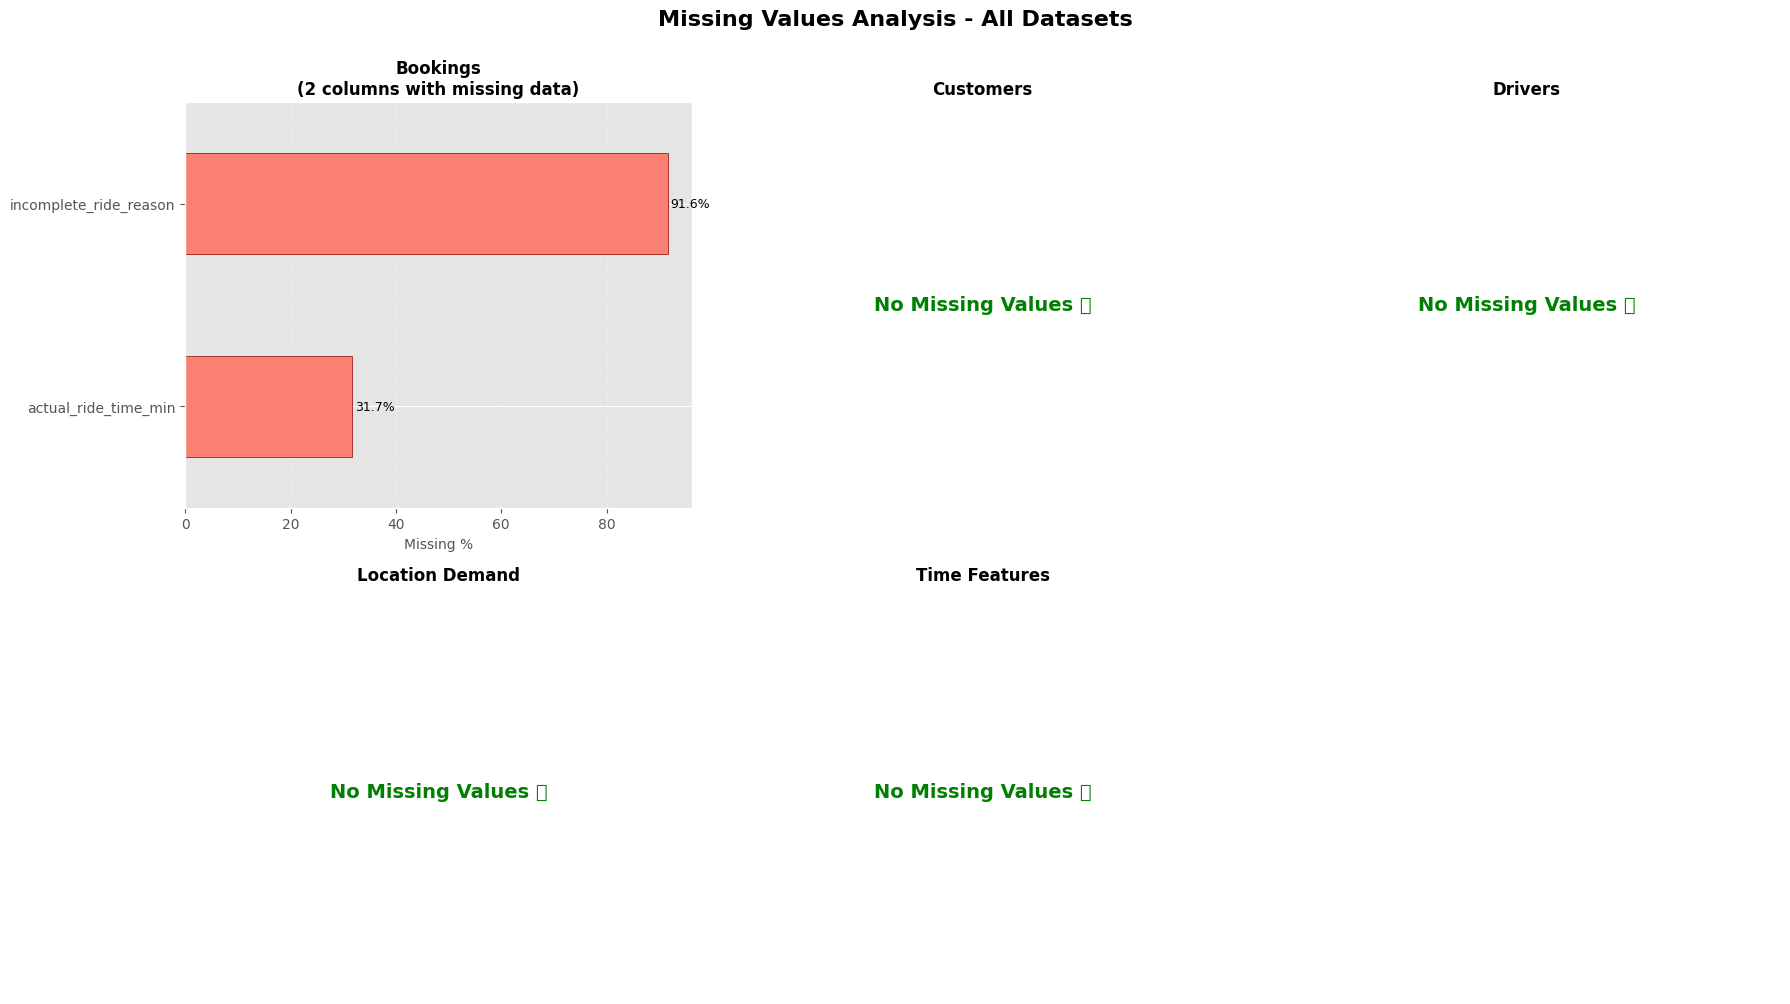

💾 Visualization saved: /content/Rapido_Project/visualizations/missing_values_heatmap.png


In [ ]:
"""
Cell 12: Visualize Missing Values
"""

# Create visualizations for missing values
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Missing Values Analysis - All Datasets', fontsize=16, fontweight='bold', y=1.00)
axes = axes.flatten()

datasets = [
    (df_bookings, "Bookings", axes[0]),
    (df_customers, "Customers", axes[1]),
    (df_drivers, "Drivers", axes[2]),
    (df_location_demand, "Location Demand", axes[3]),
    (df_time_features, "Time Features", axes[4])
]

for df, name, ax in datasets:
    # Calculate missing percentage
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

    if len(missing_pct) == 0:
        # No missing values
        ax.text(0.5, 0.5, 'No Missing Values ✅',
                ha='center', va='center', fontsize=14,
                transform=ax.transAxes, color='green', fontweight='bold')
        ax.set_title(name, fontweight='bold', fontsize=12)
        ax.axis('off')
    else:
        # Plot missing values
        missing_pct.plot(kind='barh', ax=ax, color='salmon', edgecolor='darkred')
        ax.set_title(f'{name}\n({len(missing_pct)} columns with missing data)',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Missing %', fontsize=10)
        ax.grid(axis='x', alpha=0.3, linestyle='--')

        # Add percentage labels
        for i, v in enumerate(missing_pct):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_PATH, 'missing_values_heatmap.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print(f"💾 Visualization saved: {os.path.join(VIZ_PATH, 'missing_values_heatmap.png')}")

In [ ]:
"""
Cell 13: Data Type Analysis - Identify Type Issues
"""

print("🔍 DATA TYPE ANALYSIS")
print("="*70)

def analyze_data_types(df, name):
    """Identify potential data type issues"""
    print(f"\n📊 {name}:")

    # Datetime candidates
    datetime_cols = [col for col in df.columns
                     if any(keyword in col.lower() for keyword in ['date', 'time', 'timestamp', 'datetime'])]

    if datetime_cols:
        print(f"\n   📅 Potential datetime columns ({len(datetime_cols)}):")
        for col in datetime_cols:
            current_type = df[col].dtype
            print(f"      - {col}: {current_type}", end="")
            if current_type == 'object':
                print(" ⚠️ (should be datetime)")
            elif 'datetime' in str(current_type):
                print(" ✅")
            else:
                print()

    # Numeric columns stored as object
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    numeric_candidates = []

    for col in object_cols:
        if col not in datetime_cols:
            # Sample to check if numeric
            sample = df[col].dropna().head(100)
            try:
                pd.to_numeric(sample, errors='raise')
                numeric_candidates.append(col)
            except:
                pass

    if numeric_candidates:
        print(f"\n   🔢 Potential numeric columns stored as object ({len(numeric_candidates)}):")
        for col in numeric_candidates:
            print(f"      - {col} ⚠️")

    # Categorical columns
    categorical_candidates = []
    for col in object_cols:
        if col not in datetime_cols and col not in numeric_candidates:
            unique_count = df[col].nunique()
            if unique_count < 20:
                categorical_candidates.append((col, unique_count))

    if categorical_candidates:
        print(f"\n   🏷️ Categorical columns ({len(categorical_candidates)}):")
        for col, unique in categorical_candidates:
            print(f"      - {col}: {unique} unique values")
            if unique <= 10:
                print(f"        Values: {df[col].unique()[:10].tolist()}")

    return datetime_cols, numeric_candidates, categorical_candidates

# Analyze each dataset
print("\n" + "="*70)
dt_cols_b, num_cols_b, cat_cols_b = analyze_data_types(df_bookings, "Bookings")
dt_cols_c, num_cols_c, cat_cols_c = analyze_data_types(df_customers, "Customers")
dt_cols_d, num_cols_d, cat_cols_d = analyze_data_types(df_drivers, "Drivers")
dt_cols_l, num_cols_l, cat_cols_l = analyze_data_types(df_location_demand, "Location Demand")
dt_cols_t, num_cols_t, cat_cols_t = analyze_data_types(df_time_features, "Time Features")

🔍 DATA TYPE ANALYSIS


📊 Bookings:

   📅 Potential datetime columns (4):
      - booking_date: object ⚠️ (should be datetime)
      - booking_time: object ⚠️ (should be datetime)
      - estimated_ride_time_min: float64
      - actual_ride_time_min: float64

   🏷️ Categorical columns (7):
      - day_of_week: 7 unique values
        Values: ['Thursday', 'Monday', 'Saturday', 'Tuesday', 'Sunday', 'Wednesday', 'Friday']
      - city: 5 unique values
        Values: ['Mumbai', 'Chennai', 'Delhi', 'Hyderabad', 'Bangalore']
      - vehicle_type: 3 unique values
        Values: ['Bike', 'Cab', 'Auto']
      - traffic_level: 3 unique values
        Values: ['High', 'Medium', 'Low']
      - weather_condition: 3 unique values
        Values: ['Heavy Rain', 'Rain', 'Clear']
      - booking_status: 3 unique values
        Values: ['Cancelled', 'Completed', 'Incomplete']
      - incomplete_ride_reason: 4 unique values
        Values: [nan, 'Driver Delay', 'App Issue', 'Customer No-show', 'Vehicle 

In [ ]:
"""
Cell 14: Outlier Detection Using IQR Method
"""

print("🔍 OUTLIER DETECTION")
print("="*70)

def detect_outliers_iqr(df, columns, name):
    """Detect outliers using IQR method"""
    print(f"\n📊 {name}:")

    outlier_summary = []

    for col in columns:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            # Calculate IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Find outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outlier_count = len(outliers)
            outlier_pct = (outlier_count / len(df)) * 100

            outlier_summary.append({
                'Column': col,
                'Count': outlier_count,
                'Percentage': outlier_pct,
                'Min': df[col].min(),
                'Q1': Q1,
                'Median': df[col].median(),
                'Q3': Q3,
                'Max': df[col].max(),
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })

            if outlier_count > 0:
                print(f"\n   📈 {col}:")
                print(f"      Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
                print(f"      IQR: {IQR:.2f} | Q1: {Q1:.2f} | Q3: {Q3:.2f}")
                print(f"      Normal range: [{lower_bound:.2f}, {upper_bound:.2f}]")
                print(f"      Outliers: {outlier_count:,} ({outlier_pct:.2f}%)")

                if outlier_count > 0 and outlier_count < 10:
                    print(f"      Outlier values: {outliers[col].values}")
                elif outlier_count >= 10:
                    print(f"      Extreme values (top 5): {df[col].nlargest(5).values}")

    if outlier_summary:
        return pd.DataFrame(outlier_summary)
    return None

# Detect outliers in bookings dataset
numeric_cols_bookings = df_bookings.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns
numeric_cols_bookings = [col for col in numeric_cols_bookings if 'id' not in col.lower()]

outlier_summary = detect_outliers_iqr(df_bookings, numeric_cols_bookings, "Bookings")

if outlier_summary is not None:
    print("\n" + "="*70)
    print("📊 OUTLIER SUMMARY TABLE:")
    print("="*70)
    display(outlier_summary[['Column', 'Count', 'Percentage', 'Min', 'Max', 'Lower_Bound', 'Upper_Bound']])

🔍 OUTLIER DETECTION

📊 Bookings:

   📈 booking_value:
      Range: [27.28, 1265.59]
      IQR: 269.26 | Q1: 179.21 | Q3: 448.47
      Normal range: [-224.68, 852.36]
      Outliers: 2,541 (2.54%)
      Extreme values (top 5): [1265.59 1259.28 1257.67 1254.51 1252.67]

📊 OUTLIER SUMMARY TABLE:


,Column,Count,Percentage,Min,Max,Lower_Bound,Upper_Bound
0,is_weekend,0,0.00,0.00,1.00,-1.50,2.50
1,hour_of_day,0,0.00,0.00,23.00,-13.00,35.00
2,base_fare,0,0.00,28.02,529.96,-134.62,540.71
3,surge_multiplier,0,0.00,1.00,2.30,0.55,2.55
4,booking_value,2541,2.54,27.28,1265.59,-224.68,852.36


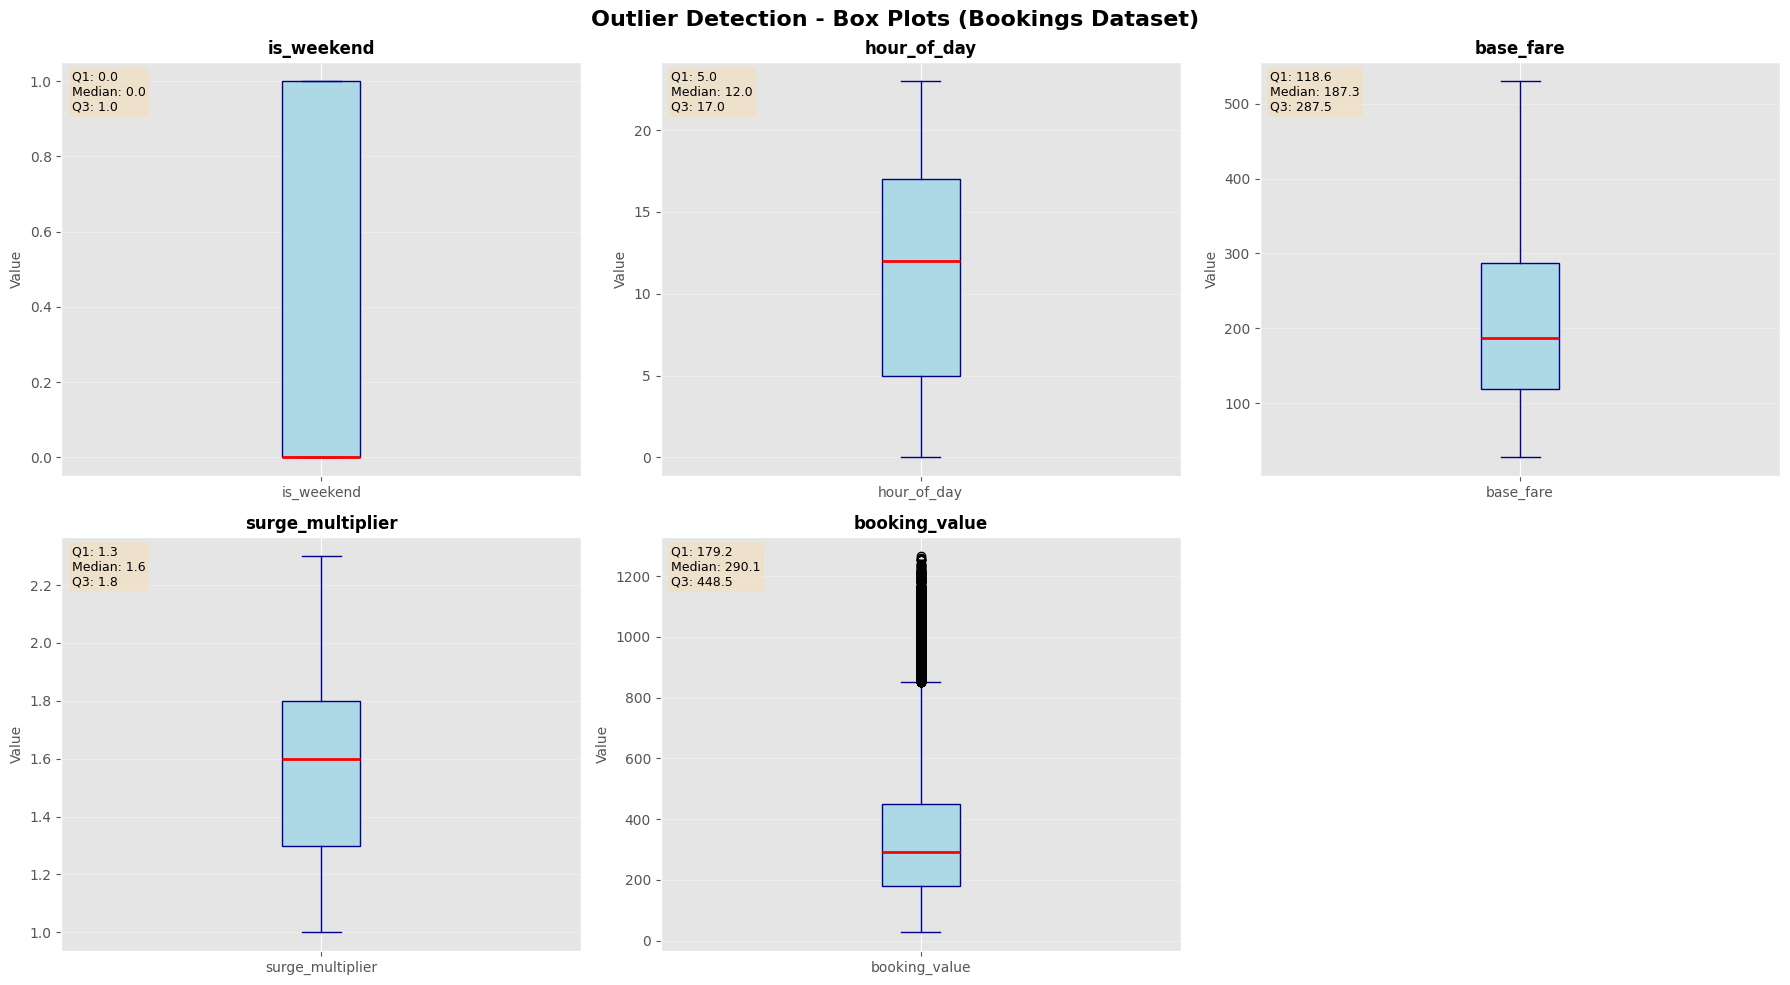

💾 Box plots saved: /content/Rapido_Project/visualizations/outliers_boxplots.png


In [ ]:
"""
Cell 15: Visualize Outliers Using Box Plots
"""

# Get numeric columns from bookings
numeric_cols = df_bookings.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if 'id' not in col.lower()]

if len(numeric_cols) > 0:
    # Create box plots
    n_cols = min(len(numeric_cols), 6)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Outlier Detection - Box Plots (Bookings Dataset)',
                 fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols[:6]):
        if idx < len(axes):
            # Box plot
            df_bookings.boxplot(column=col, ax=axes[idx], patch_artist=True,
                               boxprops=dict(facecolor='lightblue', color='darkblue'),
                               medianprops=dict(color='red', linewidth=2),
                               whiskerprops=dict(color='darkblue'),
                               capprops=dict(color='darkblue'))

            axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
            axes[idx].set_ylabel('Value', fontsize=10)
            axes[idx].grid(alpha=0.3, axis='y')

            # Add statistics
            q1 = df_bookings[col].quantile(0.25)
            median = df_bookings[col].median()
            q3 = df_bookings[col].quantile(0.75)
            axes[idx].text(0.02, 0.98, f'Q1: {q1:.1f}\nMedian: {median:.1f}\nQ3: {q3:.1f}',
                          transform=axes[idx].transAxes,
                          verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                          fontsize=9)

    # Hide unused subplots
    for idx in range(len(numeric_cols[:6]), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'outliers_boxplots.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"💾 Box plots saved: {os.path.join(VIZ_PATH, 'outliers_boxplots.png')}")
else:
    print("⚠️ No numeric columns found for box plots")

In [ ]:
"""
Cell 16: Remove Duplicates
"""

print("🧹 REMOVING DUPLICATES")
print("="*70)

def remove_duplicates(df, name, id_column=None):
    """Remove duplicate rows and duplicate IDs"""
    original_shape = df.shape

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove duplicate IDs if specified
    if id_column and id_column in df.columns:
        df = df.drop_duplicates(subset=[id_column], keep='first')

    new_shape = df.shape
    rows_removed = original_shape[0] - new_shape[0]

    print(f"\n{name}:")
    print(f"   Original: {original_shape[0]:,} rows × {original_shape[1]} columns")
    print(f"   After cleaning: {new_shape[0]:,} rows × {new_shape[1]} columns")
    print(f"   Removed: {rows_removed:,} rows", end="")

    if rows_removed > 0:
        print(" ✅")
    else:
        print(" (no duplicates found)")

    return df

# Remove duplicates from each dataset
df_bookings = remove_duplicates(df_bookings, "Bookings", "booking_id")
df_customers = remove_duplicates(df_customers, "Customers", "customer_id")
df_drivers = remove_duplicates(df_drivers, "Drivers", "driver_id")
df_location_demand = remove_duplicates(df_location_demand, "Location Demand")
df_time_features = remove_duplicates(df_time_features, "Time Features")

print("\n" + "="*70)
print("✅ Duplicate removal completed for all datasets!")

🧹 REMOVING DUPLICATES

Bookings:
   Original: 100,000 rows × 22 columns
   After cleaning: 100,000 rows × 22 columns
   Removed: 0 rows (no duplicates found)

Customers:
   Original: 10,000 rows × 13 columns
   After cleaning: 10,000 rows × 13 columns
   Removed: 0 rows (no duplicates found)

Drivers:
   Original: 5,000 rows × 14 columns
   After cleaning: 5,000 rows × 14 columns
   Removed: 0 rows (no duplicates found)

Location Demand:
   Original: 17,941 rows × 10 columns
   After cleaning: 17,941 rows × 10 columns
   Removed: 0 rows (no duplicates found)

Time Features:
   Original: 8,760 rows × 7 columns
   After cleaning: 8,760 rows × 7 columns
   Removed: 0 rows (no duplicates found)

✅ Duplicate removal completed for all datasets!


In [ ]:
"""
Cell 17: Convert Datetime Columns
"""

print("🔧 FIXING DATA TYPES - DATETIME COLUMNS")
print("="*70)

def convert_to_datetime(df, columns, name):
    """Convert columns to datetime format"""
    print(f"\n{name}:")

    for col in columns:
        if col in df.columns:
            try:
                original_type = df[col].dtype

                # Try conversion
                df[col] = pd.to_datetime(df[col], errors='coerce')

                # Check for NaT values
                nat_count = df[col].isna().sum()

                print(f"   ✅ {col}: {original_type} → datetime64[ns]", end="")

                if nat_count > 0:
                    print(f" (⚠️ {nat_count} values couldn't be converted)")
                else:
                    print()

            except Exception as e:
                print(f"   ❌ {col}: Failed - {str(e)}")

    return df

# Identify and convert datetime columns
# Adjust these lists based on your actual column names
datetime_cols_bookings = [col for col in df_bookings.columns
                          if any(keyword in col.lower() for keyword in ['date', 'time', 'timestamp'])]
datetime_cols_time = [col for col in df_time_features.columns
                      if any(keyword in col.lower() for keyword in ['date', 'time', 'timestamp'])]

if datetime_cols_bookings:
    df_bookings = convert_to_datetime(df_bookings, datetime_cols_bookings, "Bookings")

if datetime_cols_time:
    df_time_features = convert_to_datetime(df_time_features, datetime_cols_time, "Time Features")

print("\n" + "="*70)
print("✅ Datetime conversions completed!")

🔧 FIXING DATA TYPES - DATETIME COLUMNS

Bookings:
   ✅ booking_date: object → datetime64[ns]
   ✅ booking_time: object → datetime64[ns]
   ✅ estimated_ride_time_min: float64 → datetime64[ns]
   ✅ actual_ride_time_min: float64 → datetime64[ns] (⚠️ 31654 values couldn't be converted)

Time Features:
   ✅ datetime: object → datetime64[ns]
   ✅ peak_time_flag: int64 → datetime64[ns]

✅ Datetime conversions completed!


In [ ]:
"""
Cell 18: Fix Numeric and Categorical Data Types
"""

print("🔧 FIXING DATA TYPES - NUMERIC & CATEGORICAL")
print("="*70)

# Function to convert to numeric
def convert_to_numeric(df, columns, name):
    """Convert columns to numeric format"""
    print(f"\n{name} - Numeric Conversions:")

    for col in columns:
        if col in df.columns:
            try:
                original_type = df[col].dtype
                df[col] = pd.to_numeric(df[col], errors='coerce')

                nan_count = df[col].isna().sum()
                print(f"   ✅ {col}: {original_type} → numeric", end="")

                if nan_count > 0:
                    print(f" (⚠️ {nan_count} NaN created)")
                else:
                    print()

            except Exception as e:
                print(f"   ❌ {col}: Failed - {str(e)}")

    return df

# Function to clean categorical
def clean_categorical(df, columns, name):
    """Clean categorical columns"""
    print(f"\n{name} - Categorical Cleaning:")

    for col in columns:
        if col in df.columns:
            # Convert to string
            df[col] = df[col].astype(str)

            # Remove leading/trailing spaces
            df[col] = df[col].str.strip()

            # Replace 'nan' string with actual NaN
            df[col] = df[col].replace('nan', np.nan)

            unique_count = df[col].nunique()
            print(f"   ✅ {col}: Cleaned ({unique_count} unique values)")

            if unique_count <= 10:
                print(f"      Values: {df[col].unique()[:10].tolist()}")

    return df

# Example: Identify categorical columns (adjust based on your data)
categorical_cols_bookings = [col for col in df_bookings.select_dtypes(include=['object']).columns
                              if df_bookings[col].nunique() < 50]

if categorical_cols_bookings:
    df_bookings = clean_categorical(df_bookings, categorical_cols_bookings, "Bookings")

# Similar for other datasets
categorical_cols_customers = [col for col in df_customers.select_dtypes(include=['object']).columns
                               if df_customers[col].nunique() < 50]
if categorical_cols_customers:
    df_customers = clean_categorical(df_customers, categorical_cols_customers, "Customers")

categorical_cols_drivers = [col for col in df_drivers.select_dtypes(include=['object']).columns
                             if df_drivers[col].nunique() < 50]
if categorical_cols_drivers:
    df_drivers = clean_categorical(df_drivers, categorical_cols_drivers, "Drivers")

print("\n" + "="*70)
print("✅ Data type corrections completed!")

🔧 FIXING DATA TYPES - NUMERIC & CATEGORICAL

Bookings - Categorical Cleaning:
   ✅ day_of_week: Cleaned (7 unique values)
      Values: ['Thursday', 'Monday', 'Saturday', 'Tuesday', 'Sunday', 'Wednesday', 'Friday']
   ✅ city: Cleaned (5 unique values)
      Values: ['Mumbai', 'Chennai', 'Delhi', 'Hyderabad', 'Bangalore']
   ✅ vehicle_type: Cleaned (3 unique values)
      Values: ['Bike', 'Cab', 'Auto']
   ✅ traffic_level: Cleaned (3 unique values)
      Values: ['High', 'Medium', 'Low']
   ✅ weather_condition: Cleaned (3 unique values)
      Values: ['Heavy Rain', 'Rain', 'Clear']
   ✅ booking_status: Cleaned (3 unique values)
      Values: ['Cancelled', 'Completed', 'Incomplete']
   ✅ incomplete_ride_reason: Cleaned (4 unique values)
      Values: [nan, 'Driver Delay', 'App Issue', 'Customer No-show', 'Vehicle Issue']

Customers - Categorical Cleaning:
   ✅ customer_gender: Cleaned (3 unique values)
      Values: ['Non-Binary', 'Male', 'Female']
   ✅ customer_city: Cleaned (5 unique v

In [ ]:
"""
Cell 19: Define Missing Value Handling Strategy
"""

print("📋 MISSING VALUE HANDLING STRATEGY")
print("="*70)

# Analyze current missing values after type conversions
print("\n📊 Current Missing Values Status:\n")

datasets = {
    'Bookings': df_bookings,
    'Customers': df_customers,
    'Drivers': df_drivers,
    'Location Demand': df_location_demand,
    'Time Features': df_time_features
}

missing_summary = []

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]

    if len(missing_cols) > 0:
        print(f"{name}:")
        for col, count in missing_cols.items():
            pct = (count / len(df)) * 100
            dtype = df[col].dtype
            print(f"   - {col}: {count:,} ({pct:.2f}%) | Type: {dtype}")
            missing_summary.append({
                'Dataset': name,
                'Column': col,
                'Missing_Count': count,
                'Missing_Pct': pct,
                'Data_Type': str(dtype)
            })
        print()

# Define strategy
print("="*70)
print("📝 PROPOSED STRATEGY:")
print("="*70)
print("""
For NUMERIC columns:
  - If < 5% missing: Fill with median
  - If 5-20% missing: Fill with median or mode based on distribution
  - If > 20% missing: Consider dropping column or advanced imputation

For CATEGORICAL columns:
  - Fill with mode (most frequent value)
  - Or create "Unknown" category

For DATETIME columns:
  - If missing, may need to drop rows or use forward/backward fill
  - Depends on context

⚠️ IMPORTANT: Review each column individually before applying strategy!
""")

# Create strategy dataframe
if missing_summary:
    missing_df = pd.DataFrame(missing_summary)
    display(missing_df)
else:
    print("\n✅ No missing values found in any dataset!")

📋 MISSING VALUE HANDLING STRATEGY

📊 Current Missing Values Status:

Bookings:
   - actual_ride_time_min: 31,654 (31.65%) | Type: datetime64[ns]
   - incomplete_ride_reason: 91,630 (91.63%) | Type: object

📝 PROPOSED STRATEGY:

For NUMERIC columns:
  - If < 5% missing: Fill with median
  - If 5-20% missing: Fill with median or mode based on distribution
  - If > 20% missing: Consider dropping column or advanced imputation

For CATEGORICAL columns:
  - Fill with mode (most frequent value)
  - Or create "Unknown" category

For DATETIME columns:
  - If missing, may need to drop rows or use forward/backward fill
  - Depends on context

⚠️ IMPORTANT: Review each column individually before applying strategy!



,Dataset,Column,Missing_Count,Missing_Pct,Data_Type
0,Bookings,actual_ride_time_min,31654,31.65,datetime64[ns]
1,Bookings,incomplete_ride_reason,91630,91.63,object


In [ ]:
"""
Cell 20: Handle Missing Values - Comprehensive Fix
"""

print("🧹 HANDLING MISSING VALUES - COMPREHENSIVE")
print("="*70)

# First, let's see what we're dealing with
print("\n🔍 CURRENT MISSING VALUES STATUS:\n")

datasets = {
    'Bookings': df_bookings,
    'Customers': df_customers,
    'Drivers': df_drivers,
    'Location Demand': df_location_demand,
    'Time Features': df_time_features
}

for name, df in datasets.items():
    missing_cols = df.columns[df.isnull().any()].tolist()
    if missing_cols:
        print(f"{name}: {len(missing_cols)} columns with missing values")
        for col in missing_cols:
            count = df[col].isna().sum()
            pct = (count / len(df)) * 100
            print(f"  - {col}: {count:,} ({pct:.2f}%) | Type: {df[col].dtype}")
    else:
        print(f"{name}: ✅ No missing values")
    print()

print("="*70)
print("🔧 APPLYING FIXES...\n")

# ====================
# BOOKINGS DATASET
# ====================
print("📊 Processing Bookings...")
fixes_applied = []

for col in df_bookings.columns:
    missing_count = df_bookings[col].isna().sum()

    if missing_count > 0:
        missing_pct = (missing_count / len(df_bookings)) * 100

        # NUMERIC COLUMNS
        if pd.api.types.is_numeric_dtype(df_bookings[col]):

            # Rating columns (1-5 scale) - use median
            if 'rating' in col.lower():
                median_val = df_bookings[col].median()
                df_bookings[col].fillna(median_val, inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")

            # Count/Total columns - use 0
            elif any(keyword in col.lower() for keyword in ['count', 'total', 'num_', 'number']):
                df_bookings[col].fillna(0, inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with 0")

            # Price/Fare/Amount columns - use median
            elif any(keyword in col.lower() for keyword in ['price', 'fare', 'amount', 'value', 'cost']):
                median_val = df_bookings[col].median()
                df_bookings[col].fillna(median_val, inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")

            # Distance/Duration columns - use median
            elif any(keyword in col.lower() for keyword in ['distance', 'duration', 'time', 'km', 'miles']):
                median_val = df_bookings[col].median()
                df_bookings[col].fillna(median_val, inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")

            # Other numeric - use median
            else:
                median_val = df_bookings[col].median()
                df_bookings[col].fillna(median_val, inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")

        # CATEGORICAL/OBJECT COLUMNS
        elif df_bookings[col].dtype == 'object':
            unique_count = df_bookings[col].nunique()

            # Status/Category columns with few unique values - use mode
            if unique_count < 20 and missing_pct < 10:
                if len(df_bookings[col].mode()) > 0:
                    mode_val = df_bookings[col].mode()[0]
                    df_bookings[col].fillna(mode_val, inplace=True)
                    fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with mode ('{mode_val}')")
                else:
                    df_bookings[col].fillna('Unknown', inplace=True)
                    fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

            # High cardinality or high missing % - use 'Unknown'
            else:
                df_bookings[col].fillna('Unknown', inplace=True)
                fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

        # DATETIME COLUMNS
        elif pd.api.types.is_datetime64_any_dtype(df_bookings[col]):
            if missing_pct < 5:
                # Forward fill for small percentage
                before_fill = df_bookings[col].isna().sum()
                df_bookings[col].fillna(method='ffill', inplace=True)
                # If still missing, backward fill
                if df_bookings[col].isna().sum() > 0:
                    df_bookings[col].fillna(method='bfill', inplace=True)
                fixes_applied.append(f"  ✅ {col}: Forward/backward filled {before_fill:,} values")
            else:
                # For high percentage, use mode or drop
                if len(df_bookings[col].mode()) > 0:
                    mode_val = df_bookings[col].mode()[0]
                    df_bookings[col].fillna(mode_val, inplace=True)
                    fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with mode")
                else:
                    fixes_applied.append(f"  ⚠️ {col}: {missing_count:,} missing ({missing_pct:.1f}%) - may need to drop rows")

        # BOOLEAN COLUMNS
        elif df_bookings[col].dtype == 'bool':
            df_bookings[col].fillna(False, inplace=True)
            fixes_applied.append(f"  ✅ {col}: Filled {missing_count:,} with False")

for fix in fixes_applied:
    print(fix)

# ====================
# CUSTOMERS DATASET
# ====================
print("\n📊 Processing Customers...")
customer_fixes = []

for col in df_customers.columns:
    missing_count = df_customers[col].isna().sum()

    if missing_count > 0:
        if pd.api.types.is_numeric_dtype(df_customers[col]):
            median_val = df_customers[col].median()
            df_customers[col].fillna(median_val, inplace=True)
            customer_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")
        else:
            df_customers[col].fillna('Unknown', inplace=True)
            customer_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

if customer_fixes:
    for fix in customer_fixes:
        print(fix)
else:
    print("  ✅ No missing values")

# ====================
# DRIVERS DATASET
# ====================
print("\n📊 Processing Drivers...")
driver_fixes = []

for col in df_drivers.columns:
    missing_count = df_drivers[col].isna().sum()

    if missing_count > 0:
        if pd.api.types.is_numeric_dtype(df_drivers[col]):
            median_val = df_drivers[col].median()
            df_drivers[col].fillna(median_val, inplace=True)
            driver_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")
        else:
            df_drivers[col].fillna('Unknown', inplace=True)
            driver_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

if driver_fixes:
    for fix in driver_fixes:
        print(fix)
else:
    print("  ✅ No missing values")

# ====================
# LOCATION DEMAND
# ====================
print("\n📊 Processing Location Demand...")
location_fixes = []

for col in df_location_demand.columns:
    missing_count = df_location_demand[col].isna().sum()

    if missing_count > 0:
        if pd.api.types.is_numeric_dtype(df_location_demand[col]):
            median_val = df_location_demand[col].median()
            df_location_demand[col].fillna(median_val, inplace=True)
            location_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")
        else:
            df_location_demand[col].fillna('Unknown', inplace=True)
            location_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

if location_fixes:
    for fix in location_fixes:
        print(fix)
else:
    print("  ✅ No missing values")

# ====================
# TIME FEATURES
# ====================
print("\n📊 Processing Time Features...")
time_fixes = []

for col in df_time_features.columns:
    missing_count = df_time_features[col].isna().sum()

    if missing_count > 0:
        if pd.api.types.is_numeric_dtype(df_time_features[col]):
            median_val = df_time_features[col].median()
            df_time_features[col].fillna(median_val, inplace=True)
            time_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with median ({median_val:.2f})")
        elif pd.api.types.is_datetime64_any_dtype(df_time_features[col]):
            df_time_features[col].fillna(method='ffill', inplace=True)
            time_fixes.append(f"  ✅ {col}: Forward filled {missing_count:,} values")
        else:
            df_time_features[col].fillna('Unknown', inplace=True)
            time_fixes.append(f"  ✅ {col}: Filled {missing_count:,} with 'Unknown'")

if time_fixes:
    for fix in time_fixes:
        print(fix)
else:
    print("  ✅ No missing values")

# ====================
# VERIFICATION
# ====================
print("\n" + "="*70)
print("🔍 VERIFICATION - REMAINING MISSING VALUES:")
print("="*70)

all_clean = True
for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    if total_missing > 0:
        print(f"  {name}: ⚠️ {total_missing:,} missing values remaining")
        all_clean = False
        # Show which columns still have missing
        remaining_cols = df.columns[df.isnull().any()].tolist()
        for col in remaining_cols:
            count = df[col].isna().sum()
            print(f"     - {col}: {count:,}")
    else:
        print(f"  {name}: ✅ No missing values")

print("\n" + "="*70)
if all_clean:
    print("🎉 ALL MISSING VALUES HANDLED SUCCESSFULLY!")
    print("✅ All datasets are now clean!")
else:
    print("⚠️ Some missing values remain - review above")
    print("💡 You may need to drop those rows or use advanced imputation")

🧹 HANDLING MISSING VALUES - COMPREHENSIVE

🔍 CURRENT MISSING VALUES STATUS:

Bookings: 2 columns with missing values
  - actual_ride_time_min: 31,654 (31.65%) | Type: datetime64[ns]
  - incomplete_ride_reason: 91,630 (91.63%) | Type: object

Customers: ✅ No missing values

Drivers: ✅ No missing values

Location Demand: ✅ No missing values

Time Features: ✅ No missing values

🔧 APPLYING FIXES...

📊 Processing Bookings...
  ✅ actual_ride_time_min: Filled 31,654 with mode
  ✅ incomplete_ride_reason: Filled 91,630 with 'Unknown'

📊 Processing Customers...
  ✅ No missing values

📊 Processing Drivers...
  ✅ No missing values

📊 Processing Location Demand...
  ✅ No missing values

📊 Processing Time Features...
  ✅ No missing values

🔍 VERIFICATION - REMAINING MISSING VALUES:
  Bookings: ✅ No missing values
  Customers: ✅ No missing values
  Drivers: ✅ No missing values
  Location Demand: ✅ No missing values
  Time Features: ✅ No missing values

🎉 ALL MISSING VALUES HANDLED SUCCESSFULLY!
✅ All

In [ ]:
"""
Cell 21: Handle Outliers
"""

print("🧹 HANDLING OUTLIERS")
print("="*70)

def cap_outliers(df, column, name, multiplier=1.5):
    """Cap outliers using IQR method"""
    if column not in df.columns:
        return df

    if not pd.api.types.is_numeric_dtype(df[column]):
        return df

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # Count outliers before capping
    outliers_before = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    # Cap values
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    if outliers_before > 0:
        print(f"\n   {name} - {column}:")
        print(f"      Capped to range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"      Outliers capped: {outliers_before:,}")

    return df

print("\n📊 Handling outliers in Bookings dataset...")

# Example: Cap outliers in common columns
# ADJUST these column names based on your actual data!

# Numeric columns that might have outliers
numeric_cols = df_bookings.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if 'id' not in col.lower()]

outlier_count = 0

for col in numeric_cols[:5]:  # Process first 5 numeric columns as example
    if col in df_bookings.columns:
        df_bookings = cap_outliers(df_bookings, col, "Bookings")
        outlier_count += 1

# Remove impossible values
print("\n📊 Removing impossible values...")

# Example: Remove negative values where they shouldn't exist
if 'booking_value' in df_bookings.columns or 'fare' in df_bookings.columns:
    fare_col = 'booking_value' if 'booking_value' in df_bookings.columns else 'fare'
    before = len(df_bookings)
    df_bookings = df_bookings[df_bookings[fare_col] >= 0]
    removed = before - len(df_bookings)
    if removed > 0:
        print(f"   ✅ Removed {removed:,} rows with negative fares")

if 'distance' in df_bookings.columns:
    before = len(df_bookings)
    df_bookings = df_bookings[df_bookings['distance'] > 0]
    removed = before - len(df_bookings)
    if removed > 0:
        print(f"   ✅ Removed {removed:,} rows with zero/negative distance")

# Rating columns (should be 1-5)
rating_cols = [col for col in df_bookings.columns if 'rating' in col.lower()]
for col in rating_cols:
    before = len(df_bookings)
    df_bookings = df_bookings[(df_bookings[col] >= 1) & (df_bookings[col] <= 5)]
    removed = before - len(df_bookings)
    if removed > 0:
        print(f"   ✅ {col}: Removed {removed:,} rows with invalid ratings")

print("\n" + "="*70)
print(f"✅ Outlier handling completed!")
print(f"📊 Final Bookings shape: {df_bookings.shape[0]:,} rows × {df_bookings.shape[1]} columns")

🧹 HANDLING OUTLIERS

📊 Handling outliers in Bookings dataset...

   Bookings - booking_value:
      Capped to range: [-224.68, 852.36]
      Outliers capped: 2,541

📊 Removing impossible values...

✅ Outlier handling completed!
📊 Final Bookings shape: 100,000 rows × 22 columns


In [ ]:
"""
Cell 22: Validate All Cleaned Datasets
"""

print("✅ VALIDATING CLEANED DATA")
print("="*70)

def validate_dataset(df, name):
    """Comprehensive dataset validation"""
    print(f"\n📊 {name} Validation:")
    print(f"   {'─'*60}")

    issues = []

    # 1. Shape
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # 2. Missing values
    missing = df.isnull().sum().sum()
    missing_pct = (missing / df.size) * 100
    print(f"   Missing values: {missing:,} ({missing_pct:.2f}%)", end="")

    if missing > 0:
        print(" ⚠️")
        cols_with_missing = df.columns[df.isnull().any()].tolist()
        print(f"      Columns: {cols_with_missing}")
        issues.append(f"Missing values in {len(cols_with_missing)} columns")
    else:
        print(" ✅")

    # 3. Duplicates
    duplicates = df.duplicated().sum()
    print(f"   Duplicate rows: {duplicates:,}", end="")

    if duplicates > 0:
        print(" ⚠️")
        issues.append(f"{duplicates} duplicate rows")
    else:
        print(" ✅")

    # 4. Data types
    print(f"   Data types:")
    print(f"      Numeric: {len(df.select_dtypes(include=[np.number]).columns)}")
    print(f"      Object: {len(df.select_dtypes(include=['object']).columns)}")
    print(f"      Datetime: {len(df.select_dtypes(include=['datetime64']).columns)}")

    # 5. Memory usage
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"   Memory: {memory_mb:.2f} MB")

    # 6. Check for negative values in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if (df[col] < 0).any():
            neg_count = (df[col] < 0).sum()
            print(f"   ⚠️ {col}: {neg_count:,} negative values")
            issues.append(f"Negative values in {col}")

    # Summary
    if len(issues) == 0:
        print(f"\n   ✅ {name} is CLEAN and VALID!")
        return True
    else:
        print(f"\n   ⚠️ {name} has {len(issues)} issue(s):")
        for issue in issues:
            print(f"      - {issue}")
        return False

# Validate all datasets
print("\n" + "="*70)
print("COMPREHENSIVE DATA VALIDATION")
print("="*70)

valid_bookings = validate_dataset(df_bookings, "Bookings")
valid_customers = validate_dataset(df_customers, "Customers")
valid_drivers = validate_dataset(df_drivers, "Drivers")
valid_location = validate_dataset(df_location_demand, "Location Demand")
valid_time = validate_dataset(df_time_features, "Time Features")

# Overall summary
print("\n" + "="*70)
print("VALIDATION SUMMARY")
print("="*70)

all_valid = all([valid_bookings, valid_customers, valid_drivers, valid_location, valid_time])

if all_valid:
    print("🎉 ALL DATASETS ARE CLEAN AND VALID!")
    print("✅ Ready to proceed with analysis and feature engineering")
else:
    print("⚠️ Some datasets still need attention")
    print("📝 Review the issues above and address as needed")

✅ VALIDATING CLEANED DATA

COMPREHENSIVE DATA VALIDATION

📊 Bookings Validation:
   ────────────────────────────────────────────────────────────
   Shape: 100,000 rows × 22 columns
   Missing values: 0 (0.00%) ✅
   Duplicate rows: 0 ✅
   Data types:
      Numeric: 6
      Object: 12
      Datetime: 4
   Memory: 71.42 MB

   ✅ Bookings is CLEAN and VALID!

📊 Customers Validation:
   ────────────────────────────────────────────────────────────
   Shape: 10,000 rows × 13 columns
   Missing values: 0 (0.00%) ✅
   Duplicate rows: 0 ✅
   Data types:
      Numeric: 9
      Object: 4
      Datetime: 0
   Memory: 2.80 MB

   ✅ Customers is CLEAN and VALID!

📊 Drivers Validation:
   ────────────────────────────────────────────────────────────
   Shape: 5,000 rows × 14 columns
   Missing values: 0 (0.00%) ✅
   Duplicate rows: 0 ✅
   Data types:
      Numeric: 11
      Object: 3
      Datetime: 0
   Memory: 1.21 MB

   ✅ Drivers is CLEAN and VALID!

📊 Location Demand Validation:
   ───────────────

In [ ]:
"""
Cell 23: Save Cleaned Datasets
Note: These will be deleted when Colab session ends!
Consider downloading important files.
"""

print("💾 SAVING CLEANED DATASETS")
print("="*70)

# Save to final directory (we'll use 'final' for all outputs since no 'processed' folder)
save_path = FINAL_DATA_PATH

# Save each dataset
df_bookings.to_csv(os.path.join(save_path, 'bookings_cleaned.csv'), index=False)
print(f"✅ Saved: bookings_cleaned.csv ({df_bookings.shape[0]:,} rows)")

df_customers.to_csv(os.path.join(save_path, 'customers_cleaned.csv'), index=False)
print(f"✅ Saved: customers_cleaned.csv ({df_customers.shape[0]:,} rows)")

df_drivers.to_csv(os.path.join(save_path, 'drivers_cleaned.csv'), index=False)
print(f"✅ Saved: drivers_cleaned.csv ({df_drivers.shape[0]:,} rows)")

df_location_demand.to_csv(os.path.join(save_path, 'location_demand_cleaned.csv'), index=False)
print(f"✅ Saved: location_demand_cleaned.csv ({df_location_demand.shape[0]:,} rows)")

df_time_features.to_csv(os.path.join(save_path, 'time_features_cleaned.csv'), index=False)
print(f"✅ Saved: time_features_cleaned.csv ({df_time_features.shape[0]:,} rows)")

print(f"\n📂 All files saved to: {save_path}")
print("\n⚠️ REMEMBER: These files will be deleted when Colab session ends!")
print("💾 Download important files before closing this notebook")

💾 SAVING CLEANED DATASETS
✅ Saved: bookings_cleaned.csv (100,000 rows)
✅ Saved: customers_cleaned.csv (10,000 rows)
✅ Saved: drivers_cleaned.csv (5,000 rows)
✅ Saved: location_demand_cleaned.csv (17,941 rows)
✅ Saved: time_features_cleaned.csv (8,760 rows)

📂 All files saved to: /content/Rapido_Project/data/final/

⚠️ REMEMBER: These files will be deleted when Colab session ends!
💾 Download important files before closing this notebook


In [ ]:
"""
Cell 24: Generate Cleaning Summary Report
"""

print("📊 DATA CLEANING SUMMARY REPORT")
print("="*70)

# Note: You'll need to store original shapes before cleaning
# For now, we'll create summary with current state

summary_data = {
    'Dataset': ['Bookings', 'Customers', 'Drivers', 'Location Demand', 'Time Features'],
    'Final_Rows': [
        len(df_bookings),
        len(df_customers),
        len(df_drivers),
        len(df_location_demand),
        len(df_time_features)
    ],
    'Columns': [
        df_bookings.shape[1],
        df_customers.shape[1],
        df_drivers.shape[1],
        df_location_demand.shape[1],
        df_time_features.shape[1]
    ],
    'Missing_Values': [
        df_bookings.isnull().sum().sum(),
        df_customers.isnull().sum().sum(),
        df_drivers.isnull().sum().sum(),
        df_location_demand.isnull().sum().sum(),
        df_time_features.isnull().sum().sum()
    ],
    'Duplicates': [
        df_bookings.duplicated().sum(),
        df_customers.duplicated().sum(),
        df_drivers.duplicated().sum(),
        df_location_demand.duplicated().sum(),
        df_time_features.duplicated().sum()
    ],
    'Memory_MB': [
        df_bookings.memory_usage(deep=True).sum() / 1024**2,
        df_customers.memory_usage(deep=True).sum() / 1024**2,
        df_drivers.memory_usage(deep=True).sum() / 1024**2,
        df_location_demand.memory_usage(deep=True).sum() / 1024**2,
        df_time_features.memory_usage(deep=True).sum() / 1024**2
    ]
}

summary_df = pd.DataFrame(summary_data)

# Add data quality status
summary_df['Data_Quality'] = summary_df.apply(
    lambda x: '✅ Clean' if x['Missing_Values'] == 0 and x['Duplicates'] == 0 else '⚠️ Check',
    axis=1
)

# Format memory column
summary_df['Memory_MB'] = summary_df['Memory_MB'].round(2)

print("\n" + "="*70)
display(summary_df)

# Save summary
summary_df.to_csv(os.path.join(FINAL_DATA_PATH, 'data_cleaning_summary.csv'), index=False)
print(f"\n💾 Summary saved to: {os.path.join(FINAL_DATA_PATH, 'data_cleaning_summary.csv')}")

# Key statistics
print("\n" + "="*70)
print("📊 KEY STATISTICS:")
print("="*70)
print(f"Total rows across all datasets: {summary_df['Final_Rows'].sum():,}")
print(f"Total columns: {summary_df['Columns'].sum()}")
print(f"Total memory usage: {summary_df['Memory_MB'].sum():.2f} MB")
print(f"Datasets with no issues: {(summary_df['Data_Quality'] == '✅ Clean').sum()}/5")

📊 DATA CLEANING SUMMARY REPORT



,Dataset,Final_Rows,Columns,Missing_Values,Duplicates,Memory_MB,Data_Quality
0,Bookings,100000,22,0,0,71.42,✅ Clean
1,Customers,10000,13,0,0,2.80,✅ Clean
2,Drivers,5000,14,0,0,1.21,✅ Clean
3,Location Demand,17941,10,0,0,4.54,✅ Clean
4,Time Features,8760,7,0,0,1.27,✅ Clean



💾 Summary saved to: /content/Rapido_Project/data/final/data_cleaning_summary.csv

📊 KEY STATISTICS:
Total rows across all datasets: 141,701
Total columns: 66
Total memory usage: 81.24 MB
Datasets with no issues: 5/5


# Exploratory Data Analysis(EDA)

In [ ]:
"""
=============================================================================
SECTION 5: EXPLORATORY DATA ANALYSIS (EDA)
=============================================================================
Goal: Understand patterns, relationships, and insights in the data
"""

print("="*70)
print("📊 STARTING EXPLORATORY DATA ANALYSIS")
print("="*70)
print("\nThis section will cover:")
print("  1. Univariate Analysis - Individual variable distributions")
print("  2. Temporal Analysis - Time-based patterns")
print("  3. Geographical Analysis - Location patterns")
print("  4. Cancellation Analysis - Deep dive into cancellations")
print("  5. Fare Analysis - Pricing patterns")
print("  6. Behavior Analysis - Customer and driver patterns")
print("  7. Correlation Analysis - Relationships between variables")
print("  8. Key Insights Summary")
print("="*70)

📊 STARTING EXPLORATORY DATA ANALYSIS

This section will cover:
  1. Univariate Analysis - Individual variable distributions
  2. Temporal Analysis - Time-based patterns
  3. Geographical Analysis - Location patterns
  4. Cancellation Analysis - Deep dive into cancellations
  5. Fare Analysis - Pricing patterns
  6. Behavior Analysis - Customer and driver patterns
  7. Correlation Analysis - Relationships between variables
  8. Key Insights Summary


🎯 TARGET VARIABLE ANALYSIS: BOOKING STATUS

Analyzing column: booking_status



,Status,Count,Percentage
0,Completed,68346,68.35
1,Cancelled,23284,23.28
2,Incomplete,8370,8.37



📊 KEY METRICS:
Total Bookings: 100,000
Completion Rate: 68.35%
Cancellation Rate: 23.28%


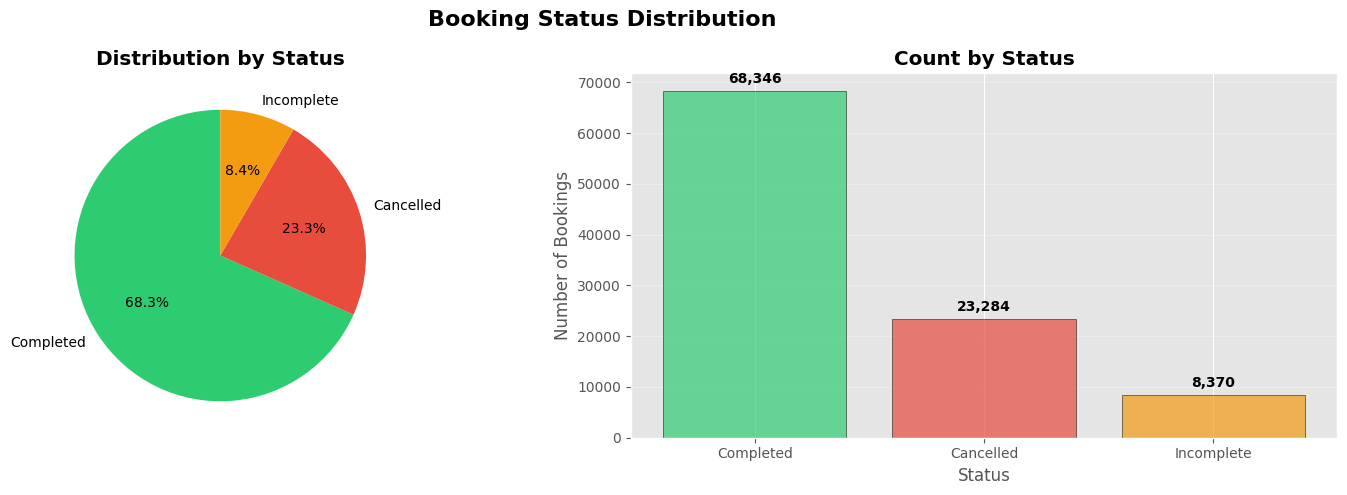


💾 Saved: booking_status_distribution.png


In [ ]:
"""
Cell 26: Analyze Target Variable - Booking Status
"""

print("🎯 TARGET VARIABLE ANALYSIS: BOOKING STATUS")
print("="*70)

# Identify the booking status column (adjust name if needed)
status_col = None
for col in df_bookings.columns:
    if 'status' in col.lower() or 'outcome' in col.lower():
        status_col = col
        break

if status_col:
    print(f"\nAnalyzing column: {status_col}\n")

    # Value counts
    status_counts = df_bookings[status_col].value_counts()
    status_pct = df_bookings[status_col].value_counts(normalize=True) * 100

    # Create summary
    status_summary = pd.DataFrame({
        'Status': status_counts.index,
        'Count': status_counts.values,
        'Percentage': status_pct.values
    })

    display(status_summary)

    # Calculate key metrics
    total_bookings = len(df_bookings)
    completed = status_counts.get('Completed', 0)
    cancelled = status_counts.get('Cancelled', 0) + status_counts.get('Canceled', 0)

    completion_rate = (completed / total_bookings) * 100
    cancellation_rate = (cancelled / total_bookings) * 100

    print("\n" + "="*70)
    print("📊 KEY METRICS:")
    print("="*70)
    print(f"Total Bookings: {total_bookings:,}")
    print(f"Completion Rate: {completion_rate:.2f}%")
    print(f"Cancellation Rate: {cancellation_rate:.2f}%")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Booking Status Distribution', fontsize=16, fontweight='bold')

    # Pie chart
    colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
    ax1.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors[:len(status_counts)])
    ax1.set_title('Distribution by Status', fontweight='bold')

    # Bar chart
    ax2.bar(status_counts.index, status_counts.values, color=colors[:len(status_counts)],
            edgecolor='black', alpha=0.7)
    ax2.set_title('Count by Status', fontweight='bold')
    ax2.set_ylabel('Number of Bookings')
    ax2.set_xlabel('Status')

    # Add value labels on bars
    for i, v in enumerate(status_counts.values):
        ax2.text(i, v + (total_bookings * 0.01), f'{v:,}',
                ha='center', va='bottom', fontweight='bold')

    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'booking_status_distribution.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: booking_status_distribution.png")
else:
    print("⚠️ Could not find booking status column")
    print(f"Available columns: {df_bookings.columns.tolist()}")

📊 NUMERICAL FEATURES DISTRIBUTION

Analyzing 5 numerical columns:
  - is_weekend
  - hour_of_day
  - base_fare
  - surge_multiplier
  - booking_value


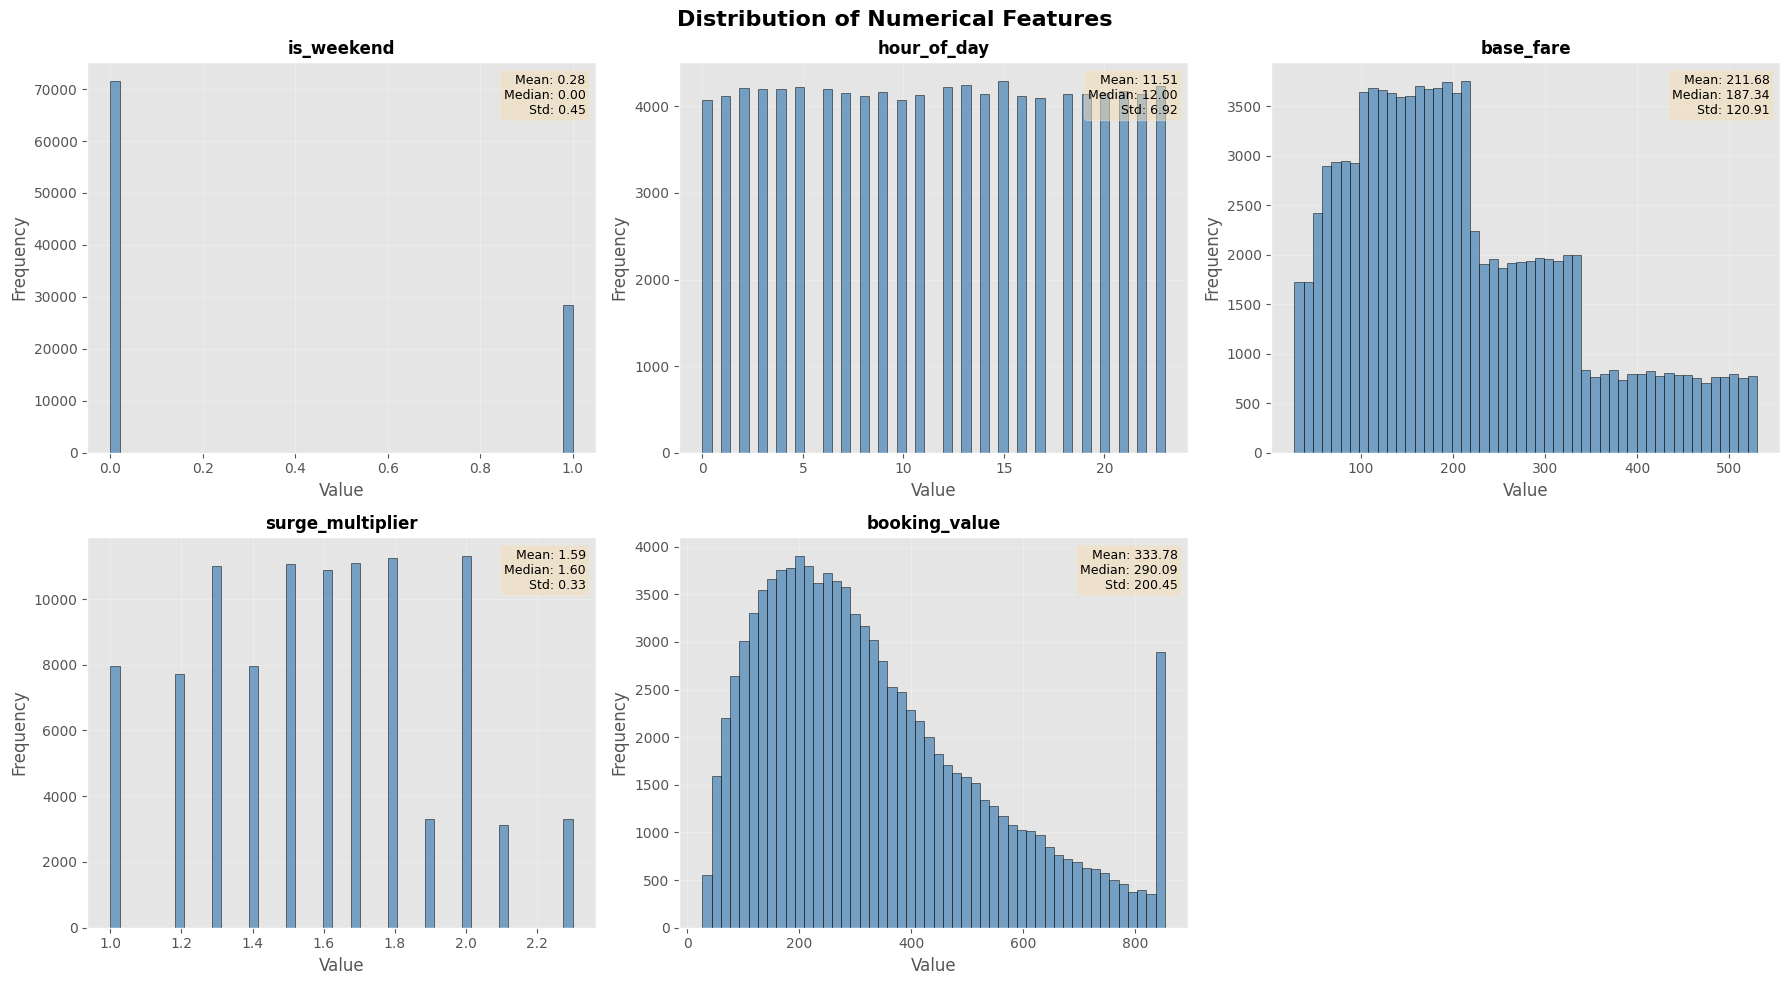


💾 Saved: numerical_distributions.png

📊 SUMMARY STATISTICS:


,is_weekend,hour_of_day,base_fare,surge_multiplier,booking_value
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,0.28,11.51,211.68,1.59,333.78
std,0.45,6.92,120.91,0.33,200.45
min,0.00,0.00,28.02,1.00,27.28
25%,0.00,5.00,118.63,1.30,179.21
50%,0.00,12.00,187.34,1.60,290.09
75%,1.00,17.00,287.46,1.80,448.47
max,1.00,23.00,529.96,2.30,852.36


In [ ]:
"""
Cell 27: Distribution of Key Numerical Features
"""

print("📊 NUMERICAL FEATURES DISTRIBUTION")
print("="*70)

# Get numerical columns (exclude IDs)
numeric_cols = df_bookings.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if 'id' not in col.lower()]

print(f"\nAnalyzing {len(numeric_cols)} numerical columns:")
for col in numeric_cols:
    print(f"  - {col}")

# Select key columns to visualize (adjust based on your data)
key_numeric_cols = numeric_cols[:6]  # First 6 numeric columns

if len(key_numeric_cols) > 0:
    # Create distributions
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(key_numeric_cols):
        if idx < len(axes):
            # Histogram with KDE
            df_bookings[col].hist(bins=50, ax=axes[idx], alpha=0.7,
                                  color='steelblue', edgecolor='black')
            axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(alpha=0.3)

            # Add statistics text box
            mean_val = df_bookings[col].mean()
            median_val = df_bookings[col].median()
            std_val = df_bookings[col].std()

            stats_text = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nStd: {std_val:.2f}'
            axes[idx].text(0.98, 0.97, stats_text,
                          transform=axes[idx].transAxes,
                          verticalalignment='top',
                          horizontalalignment='right',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                          fontsize=9)

    # Hide unused subplots
    for idx in range(len(key_numeric_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'numerical_distributions.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: numerical_distributions.png")

    # Print summary statistics
    print("\n" + "="*70)
    print("📊 SUMMARY STATISTICS:")
    print("="*70)
    display(df_bookings[key_numeric_cols].describe())
else:
    print("⚠️ No numerical columns found for visualization")

🏷️ CATEGORICAL FEATURES ANALYSIS

Analyzing 7 categorical columns:
  - day_of_week: 7 unique values
  - city: 5 unique values
  - vehicle_type: 3 unique values
  - traffic_level: 3 unique values
  - weather_condition: 3 unique values
  - booking_status: 3 unique values
  - incomplete_ride_reason: 5 unique values


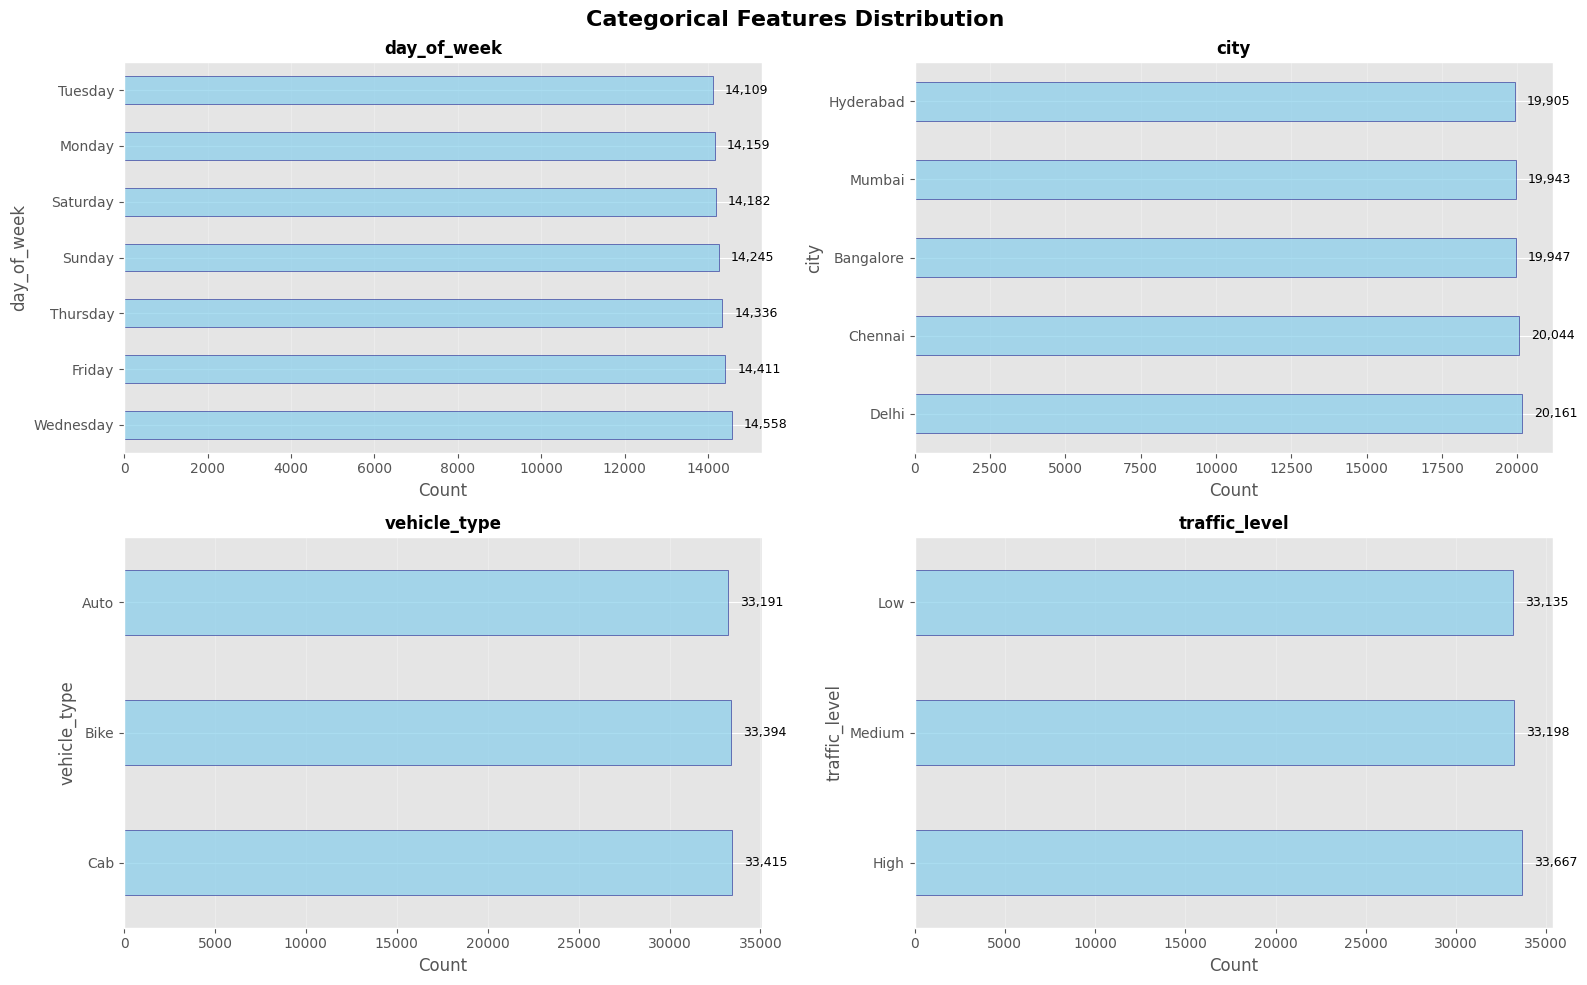


💾 Saved: categorical_distributions.png

📊 VALUE COUNTS:

day_of_week:
day_of_week
Wednesday    14558
Friday       14411
Thursday     14336
Sunday       14245
Saturday     14182
Monday       14159
Tuesday      14109
Name: count, dtype: int64

city:
city
Delhi        20161
Chennai      20044
Bangalore    19947
Mumbai       19943
Hyderabad    19905
Name: count, dtype: int64

vehicle_type:
vehicle_type
Cab     33415
Bike    33394
Auto    33191
Name: count, dtype: int64

traffic_level:
traffic_level
High      33667
Medium    33198
Low       33135
Name: count, dtype: int64


In [ ]:
"""
Cell 28: Analysis of Categorical Features
"""

print("🏷️ CATEGORICAL FEATURES ANALYSIS")
print("="*70)

# Get categorical columns with reasonable cardinality
categorical_cols = []
for col in df_bookings.select_dtypes(include=['object']).columns:
    unique_count = df_bookings[col].nunique()
    if unique_count < 50 and unique_count > 1:  # Between 2 and 50 unique values
        categorical_cols.append(col)

print(f"\nAnalyzing {len(categorical_cols)} categorical columns:")
for col in categorical_cols:
    print(f"  - {col}: {df_bookings[col].nunique()} unique values")

# Visualize top categorical columns
if len(categorical_cols) > 0:
    key_cat_cols = categorical_cols[:4]  # Top 4 categorical columns

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(key_cat_cols):
        if idx < len(axes):
            # Get value counts
            value_counts = df_bookings[col].value_counts().head(10)  # Top 10 values

            # Horizontal bar chart
            value_counts.plot(kind='barh', ax=axes[idx], color='skyblue',
                            edgecolor='navy', alpha=0.7)
            axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
            axes[idx].set_xlabel('Count')
            axes[idx].grid(axis='x', alpha=0.3)

            # Add value labels
            for i, v in enumerate(value_counts.values):
                axes[idx].text(v + (v * 0.02), i, f'{v:,}',
                             va='center', fontsize=9)

    # Hide unused subplots
    for idx in range(len(key_cat_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'categorical_distributions.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: categorical_distributions.png")

    # Print value counts for each
    print("\n" + "="*70)
    print("📊 VALUE COUNTS:")
    print("="*70)
    for col in key_cat_cols:
        print(f"\n{col}:")
        print(df_bookings[col].value_counts().head(10))
else:
    print("\n⚠️ No suitable categorical columns found")

⏰ TEMPORAL ANALYSIS: BOOKINGS BY HOUR

Using datetime column: booking_date

🔝 TOP 3 PEAK HOURS:
   00:00 - 100,000 bookings

📉 LOWEST 3 HOURS:
   00:00 - 100,000 bookings


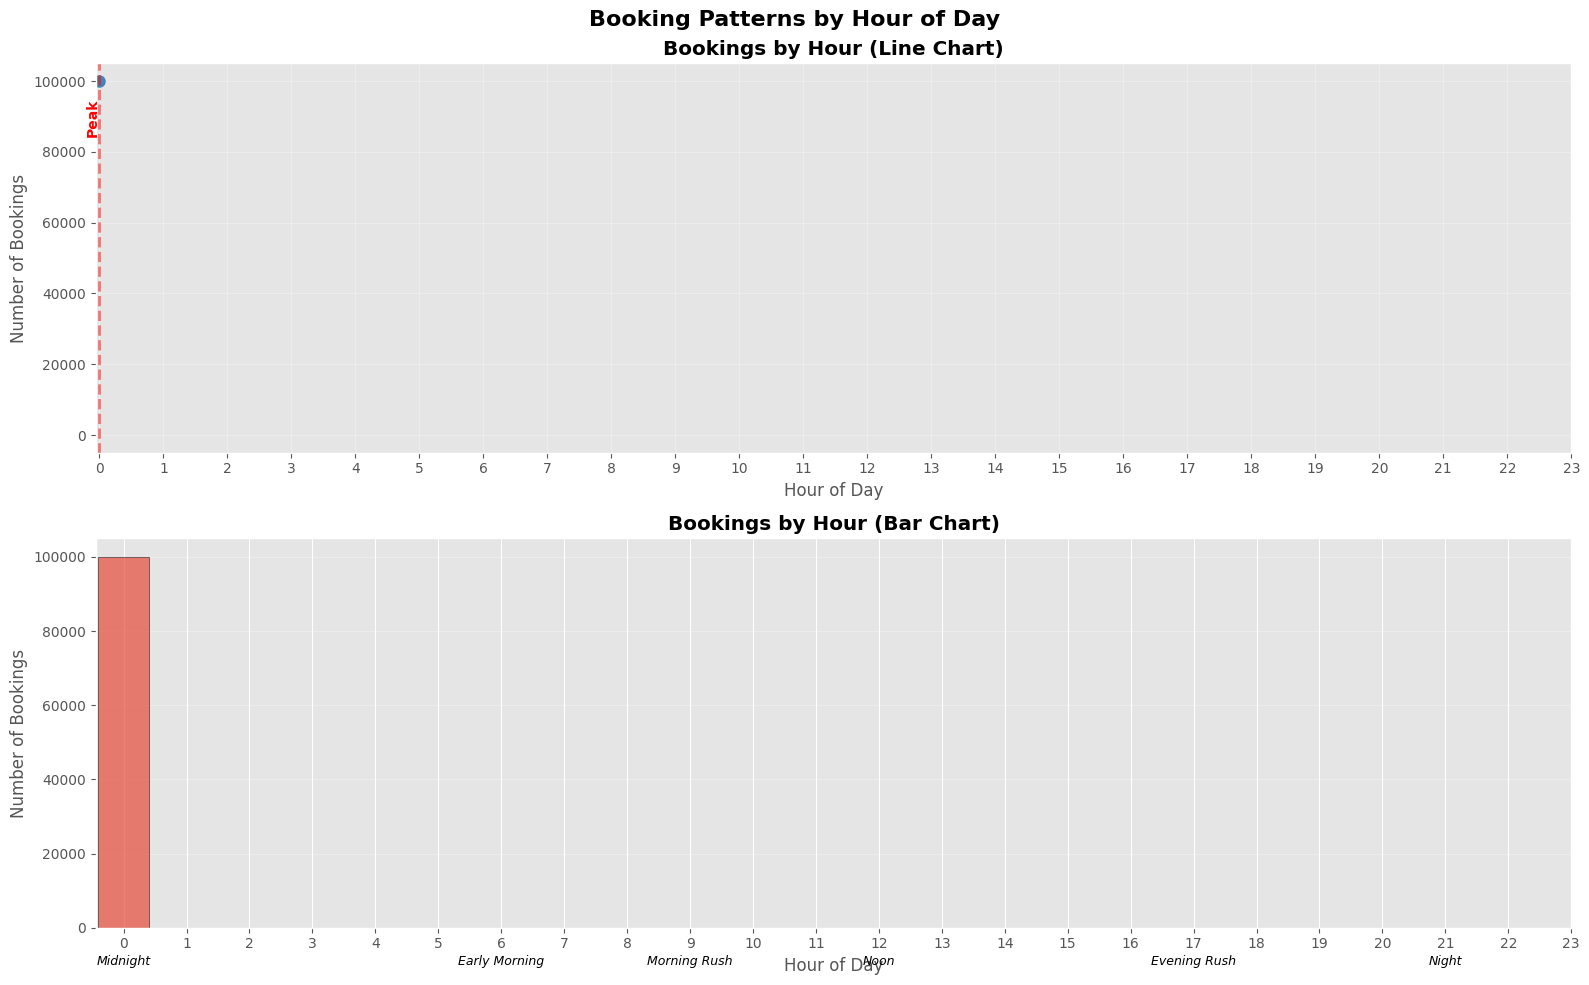


💾 Saved: bookings_by_hour.png

🚗 RUSH HOURS IDENTIFIED (Top 25% busiest):
Rush hours: [0]
Morning rush: []
Evening rush: []


In [ ]:
"""
Cell 29: Analyze Booking Patterns by Hour of Day
"""

print("⏰ TEMPORAL ANALYSIS: BOOKINGS BY HOUR")
print("="*70)

# Find datetime column
datetime_col = None
for col in df_bookings.columns:
    if pd.api.types.is_datetime64_any_dtype(df_bookings[col]):
        datetime_col = col
        break
    elif 'time' in col.lower() or 'date' in col.lower():
        # Try to convert
        try:
            df_bookings[col] = pd.to_datetime(df_bookings[col], errors='coerce')
            if pd.api.types.is_datetime64_any_dtype(df_bookings[col]):
                datetime_col = col
                break
        except:
            pass

if datetime_col:
    print(f"\nUsing datetime column: {datetime_col}\n")

    # Extract hour
    df_bookings['hour'] = df_bookings[datetime_col].dt.hour

    # Count by hour
    hourly_bookings = df_bookings['hour'].value_counts().sort_index()

    # Identify peak hours
    peak_hours = hourly_bookings.nlargest(3)
    print("🔝 TOP 3 PEAK HOURS:")
    for hour, count in peak_hours.items():
        print(f"   {hour:02d}:00 - {count:,} bookings")

    # Identify off-peak hours
    off_peak_hours = hourly_bookings.nsmallest(3)
    print("\n📉 LOWEST 3 HOURS:")
    for hour, count in off_peak_hours.items():
        print(f"   {hour:02d}:00 - {count:,} bookings")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Booking Patterns by Hour of Day', fontsize=16, fontweight='bold')

    # Line plot
    ax1.plot(hourly_bookings.index, hourly_bookings.values,
            marker='o', linewidth=2, markersize=8, color='steelblue')
    ax1.fill_between(hourly_bookings.index, hourly_bookings.values, alpha=0.3)
    ax1.set_title('Bookings by Hour (Line Chart)', fontweight='bold')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Number of Bookings')
    ax1.set_xticks(range(0, 24))
    ax1.grid(alpha=0.3)

    # Highlight peak hours
    for hour in peak_hours.index[:3]:
        ax1.axvline(x=hour, color='red', linestyle='--', alpha=0.5, linewidth=2)
        ax1.text(hour, hourly_bookings.max() * 0.95, 'Peak',
                rotation=90, va='top', ha='right', color='red', fontweight='bold')

    # Bar chart with color coding
    colors = ['#e74c3c' if h in peak_hours.index else '#3498db'
              for h in hourly_bookings.index]
    ax2.bar(hourly_bookings.index, hourly_bookings.values,
           color=colors, edgecolor='black', alpha=0.7)
    ax2.set_title('Bookings by Hour (Bar Chart)', fontweight='bold')
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Number of Bookings')
    ax2.set_xticks(range(0, 24))
    ax2.grid(axis='y', alpha=0.3)

    # Add time labels
    time_labels = {
        0: 'Midnight', 6: 'Early Morning', 9: 'Morning Rush',
        12: 'Noon', 17: 'Evening Rush', 21: 'Night'
    }
    for hour, label in time_labels.items():
        ax2.text(hour, -hourly_bookings.max() * 0.1, label,
                ha='center', fontsize=9, style='italic')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'bookings_by_hour.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: bookings_by_hour.png")

    # Define rush hours based on data
    rush_hour_threshold = hourly_bookings.quantile(0.75)
    rush_hours = hourly_bookings[hourly_bookings >= rush_hour_threshold].index.tolist()

    print("\n" + "="*70)
    print("🚗 RUSH HOURS IDENTIFIED (Top 25% busiest):")
    print("="*70)
    print(f"Rush hours: {sorted(rush_hours)}")
    morning_rush = [h for h in rush_hours if 6 <= h <= 10]
    evening_rush = [h for h in rush_hours if 17 <= h <= 21]
    print(f"Morning rush: {morning_rush}")
    print(f"Evening rush: {evening_rush}")

else:
    print("⚠️ No datetime column found in bookings dataset")

📅 TEMPORAL ANALYSIS: BOOKINGS BY DAY OF WEEK

📊 BOOKINGS BY DAY:
   Monday    : 14,159 (14.16%)
   Tuesday   : 14,109 (14.11%)
   Wednesday : 14,558 (14.56%)
   Thursday  : 14,336 (14.34%)
   Friday    : 14,411 (14.41%)
   Saturday  : 14,182 (14.18%)
   Sunday    : 14,245 (14.24%)

📊 WEEKDAY vs WEEKEND:
Weekday (Mon-Fri): 71,573 (71.6%)
Weekend (Sat-Sun): 28,427 (28.4%)


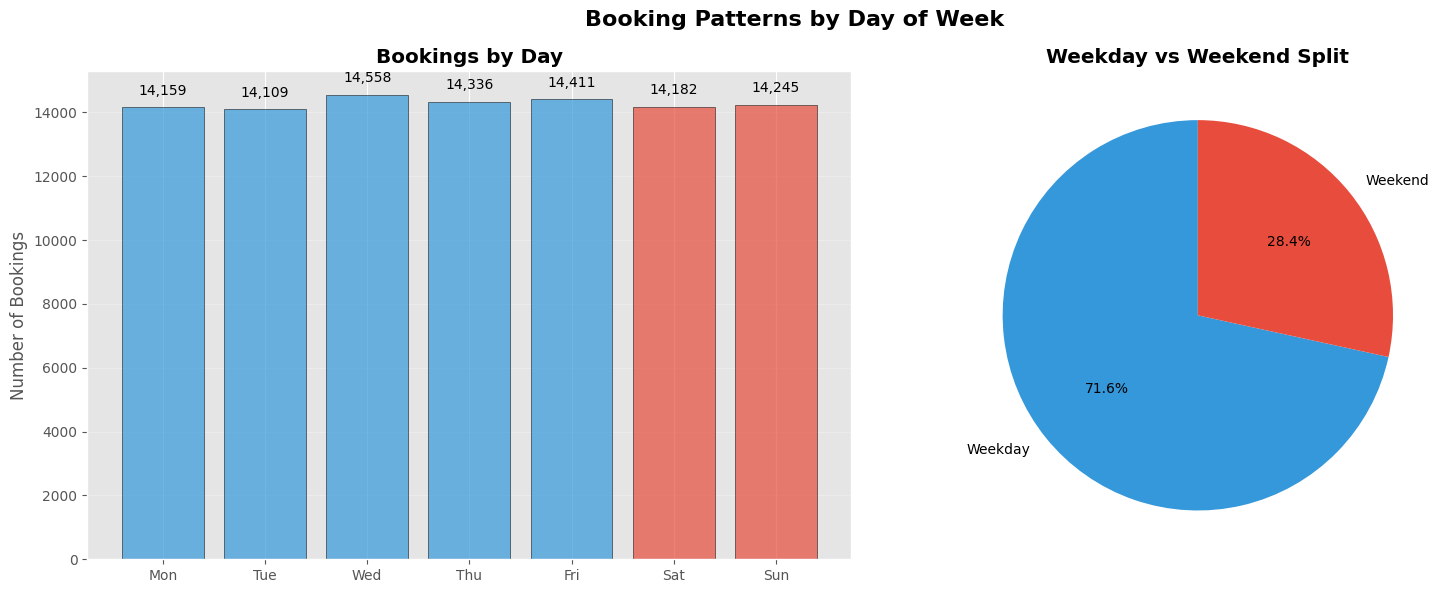


💾 Saved: bookings_by_day.png

📈 Busiest day: Wednesday (14,558 bookings)
📉 Quietest day: Tuesday (14,109 bookings)


In [ ]:
"""
Cell 30: Analyze Booking Patterns by Day of Week
"""

print("📅 TEMPORAL ANALYSIS: BOOKINGS BY DAY OF WEEK")
print("="*70)

if datetime_col:
    # Extract day of week
    df_bookings['day_of_week'] = df_bookings[datetime_col].dt.dayofweek  # 0=Monday, 6=Sunday
    df_bookings['day_name'] = df_bookings[datetime_col].dt.day_name()

    # Count by day
    daily_bookings = df_bookings['day_name'].value_counts()

    # Reorder by day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_bookings = daily_bookings.reindex([day for day in day_order if day in daily_bookings.index])

    print("\n📊 BOOKINGS BY DAY:")
    for day, count in daily_bookings.items():
        pct = (count / daily_bookings.sum()) * 100
        print(f"   {day:10s}: {count:6,} ({pct:5.2f}%)")

    # Calculate weekday vs weekend
    weekday_bookings = df_bookings[df_bookings['day_of_week'] < 5].shape[0]
    weekend_bookings = df_bookings[df_bookings['day_of_week'] >= 5].shape[0]

    print("\n" + "="*70)
    print("📊 WEEKDAY vs WEEKEND:")
    print("="*70)
    print(f"Weekday (Mon-Fri): {weekday_bookings:,} ({weekday_bookings/len(df_bookings)*100:.1f}%)")
    print(f"Weekend (Sat-Sun): {weekend_bookings:,} ({weekend_bookings/len(df_bookings)*100:.1f}%)")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Booking Patterns by Day of Week', fontsize=16, fontweight='bold')

    # Bar chart by day
    colors = ['#3498db' if day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
              else '#e74c3c' for day in daily_bookings.index]
    ax1.bar(range(len(daily_bookings)), daily_bookings.values,
           color=colors, edgecolor='black', alpha=0.7)
    ax1.set_xticks(range(len(daily_bookings)))
    ax1.set_xticklabels([day[:3] for day in daily_bookings.index], rotation=0)
    ax1.set_title('Bookings by Day', fontweight='bold')
    ax1.set_ylabel('Number of Bookings')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(daily_bookings.values):
        ax1.text(i, v + (daily_bookings.max() * 0.02), f'{v:,}',
                ha='center', va='bottom', fontsize=10)

    # Weekday vs Weekend pie chart
    weekday_weekend = pd.Series({
        'Weekday': weekday_bookings,
        'Weekend': weekend_bookings
    })
    ax2.pie(weekday_weekend.values, labels=weekday_weekend.index,
           autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
    ax2.set_title('Weekday vs Weekend Split', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'bookings_by_day.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: bookings_by_day.png")

    # Identify busiest day
    busiest_day = daily_bookings.idxmax()
    quietest_day = daily_bookings.idxmin()

    print("\n" + "="*70)
    print(f"📈 Busiest day: {busiest_day} ({daily_bookings.max():,} bookings)")
    print(f"📉 Quietest day: {quietest_day} ({daily_bookings.min():,} bookings)")

else:
    print("⚠️ No datetime column available")

📆 TEMPORAL ANALYSIS: MONTHLY/SEASONAL PATTERNS

📊 BOOKINGS BY MONTH:
   January   :  8,536 ( 8.54%)
   February  :  7,730 ( 7.73%)
   March     :  8,408 ( 8.41%)
   April     :  8,230 ( 8.23%)
   May       :  8,585 ( 8.58%)
   June      :  8,052 ( 8.05%)
   July      :  8,428 ( 8.43%)
   August    :  8,319 ( 8.32%)
   September :  8,270 ( 8.27%)
   October   :  8,553 ( 8.55%)
   November  :  8,378 ( 8.38%)
   December  :  8,511 ( 8.51%)


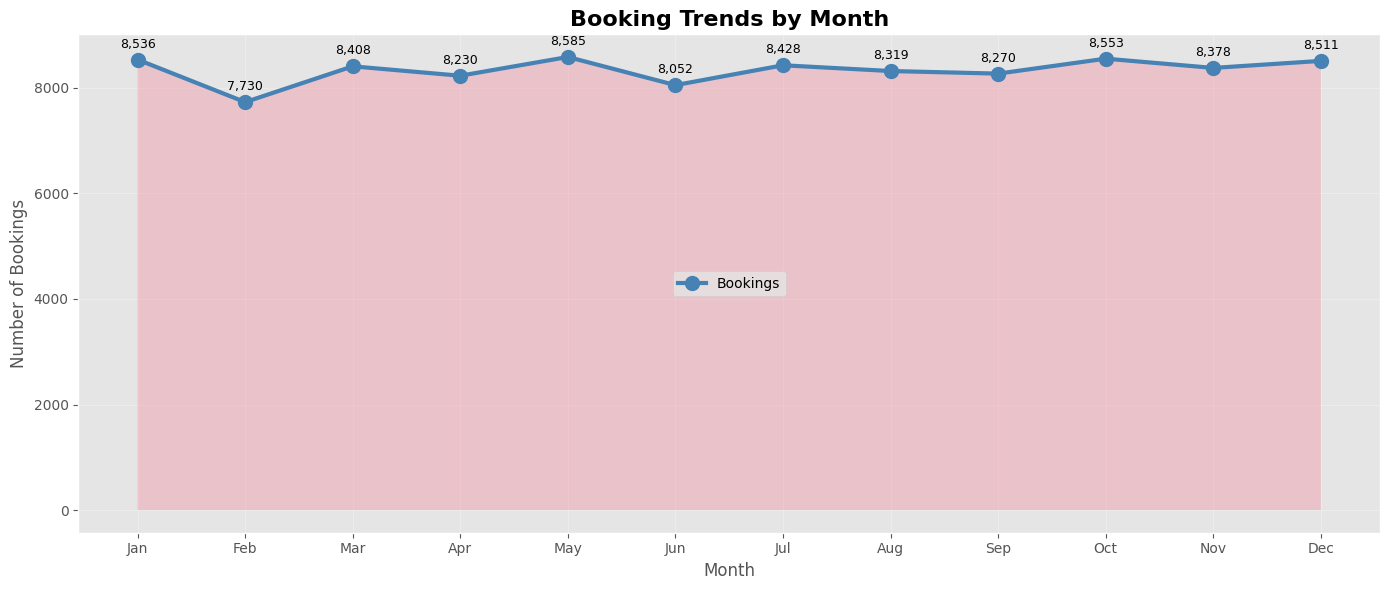


💾 Saved: bookings_by_month.png

📈 Peak month: May (8,585 bookings)
📉 Lowest month: February (7,730 bookings)


In [ ]:
"""
Cell 31: Analyze Monthly and Seasonal Patterns
"""

print("📆 TEMPORAL ANALYSIS: MONTHLY/SEASONAL PATTERNS")
print("="*70)

if datetime_col:
    # Extract month
    df_bookings['month'] = df_bookings[datetime_col].dt.month
    df_bookings['month_name'] = df_bookings[datetime_col].dt.month_name()

    # Count by month
    monthly_bookings = df_bookings['month_name'].value_counts()

    # Reorder by month
    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
    monthly_bookings = monthly_bookings.reindex([m for m in month_order if m in monthly_bookings.index])

    if len(monthly_bookings) > 0:
        print(f"\n📊 BOOKINGS BY MONTH:")
        for month, count in monthly_bookings.items():
            pct = (count / monthly_bookings.sum()) * 100
            print(f"   {month:10s}: {count:6,} ({pct:5.2f}%)")

        # Visualization
        fig, ax = plt.subplots(figsize=(14, 6))

        months_short = [m[:3] for m in monthly_bookings.index]
        ax.plot(range(len(monthly_bookings)), monthly_bookings.values,
               marker='o', linewidth=3, markersize=10, color='steelblue', label='Bookings')
        ax.fill_between(range(len(monthly_bookings)), monthly_bookings.values, alpha=0.3)

        ax.set_xticks(range(len(monthly_bookings)))
        ax.set_xticklabels(months_short)
        ax.set_title('Booking Trends by Month', fontsize=16, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Number of Bookings')
        ax.grid(alpha=0.3)
        ax.legend()

        # Add value labels
        for i, v in enumerate(monthly_bookings.values):
            ax.text(i, v + (monthly_bookings.max() * 0.02), f'{v:,}',
                   ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_PATH, 'bookings_by_month.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n💾 Saved: bookings_by_month.png")

        # Identify peak and low months
        peak_month = monthly_bookings.idxmax()
        low_month = monthly_bookings.idxmin()

        print("\n" + "="*70)
        print(f"📈 Peak month: {peak_month} ({monthly_bookings.max():,} bookings)")
        print(f"📉 Lowest month: {low_month} ({monthly_bookings.min():,} bookings)")

    else:
        print("\n⚠️ Not enough data to analyze monthly patterns")
        print(f"   Available months: {df_bookings['month'].nunique()}")
else:
    print("⚠️ No datetime column available")

🌍 GEOGRAPHICAL ANALYSIS: BOOKINGS BY CITY

Found city columns: ['city']
Analyzing: city

📊 TOP 15 CITIES BY BOOKINGS:
    1. Delhi               : 20,161 (20.16%)
    2. Chennai             : 20,044 (20.04%)
    3. Bangalore           : 19,947 (19.95%)
    4. Mumbai              : 19,943 (19.94%)
    5. Hyderabad           : 19,905 (19.91%)


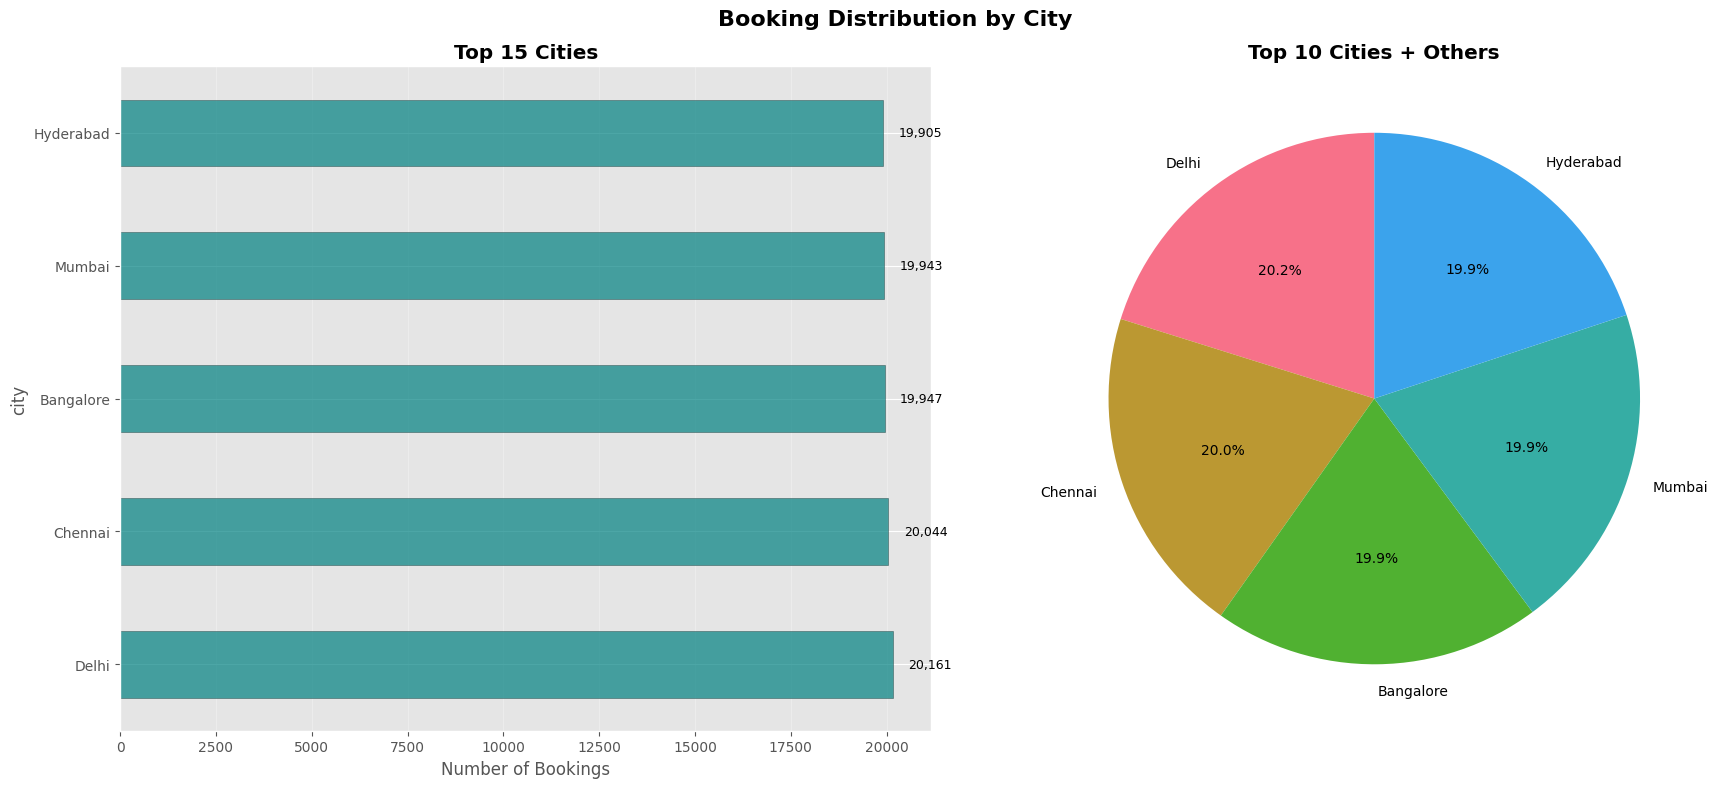


💾 Saved: bookings_by_city.png

📊 CITY CONCENTRATION:
Top 5 cities: 100.0% of all bookings
Top 10 cities: 100.0% of all bookings
Total unique cities: 5


In [ ]:
"""
Cell 32: Analyze Booking Distribution by City
"""

print("🌍 GEOGRAPHICAL ANALYSIS: BOOKINGS BY CITY")
print("="*70)

# Find city columns
city_cols = [col for col in df_bookings.columns if 'city' in col.lower()]

if city_cols:
    print(f"\nFound city columns: {city_cols}")

    # Use first city column (usually pickup city)
    city_col = city_cols[0]
    print(f"Analyzing: {city_col}\n")

    # Count by city
    city_bookings = df_bookings[city_col].value_counts().head(15)  # Top 15 cities

    print("📊 TOP 15 CITIES BY BOOKINGS:")
    for idx, (city, count) in enumerate(city_bookings.items(), 1):
        pct = (count / len(df_bookings)) * 100
        print(f"   {idx:2d}. {city:20s}: {count:6,} ({pct:5.2f}%)")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Booking Distribution by City', fontsize=16, fontweight='bold')

    # Horizontal bar chart
    city_bookings.plot(kind='barh', ax=ax1, color='teal',
                      edgecolor='darkslategray', alpha=0.7)
    ax1.set_title('Top 15 Cities', fontweight='bold')
    ax1.set_xlabel('Number of Bookings')
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(city_bookings.values):
        ax1.text(v + (city_bookings.max() * 0.02), i, f'{v:,}',
                va='center', fontsize=9)

    # Pie chart for top 10
    top10 = city_bookings.head(10)
    others = city_bookings[10:].sum()
    if others > 0:
        pie_data = pd.concat([top10, pd.Series({'Others': others})])
    else:
        pie_data = top10

    ax2.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
           startangle=90)
    ax2.set_title('Top 10 Cities + Others', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'bookings_by_city.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: bookings_by_city.png")

    # Calculate concentration
    top5_pct = (city_bookings.head(5).sum() / len(df_bookings)) * 100
    top10_pct = (city_bookings.head(10).sum() / len(df_bookings)) * 100

    print("\n" + "="*70)
    print("📊 CITY CONCENTRATION:")
    print("="*70)
    print(f"Top 5 cities: {top5_pct:.1f}% of all bookings")
    print(f"Top 10 cities: {top10_pct:.1f}% of all bookings")
    print(f"Total unique cities: {df_bookings[city_col].nunique():,}")

else:
    print("⚠️ No city column found in bookings dataset")

🚫 CANCELLATION RATE BY CITY

📊 TOP 15 CITIES BY CANCELLATION RATE:

    1. Mumbai              : 23.78% (19,943 total bookings)
    2. Delhi               : 23.51% (20,161 total bookings)
    3. Hyderabad           : 23.11% (19,905 total bookings)
    4. Bangalore           : 23.06% (19,947 total bookings)
    5. Chennai             : 22.95% (20,044 total bookings)


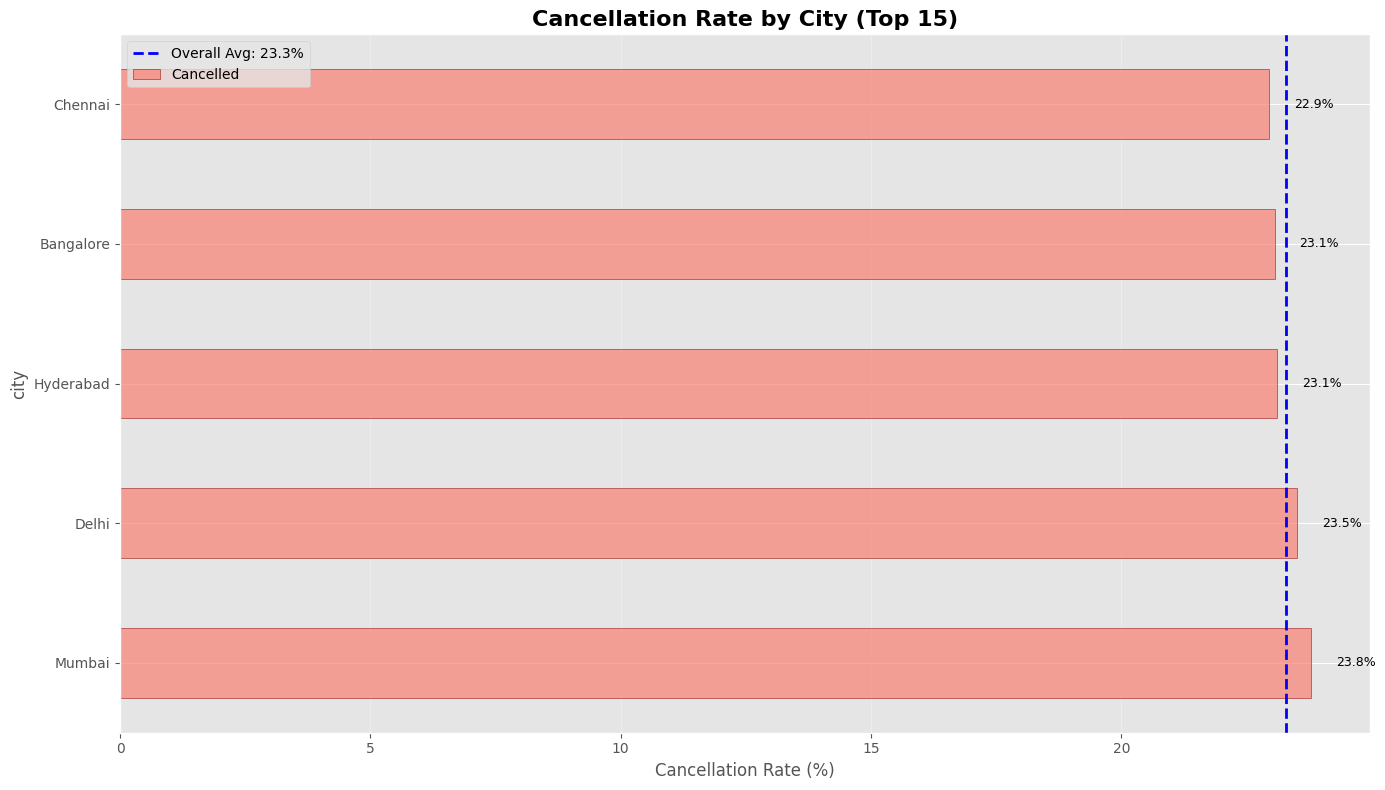


💾 Saved: cancellation_by_city.png

⚠️ HIGH CANCELLATION CITIES (>20% above average):


In [ ]:
"""
Cell 33: Analyze Cancellation Rates by City
"""

print("🚫 CANCELLATION RATE BY CITY")
print("="*70)

if city_cols and status_col:
    city_col = city_cols[0]

    # Calculate cancellation rate by city
    city_status = df_bookings.groupby(city_col)[status_col].value_counts(normalize=True).unstack(fill_value=0)

    # Get cancellation column
    cancel_cols = [col for col in city_status.columns if 'cancel' in col.lower()]

    if cancel_cols:
        cancel_col = cancel_cols[0]
        city_cancellation_rate = (city_status[cancel_col] * 100).sort_values(ascending=False).head(15)

        print("\n📊 TOP 15 CITIES BY CANCELLATION RATE:\n")
        for idx, (city, rate) in enumerate(city_cancellation_rate.items(), 1):
            total = df_bookings[df_bookings[city_col] == city].shape[0]
            print(f"   {idx:2d}. {city:20s}: {rate:5.2f}% ({total:,} total bookings)")

        # Visualization
        fig, ax = plt.subplots(figsize=(14, 8))

        city_cancellation_rate.plot(kind='barh', ax=ax, color='salmon',
                                    edgecolor='darkred', alpha=0.7)
        ax.set_title('Cancellation Rate by City (Top 15)',
                    fontsize=16, fontweight='bold')
        ax.set_xlabel('Cancellation Rate (%)')
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(city_cancellation_rate.values):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

        # Add average line
        avg_cancel_rate = (df_bookings[status_col].str.lower().str.contains('cancel').sum() /
                          len(df_bookings)) * 100
        ax.axvline(x=avg_cancel_rate, color='blue', linestyle='--',
                  linewidth=2, label=f'Overall Avg: {avg_cancel_rate:.1f}%')
        ax.legend()

        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_PATH, 'cancellation_by_city.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n💾 Saved: cancellation_by_city.png")

        # Identify problematic cities
        high_cancel_cities = city_cancellation_rate[city_cancellation_rate > avg_cancel_rate * 1.2]

        print("\n" + "="*70)
        print(f"⚠️ HIGH CANCELLATION CITIES (>20% above average):")
        print("="*70)
        for city, rate in high_cancel_cities.items():
            print(f"   {city}: {rate:.2f}%")
    else:
        print("\n⚠️ Could not identify cancellation status")
else:
    print("⚠️ Missing required columns for this analysis")

🛣️ POPULAR ROUTES ANALYSIS

Using location-based columns:
  Pickup: pickup_location
  Drop: drop_location

📊 TOP 20 ROUTES:
    1. Loc_49 → Loc_46                                   :    63 (0.06%)
    2. Loc_14 → Loc_5                                    :    63 (0.06%)
    3. Loc_23 → Loc_7                                    :    62 (0.06%)
    4. Loc_23 → Loc_5                                    :    62 (0.06%)
    5. Loc_20 → Loc_13                                   :    61 (0.06%)
    6. Loc_27 → Loc_12                                   :    59 (0.06%)
    7. Loc_34 → Loc_17                                   :    59 (0.06%)
    8. Loc_44 → Loc_23                                   :    59 (0.06%)
    9. Loc_37 → Loc_5                                    :    59 (0.06%)
   10. Loc_38 → Loc_32                                   :    58 (0.06%)
   11. Loc_17 → Loc_27                                   :    58 (0.06%)
   12. Loc_16 → Loc_36                                   :    58 (0.06%)


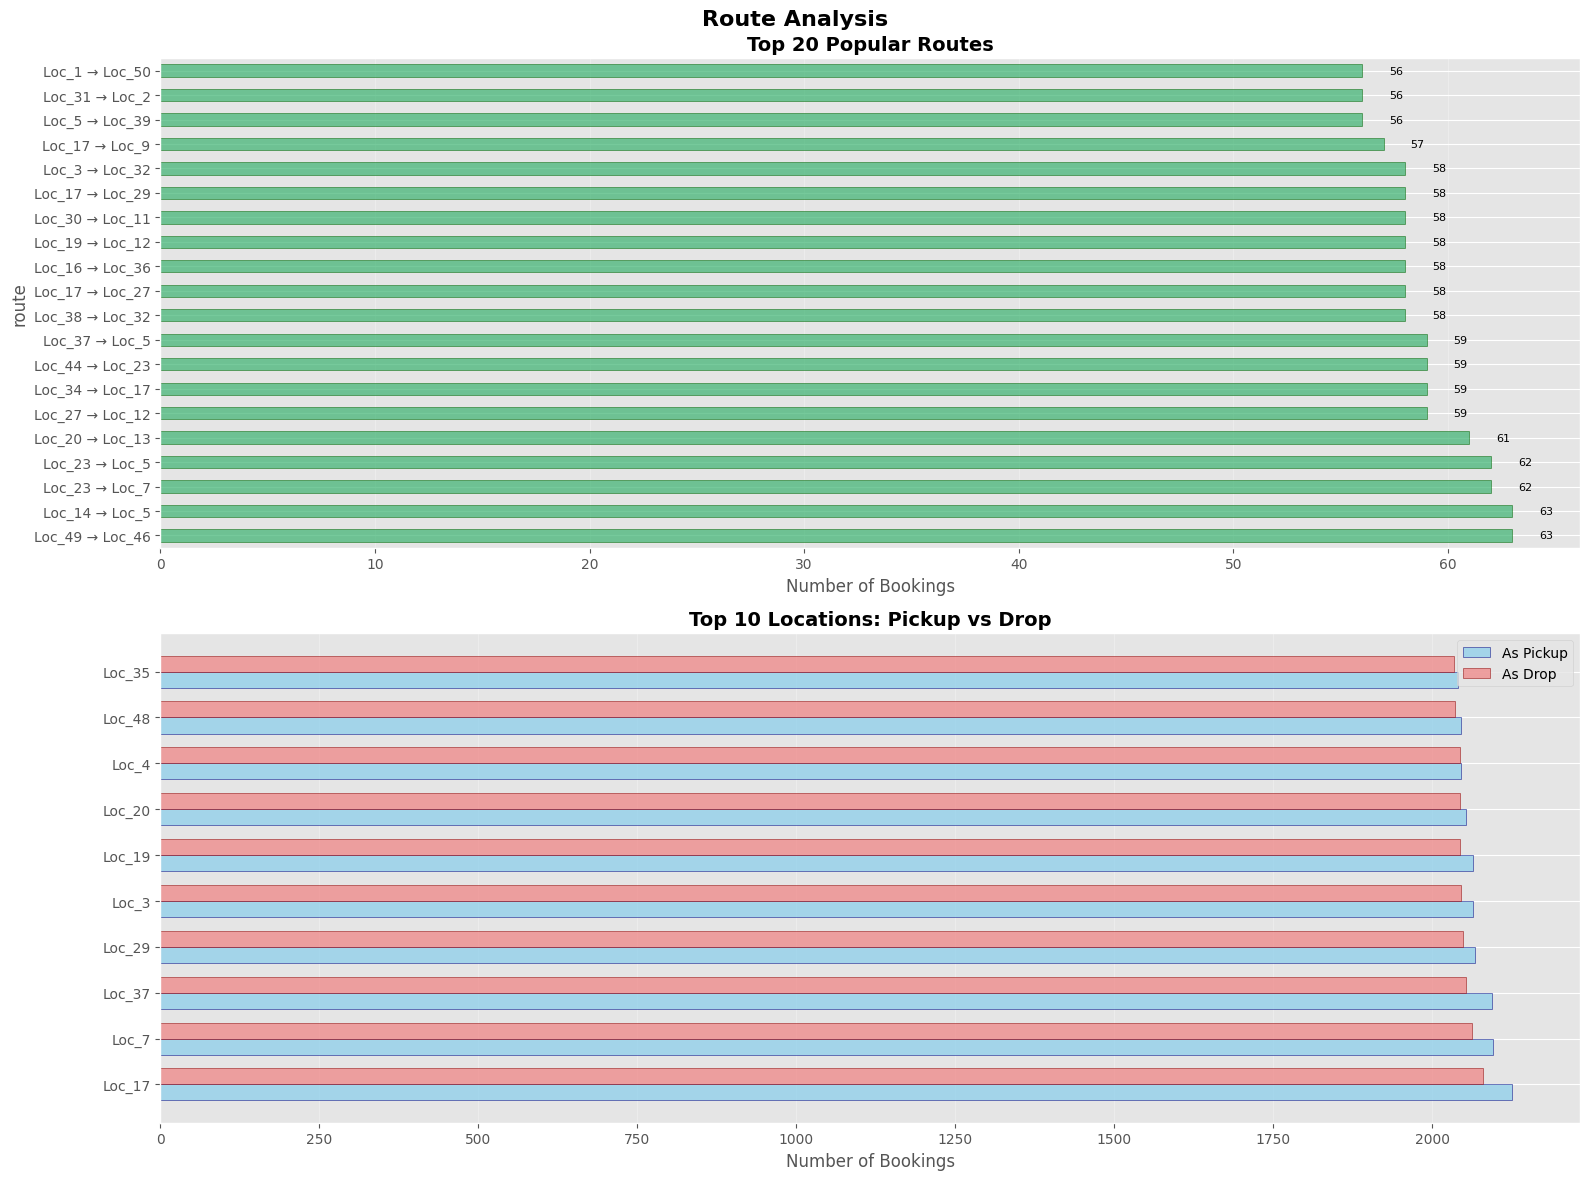


💾 Saved: popular_routes.png

📊 ROUTE DIVERSITY:
Total unique routes: 2,500
Total unique pickup locations: 50
Total unique drop locations: 50
Top 20 routes account for: 1.18% of bookings


In [ ]:
"""
Cell 34: Analyze Popular Routes (City Pairs)
"""

print("🛣️ POPULAR ROUTES ANALYSIS")
print("="*70)

# Check available columns
pickup_col = None
drop_col = None

# Look for location columns (not city pairs, but actual locations)
if 'pickup_location' in df_bookings.columns and 'drop_location' in df_bookings.columns:
    pickup_col = 'pickup_location'
    drop_col = 'drop_location'
    print(f"\nUsing location-based columns:")
elif 'city' in df_bookings.columns:
    # If only one city column exists, we can't analyze routes
    print(f"\n⚠️ Only single city column found: 'city'")
    print("   Cannot analyze routes (need both pickup and drop locations)")
    print("\nAnalyzing single city distribution instead:\n")

    city_counts = df_bookings['city'].value_counts().head(15)

    print("📊 TOP 15 CITIES BY BOOKINGS:")
    for idx, (city, count) in enumerate(city_counts.items(), 1):
        pct = (count / len(df_bookings)) * 100
        print(f"   {idx:2d}. {city:30s}: {count:6,} ({pct:5.2f}%)")

    # Visualization
    fig, ax = plt.subplots(figsize=(14, 8))

    city_counts.plot(kind='barh', ax=ax, color='teal',
                     edgecolor='darkslategray', alpha=0.7)
    ax.set_title('Top 15 Cities by Bookings', fontsize=16, fontweight='bold')
    ax.set_xlabel('Number of Bookings')
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(city_counts.values):
        ax.text(v + (city_counts.max() * 0.02), i, f'{v:,}',
               va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'bookings_by_city_single.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: bookings_by_city_single.png")

    pickup_col = None  # Skip route analysis

if pickup_col and drop_col:
    print(f"  Pickup: {pickup_col}")
    print(f"  Drop: {drop_col}\n")

    # Create route column
    df_bookings['route'] = (df_bookings[pickup_col].astype(str) + ' → ' +
                            df_bookings[drop_col].astype(str))

    # Count routes
    route_counts = df_bookings['route'].value_counts().head(20)

    # Identify same-location trips
    same_location = (df_bookings[pickup_col] == df_bookings[drop_col]).sum()
    same_location_pct = (same_location / len(df_bookings)) * 100

    print("📊 TOP 20 ROUTES:")
    for idx, (route, count) in enumerate(route_counts.items(), 1):
        pct = (count / len(df_bookings)) * 100
        print(f"   {idx:2d}. {route:50s}: {count:5,} ({pct:4.2f}%)")

    print("\n" + "="*70)
    print(f"🏙️ SAME-LOCATION TRIPS:")
    print("="*70)
    print(f"Total: {same_location:,} ({same_location_pct:.2f}%)")
    print("(Pickup and drop locations are the same)")

    # Analyze route characteristics
    print("\n" + "="*70)
    print("📊 ROUTE CHARACTERISTICS:")
    print("="*70)

    # Most popular pickup locations
    popular_pickups = df_bookings[pickup_col].value_counts().head(10)
    print("\n🔝 Top 10 Pickup Locations:")
    for idx, (loc, count) in enumerate(popular_pickups.items(), 1):
        print(f"   {idx:2d}. {loc}: {count:,}")

    # Most popular drop locations
    popular_drops = df_bookings[drop_col].value_counts().head(10)
    print("\n🎯 Top 10 Drop Locations:")
    for idx, (loc, count) in enumerate(popular_drops.items(), 1):
        print(f"   {idx:2d}. {loc}: {count:,}")

    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle('Route Analysis', fontsize=16, fontweight='bold')

    # Top routes
    route_counts.plot(kind='barh', ax=axes[0], color='mediumseagreen',
                     edgecolor='darkgreen', alpha=0.7)
    axes[0].set_title('Top 20 Popular Routes', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Number of Bookings')
    axes[0].grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(route_counts.values):
        axes[0].text(v + (route_counts.max() * 0.02), i, f'{v:,}',
                    va='center', fontsize=8)

    # Compare pickup vs drop locations (top 10 each)
    x = np.arange(10)
    width = 0.35

    axes[1].barh(x - width/2, popular_pickups.head(10).values, width,
                label='As Pickup', color='skyblue', alpha=0.7, edgecolor='navy')
    axes[1].barh(x + width/2, popular_drops.head(10).values, width,
                label='As Drop', color='lightcoral', alpha=0.7, edgecolor='darkred')

    axes[1].set_yticks(x)
    axes[1].set_yticklabels(popular_pickups.head(10).index)
    axes[1].set_xlabel('Number of Bookings')
    axes[1].set_title('Top 10 Locations: Pickup vs Drop', fontweight='bold', fontsize=14)
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'popular_routes.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: popular_routes.png")

    # Route diversity
    total_unique_routes = df_bookings['route'].nunique()
    total_unique_pickups = df_bookings[pickup_col].nunique()
    total_unique_drops = df_bookings[drop_col].nunique()

    print("\n" + "="*70)
    print("📊 ROUTE DIVERSITY:")
    print("="*70)
    print(f"Total unique routes: {total_unique_routes:,}")
    print(f"Total unique pickup locations: {total_unique_pickups:,}")
    print(f"Total unique drop locations: {total_unique_drops:,}")
    print(f"Top 20 routes account for: {(route_counts.sum()/len(df_bookings)*100):.2f}% of bookings")

elif pickup_col is None and 'city' not in df_bookings.columns:
    print("⚠️ No location or city columns found for route analysis")
    print(f"\nAvailable columns: {df_bookings.columns.tolist()}")

🚫 CANCELLATION DEEP DIVE - OVERALL METRICS

📊 BOOKING OUTCOME SUMMARY:
Total Bookings: 100,000

Completed: 76,716 (76.72%)
Cancelled: 23,284 (23.28%)
Incomplete: 0 (0.00%)

📊 INDUSTRY BENCHMARKS:
Good cancellation rate: < 10%
Average cancellation rate: 10-20%
High cancellation rate: > 20%

🚨 Cancellation rate is HIGH (above 20%) - NEEDS ATTENTION!

💰 FINANCIAL IMPACT OF CANCELLATIONS:
Potential revenue lost: ₹4,909,675.44
Average cancelled booking value: ₹210.86
Average cancellation loss per day: ₹163,655.85


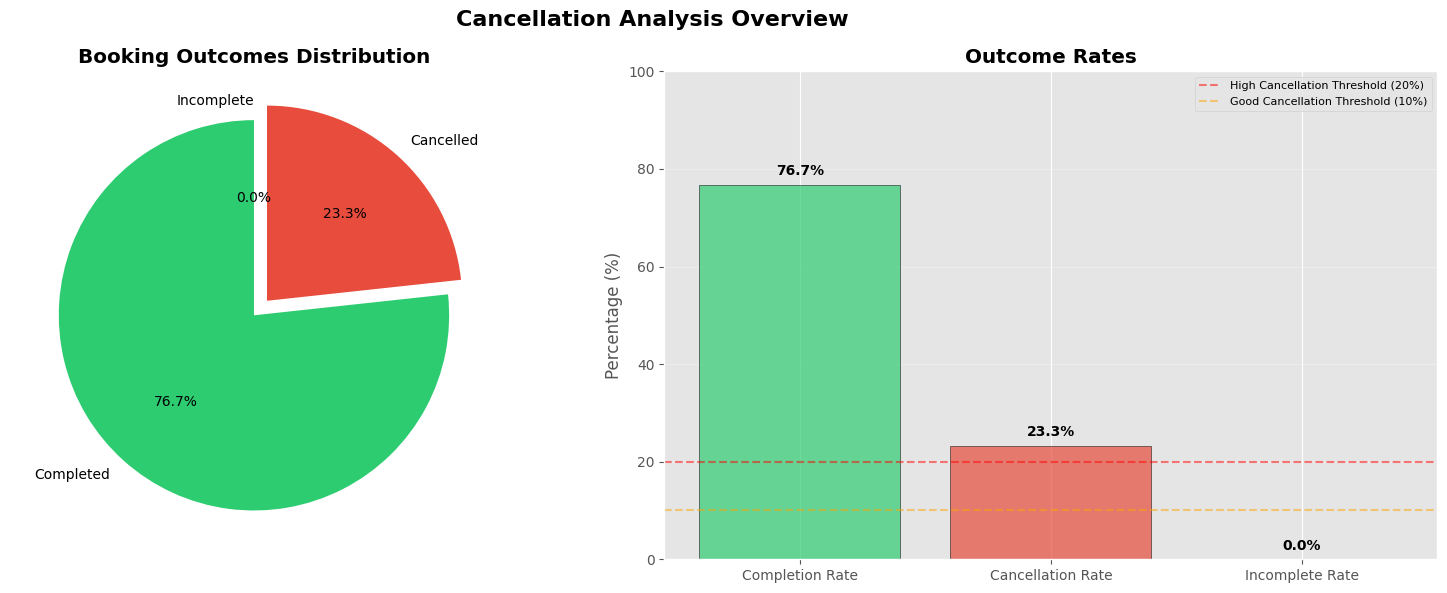


💾 Saved: cancellation_overview.png


In [ ]:
"""
Cell 35: Comprehensive Cancellation Analysis
"""

print("🚫 CANCELLATION DEEP DIVE - OVERALL METRICS")
print("="*70)

if status_col:
    # Get all status values
    status_values = df_bookings[status_col].value_counts()

    # Identify cancellation-related statuses
    total_bookings = len(df_bookings)
    completed = 0
    cancelled = 0
    incomplete = 0

    for status, count in status_values.items():
        status_lower = str(status).lower()
        if 'complet' in status_lower:
            completed += count
        elif 'cancel' in status_lower:
            cancelled += count
        elif 'incomplete' in status_lower or 'fail' in status_lower:
            incomplete += count

    # Calculate rates
    completion_rate = (completed / total_bookings) * 100
    cancellation_rate = (cancelled / total_bookings) * 100
    incomplete_rate = (incomplete / total_bookings) * 100

    print("\n📊 BOOKING OUTCOME SUMMARY:")
    print("="*70)
    print(f"Total Bookings: {total_bookings:,}")
    print(f"\nCompleted: {completed:,} ({completion_rate:.2f}%)")
    print(f"Cancelled: {cancelled:,} ({cancellation_rate:.2f}%)")
    print(f"Incomplete: {incomplete:,} ({incomplete_rate:.2f}%)")

    # Industry benchmarks
    print("\n" + "="*70)
    print("📊 INDUSTRY BENCHMARKS:")
    print("="*70)
    print("Good cancellation rate: < 10%")
    print("Average cancellation rate: 10-20%")
    print("High cancellation rate: > 20%")

    print(f"\n{'='*70}")
    if cancellation_rate < 10:
        print("✅ Cancellation rate is GOOD (below 10%)")
    elif cancellation_rate < 20:
        print("⚠️ Cancellation rate is AVERAGE (10-20%)")
    else:
        print("🚨 Cancellation rate is HIGH (above 20%) - NEEDS ATTENTION!")

    # Calculate financial impact (if fare column exists)
    fare_cols = [col for col in df_bookings.columns
                 if any(keyword in col.lower() for keyword in ['fare', 'value', 'price', 'amount'])]

    if fare_cols:
        fare_col = fare_cols[0]

        # Filter cancelled bookings
        cancelled_bookings = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

        if len(cancelled_bookings) > 0 and fare_col in cancelled_bookings.columns:
            potential_revenue_lost = cancelled_bookings[fare_col].sum()
            avg_cancelled_fare = cancelled_bookings[fare_col].mean()

            print("\n" + "="*70)
            print("💰 FINANCIAL IMPACT OF CANCELLATIONS:")
            print("="*70)
            print(f"Potential revenue lost: ₹{potential_revenue_lost:,.2f}")
            print(f"Average cancelled booking value: ₹{avg_cancelled_fare:,.2f}")
            print(f"Average cancellation loss per day: ₹{potential_revenue_lost/30:,.2f}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cancellation Analysis Overview', fontsize=16, fontweight='bold')

    # Pie chart
    outcome_data = pd.Series({
        'Completed': completed,
        'Cancelled': cancelled,
        'Incomplete': incomplete
    })
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    ax1.pie(outcome_data.values, labels=outcome_data.index, autopct='%1.1f%%',
           startangle=90, colors=colors, explode=(0, 0.1, 0))
    ax1.set_title('Booking Outcomes Distribution', fontweight='bold')

    # Bar chart with rates
    rates_data = pd.Series({
        'Completion Rate': completion_rate,
        'Cancellation Rate': cancellation_rate,
        'Incomplete Rate': incomplete_rate
    })
    ax2.bar(rates_data.index, rates_data.values, color=colors,
           edgecolor='black', alpha=0.7)
    ax2.set_ylabel('Percentage (%)')
    ax2.set_title('Outcome Rates', fontweight='bold')
    ax2.set_ylim([0, 100])
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(rates_data.values):
        ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # Add benchmark line for cancellation
    ax2.axhline(y=20, color='red', linestyle='--', alpha=0.5,
               label='High Cancellation Threshold (20%)')
    ax2.axhline(y=10, color='orange', linestyle='--', alpha=0.5,
               label='Good Cancellation Threshold (10%)')
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'cancellation_overview.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: cancellation_overview.png")

else:
    print("⚠️ Status column not found")

⏰ CANCELLATIONS BY HOUR OF DAY

📊 CANCELLATION RATE BY HOUR:

   00:00 - Rate: 23.28% (23,284/100,000)

🔝 TOP 5 HOURS WITH HIGHEST CANCELLATION RATE:
   00:00 - 23.28%


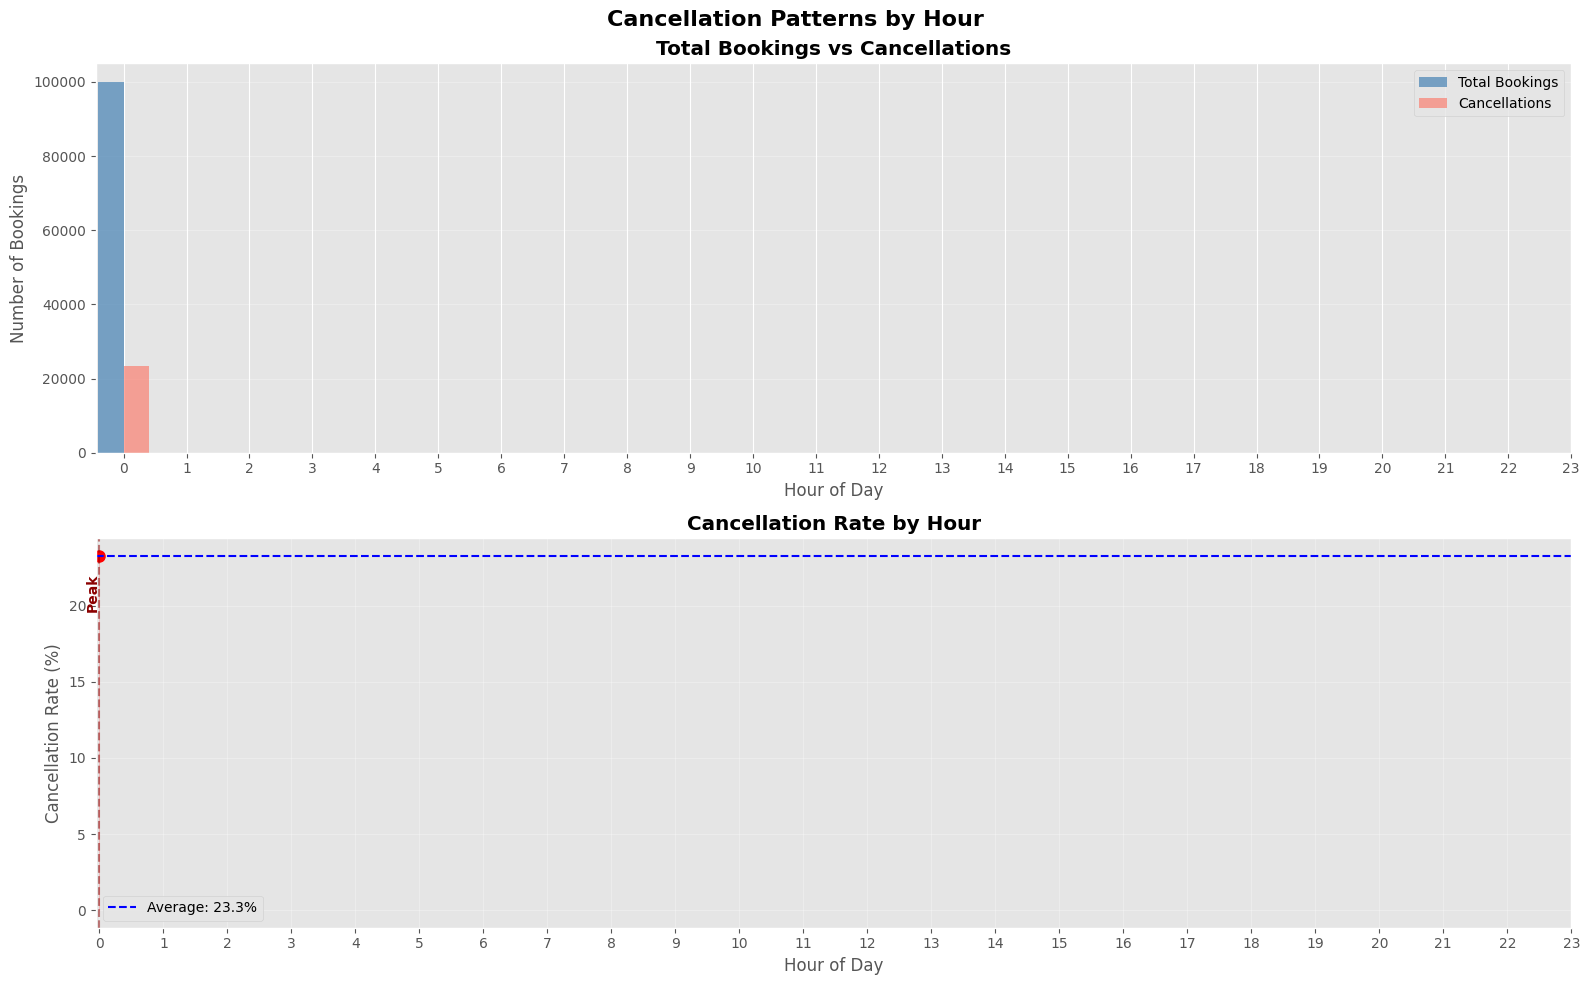


💾 Saved: cancellation_by_hour.png


In [ ]:
"""
Cell 36: Cancellation Patterns by Hour of Day
"""

print("⏰ CANCELLATIONS BY HOUR OF DAY")
print("="*70)

if datetime_col and status_col and 'hour' in df_bookings.columns:
    # Filter cancelled bookings
    cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

    # Count cancellations by hour
    hourly_cancellations = cancelled_df['hour'].value_counts().sort_index()
    hourly_total = df_bookings['hour'].value_counts().sort_index()

    # Calculate cancellation rate by hour
    hourly_cancel_rate = (hourly_cancellations / hourly_total * 100).fillna(0)

    print("\n📊 CANCELLATION RATE BY HOUR:\n")
    for hour in range(24):
        if hour in hourly_cancel_rate.index:
            rate = hourly_cancel_rate[hour]
            total = hourly_total.get(hour, 0)
            cancelled = hourly_cancellations.get(hour, 0)
            print(f"   {hour:02d}:00 - Rate: {rate:5.2f}% ({cancelled:4,}/{total:5,})")

    # Identify peak cancellation hours
    peak_cancel_hours = hourly_cancel_rate.nlargest(5)

    print("\n" + "="*70)
    print("🔝 TOP 5 HOURS WITH HIGHEST CANCELLATION RATE:")
    print("="*70)
    for hour, rate in peak_cancel_hours.items():
        print(f"   {hour:02d}:00 - {rate:.2f}%")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Cancellation Patterns by Hour', fontsize=16, fontweight='bold')

    # Absolute numbers
    x = hourly_total.index
    width = 0.4

    ax1.bar([i - width/2 for i in x], hourly_total.values, width,
           label='Total Bookings', color='steelblue', alpha=0.7)
    ax1.bar([i + width/2 for i in x],
           [hourly_cancellations.get(h, 0) for h in x], width,
           label='Cancellations', color='salmon', alpha=0.7)
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Number of Bookings')
    ax1.set_title('Total Bookings vs Cancellations', fontweight='bold')
    ax1.set_xticks(range(24))
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Cancellation rate
    ax2.plot(hourly_cancel_rate.index, hourly_cancel_rate.values,
            marker='o', linewidth=2, markersize=8, color='red')
    ax2.fill_between(hourly_cancel_rate.index, hourly_cancel_rate.values,
                     alpha=0.3, color='red')
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Cancellation Rate (%)')
    ax2.set_title('Cancellation Rate by Hour', fontweight='bold')
    ax2.set_xticks(range(24))
    ax2.grid(alpha=0.3)

    # Highlight peak hours
    for hour in peak_cancel_hours.index[:3]:
        ax2.axvline(x=hour, color='darkred', linestyle='--', alpha=0.5)
        ax2.text(hour, hourly_cancel_rate.max() * 0.95, 'Peak',
                rotation=90, va='top', ha='right', color='darkred', fontweight='bold')

    # Add average line
    avg_cancel_rate = hourly_cancel_rate.mean()
    ax2.axhline(y=avg_cancel_rate, color='blue', linestyle='--',
               label=f'Average: {avg_cancel_rate:.1f}%')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'cancellation_by_hour.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: cancellation_by_hour.png")

else:
    print("⚠️ Required columns not available for this analysis")

📅 CANCELLATIONS BY DAY OF WEEK

📊 CANCELLATION RATE BY DAY:

   Monday    : 23.11% (3,272/14,159)
   Tuesday   : 23.40% (3,302/14,109)
   Wednesday : 23.77% (3,461/14,558)
   Thursday  : 23.46% (3,363/14,336)
   Friday    : 22.94% (3,306/14,411)
   Saturday  : 23.05% (3,269/14,182)
   Sunday    : 23.24% (3,311/14,245)

📊 WEEKDAY vs WEEKEND CANCELLATION:
Weekday: 23.34%
Weekend: 23.15%
✅ Cancellation rates are similar across week


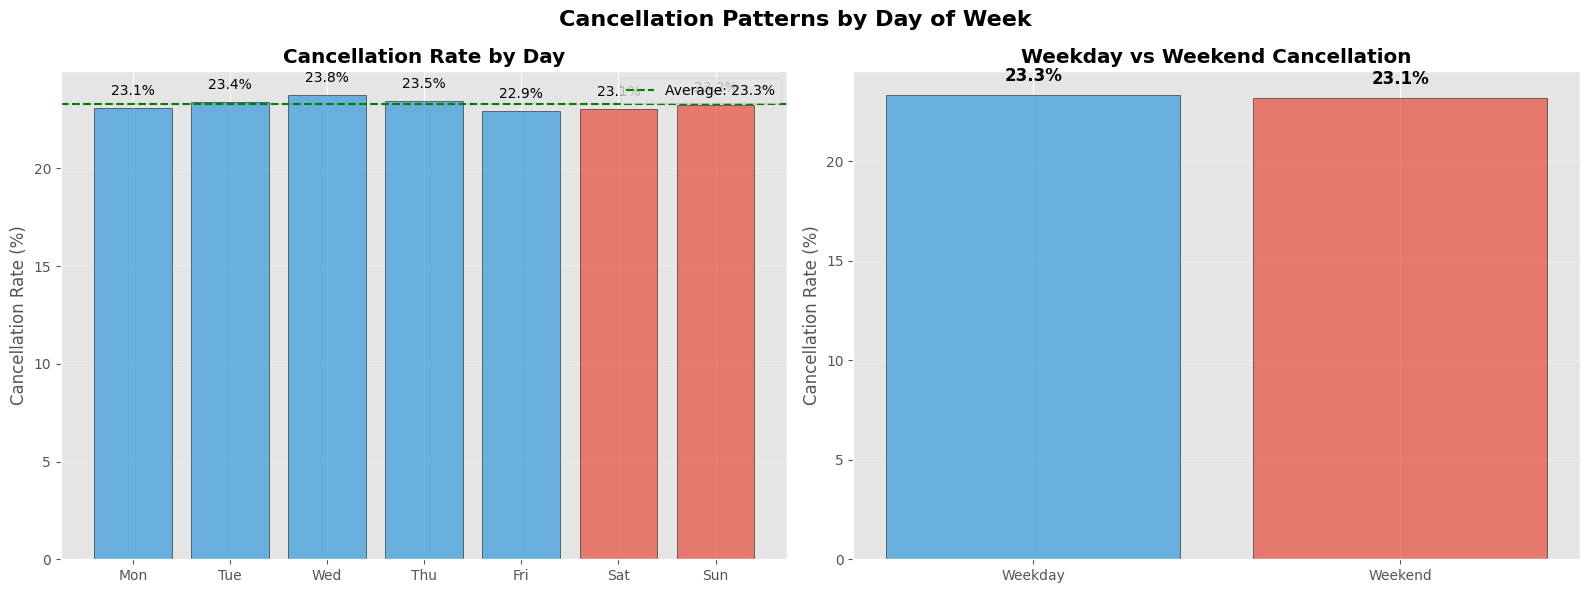


💾 Saved: cancellation_by_day.png


In [ ]:
"""
Cell 37: Cancellation Patterns by Day of Week
"""

print("📅 CANCELLATIONS BY DAY OF WEEK")
print("="*70)

if 'day_name' in df_bookings.columns and status_col:
    # Filter cancelled bookings
    cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

    # Count by day
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    daily_cancellations = cancelled_df['day_name'].value_counts()
    daily_total = df_bookings['day_name'].value_counts()

    # Calculate rate
    daily_cancel_rate = {}
    for day in day_order:
        if day in daily_total.index:
            rate = (daily_cancellations.get(day, 0) / daily_total[day]) * 100
            daily_cancel_rate[day] = rate

    daily_cancel_rate = pd.Series(daily_cancel_rate)

    print("\n📊 CANCELLATION RATE BY DAY:\n")
    for day, rate in daily_cancel_rate.items():
        total = daily_total.get(day, 0)
        cancelled = daily_cancellations.get(day, 0)
        print(f"   {day:10s}: {rate:5.2f}% ({cancelled:5,}/{total:6,})")

    # Weekday vs Weekend comparison
    weekday_mask = df_bookings['day_of_week'] < 5
    weekend_mask = df_bookings['day_of_week'] >= 5

    weekday_cancel_rate = (
        df_bookings[weekday_mask][status_col].str.lower().str.contains('cancel', na=False).sum() /
        weekday_mask.sum()
    ) * 100

    weekend_cancel_rate = (
        df_bookings[weekend_mask][status_col].str.lower().str.contains('cancel', na=False).sum() /
        weekend_mask.sum()
    ) * 100

    print("\n" + "="*70)
    print("📊 WEEKDAY vs WEEKEND CANCELLATION:")
    print("="*70)
    print(f"Weekday: {weekday_cancel_rate:.2f}%")
    print(f"Weekend: {weekend_cancel_rate:.2f}%")

    if weekend_cancel_rate > weekday_cancel_rate * 1.1:
        print("⚠️ Weekend cancellations are significantly higher!")
    elif weekday_cancel_rate > weekend_cancel_rate * 1.1:
        print("⚠️ Weekday cancellations are significantly higher!")
    else:
        print("✅ Cancellation rates are similar across week")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cancellation Patterns by Day of Week', fontsize=16, fontweight='bold')

    # Bar chart
    colors = ['#3498db' if day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
              else '#e74c3c' for day in daily_cancel_rate.index]

    ax1.bar(range(len(daily_cancel_rate)), daily_cancel_rate.values,
           color=colors, edgecolor='black', alpha=0.7)
    ax1.set_xticks(range(len(daily_cancel_rate)))
    ax1.set_xticklabels([day[:3] for day in daily_cancel_rate.index])
    ax1.set_ylabel('Cancellation Rate (%)')
    ax1.set_title('Cancellation Rate by Day', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(daily_cancel_rate.values):
        ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

    # Add average line
    avg_rate = daily_cancel_rate.mean()
    ax1.axhline(y=avg_rate, color='green', linestyle='--',
               label=f'Average: {avg_rate:.1f}%')
    ax1.legend()

    # Weekday vs Weekend comparison
    weekday_weekend_data = pd.Series({
        'Weekday': weekday_cancel_rate,
        'Weekend': weekend_cancel_rate
    })

    ax2.bar(weekday_weekend_data.index, weekday_weekend_data.values,
           color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
    ax2.set_ylabel('Cancellation Rate (%)')
    ax2.set_title('Weekday vs Weekend Cancellation', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(weekday_weekend_data.values):
        ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'cancellation_by_day.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: cancellation_by_day.png")

else:
    print("⚠️ Required columns not available")

🚗 CANCELLATIONS BY VEHICLE TYPE

Using column: vehicle_type

📊 CANCELLATION RATE BY VEHICLE TYPE:

   Auto           : 23.41% (7,770/33,191)
   Cab            : 23.27% (7,775/33,415)
   Bike           : 23.17% (7,739/33,394)


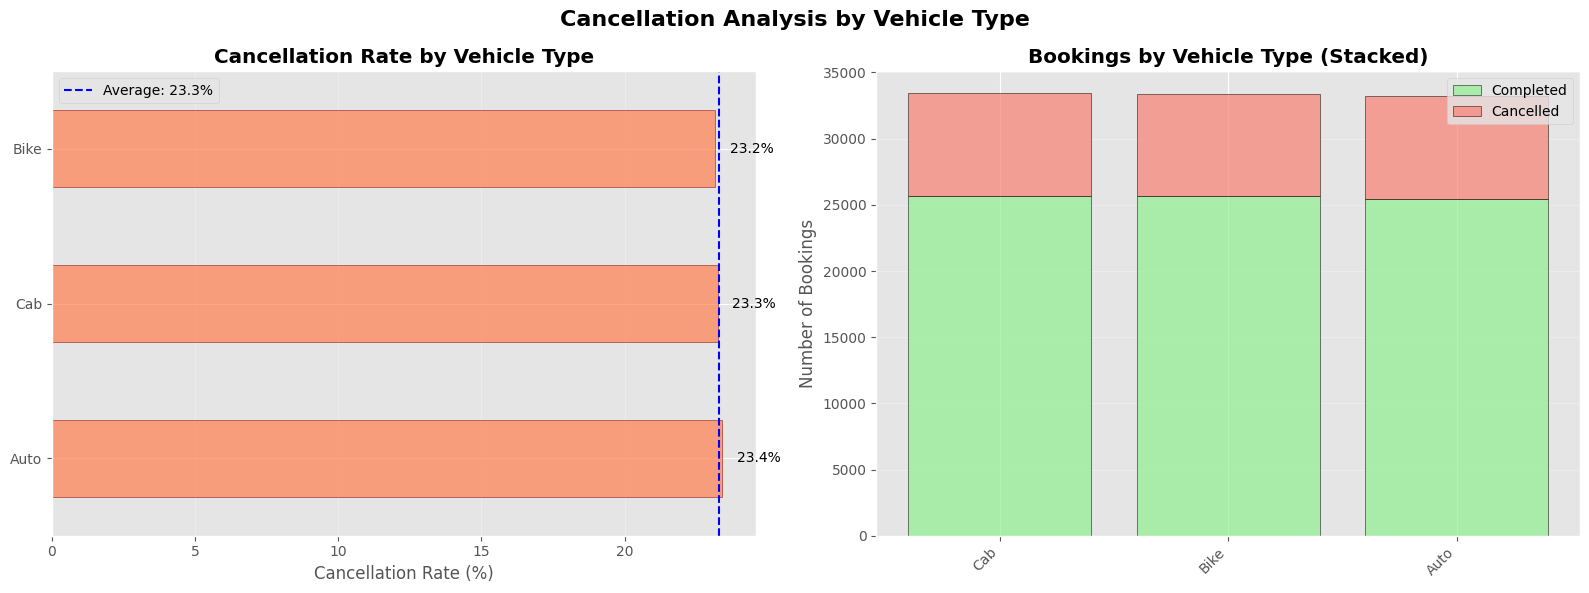


💾 Saved: cancellation_by_vehicle.png


In [ ]:
"""
Cell 38: Cancellation Analysis by Vehicle Type
"""

print("🚗 CANCELLATIONS BY VEHICLE TYPE")
print("="*70)

# Find vehicle type column
vehicle_cols = [col for col in df_bookings.columns
                if any(keyword in col.lower() for keyword in ['vehicle', 'type', 'category'])]

if vehicle_cols and status_col:
    vehicle_col = vehicle_cols[0]
    print(f"\nUsing column: {vehicle_col}\n")

    # Calculate cancellation rate by vehicle type
    cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

    vehicle_total = df_bookings[vehicle_col].value_counts()
    vehicle_cancellations = cancelled_df[vehicle_col].value_counts()

    # Calculate rates
    vehicle_cancel_rate = {}
    for vehicle in vehicle_total.index:
        total = vehicle_total[vehicle]
        cancelled = vehicle_cancellations.get(vehicle, 0)
        rate = (cancelled / total) * 100
        vehicle_cancel_rate[vehicle] = rate

    vehicle_cancel_rate = pd.Series(vehicle_cancel_rate).sort_values(ascending=False)

    print("📊 CANCELLATION RATE BY VEHICLE TYPE:\n")
    for vehicle, rate in vehicle_cancel_rate.items():
        total = vehicle_total[vehicle]
        cancelled = vehicle_cancellations.get(vehicle, 0)
        print(f"   {vehicle:15s}: {rate:5.2f}% ({cancelled:5,}/{total:6,})")

    # Identify problematic vehicle types
    avg_rate = vehicle_cancel_rate.mean()
    high_cancel_vehicles = vehicle_cancel_rate[vehicle_cancel_rate > avg_rate * 1.2]

    if len(high_cancel_vehicles) > 0:
        print("\n" + "="*70)
        print("⚠️ VEHICLE TYPES WITH HIGH CANCELLATION (>20% above average):")
        print("="*70)
        for vehicle, rate in high_cancel_vehicles.items():
            print(f"   {vehicle}: {rate:.2f}%")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cancellation Analysis by Vehicle Type', fontsize=16, fontweight='bold')

    # Cancellation rate
    vehicle_cancel_rate.plot(kind='barh', ax=ax1, color='coral',
                             edgecolor='darkred', alpha=0.7)
    ax1.set_xlabel('Cancellation Rate (%)')
    ax1.set_title('Cancellation Rate by Vehicle Type', fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(vehicle_cancel_rate.values):
        ax1.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

    # Add average line
    ax1.axvline(x=avg_rate, color='blue', linestyle='--',
               label=f'Average: {avg_rate:.1f}%')
    ax1.legend()

    # Stacked bar - Total vs Cancelled
    x = range(len(vehicle_total))
    completed = vehicle_total - vehicle_cancellations.reindex(vehicle_total.index, fill_value=0)

    ax2.bar(x, completed.values, label='Completed', color='lightgreen',
           edgecolor='black', alpha=0.7)
    ax2.bar(x, vehicle_cancellations.reindex(vehicle_total.index, fill_value=0).values,
           bottom=completed.values, label='Cancelled', color='salmon',
           edgecolor='black', alpha=0.7)

    ax2.set_xticks(x)
    ax2.set_xticklabels(vehicle_total.index, rotation=45, ha='right')
    ax2.set_ylabel('Number of Bookings')
    ax2.set_title('Bookings by Vehicle Type (Stacked)', fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'cancellation_by_vehicle.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: cancellation_by_vehicle.png")

else:
    print("⚠️ Vehicle type or status column not found")

👤 CUSTOMER vs DRIVER CANCELLATIONS

Using cancellation reason column: incomplete_ride_reason

📊 TOP 10 CANCELLATION REASONS:

    1. Unknown: 23,284 (100.00%)


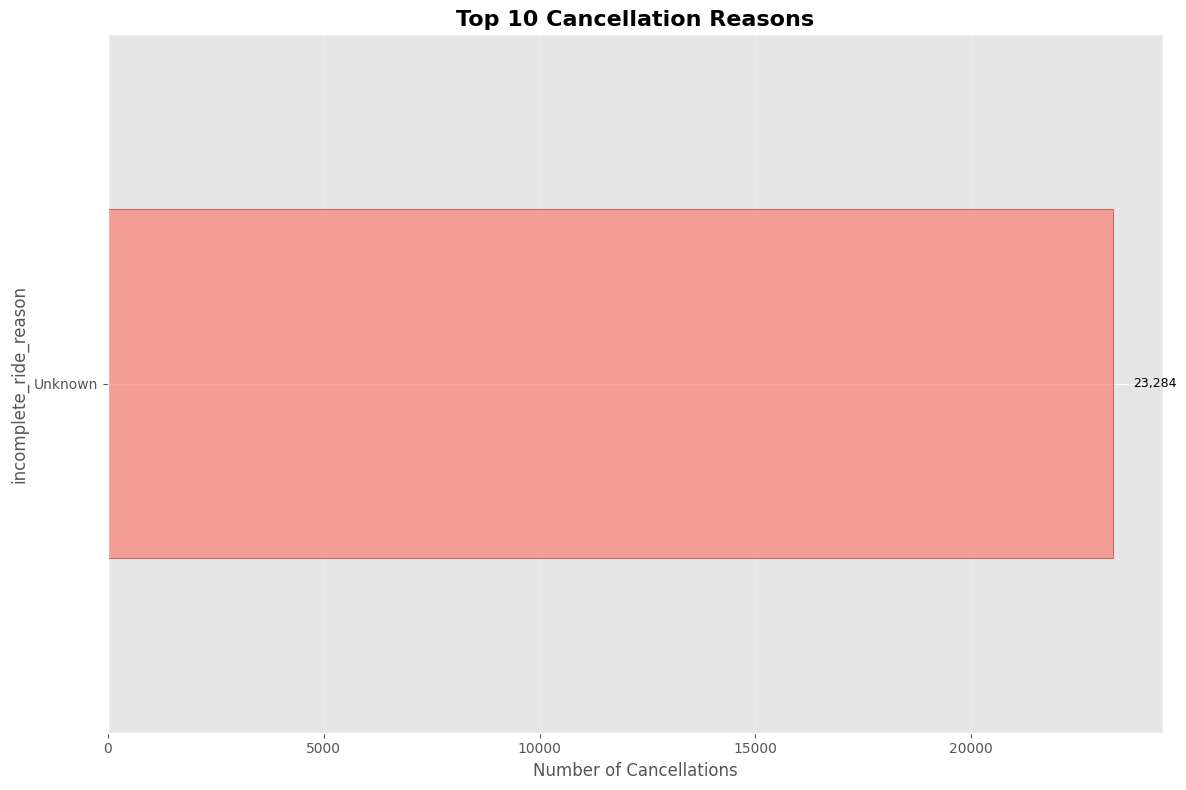


💾 Saved: cancellation_reasons.png


In [ ]:
"""
Cell 39: Who Cancels More - Customer or Driver?
"""

print("👤 CUSTOMER vs DRIVER CANCELLATIONS")
print("="*70)

# Look for cancellation reason or cancelled_by column
cancel_by_cols = [col for col in df_bookings.columns
                  if any(keyword in col.lower() for keyword in ['cancelled_by', 'canceled_by', 'cancel_by'])]

reason_cols = [col for col in df_bookings.columns
               if 'reason' in col.lower() or 'cause' in col.lower()]

if cancel_by_cols:
    cancel_by_col = cancel_by_cols[0]
    print(f"\nUsing column: {cancel_by_col}\n")

    # Filter only cancelled bookings
    cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

    if len(cancelled_df) > 0:
        # Count by who cancelled
        cancelled_by = cancelled_df[cancel_by_col].value_counts()

        print("📊 CANCELLATIONS BY PARTY:\n")
        for party, count in cancelled_by.items():
            pct = (count / len(cancelled_df)) * 100
            print(f"   {party}: {count:,} ({pct:.2f}%)")

        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('Customer vs Driver Cancellations', fontsize=16, fontweight='bold')

        # Pie chart
        colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
        ax1.pie(cancelled_by.values, labels=cancelled_by.index, autopct='%1.1f%%',
               startangle=90, colors=colors[:len(cancelled_by)], explode=[0.1]*len(cancelled_by))
        ax1.set_title('Distribution of Cancellations', fontweight='bold')

        # Bar chart
        cancelled_by.plot(kind='bar', ax=ax2, color=colors[:len(cancelled_by)],
                         edgecolor='black', alpha=0.7)
        ax2.set_ylabel('Number of Cancellations')
        ax2.set_title('Cancellations Count', fontweight='bold')
        ax2.set_xlabel('')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(axis='y', alpha=0.3)

        # Add value labels
        for i, v in enumerate(cancelled_by.values):
            ax2.text(i, v + (cancelled_by.max() * 0.02), f'{v:,}',
                    ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_PATH, 'cancellation_customer_vs_driver.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n💾 Saved: cancellation_customer_vs_driver.png")

        # Analysis
        print("\n" + "="*70)
        print("📊 ANALYSIS:")
        print("="*70)

        # Check if customer or driver cancels more
        if 'customer' in cancelled_by.index[0].lower():
            print("⚠️ Customers cancel more often than drivers")
            print("   → Focus on customer experience and pricing")
        elif 'driver' in cancelled_by.index[0].lower():
            print("⚠️ Drivers cancel more often than customers")
            print("   → Focus on driver incentives and matching")

    else:
        print("⚠️ No cancelled bookings found")

elif reason_cols:
    # Alternative: Analyze cancellation reasons
    reason_col = reason_cols[0]
    print(f"\nUsing cancellation reason column: {reason_col}\n")

    cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]

    if len(cancelled_df) > 0:
        reasons = cancelled_df[reason_col].value_counts().head(10)

        print("📊 TOP 10 CANCELLATION REASONS:\n")
        for idx, (reason, count) in enumerate(reasons.items(), 1):
            pct = (count / len(cancelled_df)) * 100
            print(f"   {idx:2d}. {reason}: {count:,} ({pct:.2f}%)")

        # Visualization
        fig, ax = plt.subplots(figsize=(12, 8))
        reasons.plot(kind='barh', ax=ax, color='salmon', edgecolor='darkred', alpha=0.7)
        ax.set_xlabel('Number of Cancellations')
        ax.set_title('Top 10 Cancellation Reasons', fontsize=16, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Add value labels
        for i, v in enumerate(reasons.values):
            ax.text(v + (reasons.max() * 0.02), i, f'{v:,}',
                   va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_PATH, 'cancellation_reasons.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n💾 Saved: cancellation_reasons.png")

else:
    print("⚠️ No cancellation party or reason column found")
    print("\nAttempting to infer from available data...")

    # Simple analysis without specific column
    if status_col:
        cancelled_df = df_bookings[df_bookings[status_col].str.lower().str.contains('cancel', na=False)]
        print(f"\nTotal cancellations: {len(cancelled_df):,}")
        print(f"Cancellation rate: {len(cancelled_df)/len(df_bookings)*100:.2f}%")

🔥 CANCELLATION HEATMAP - TIME PATTERNS


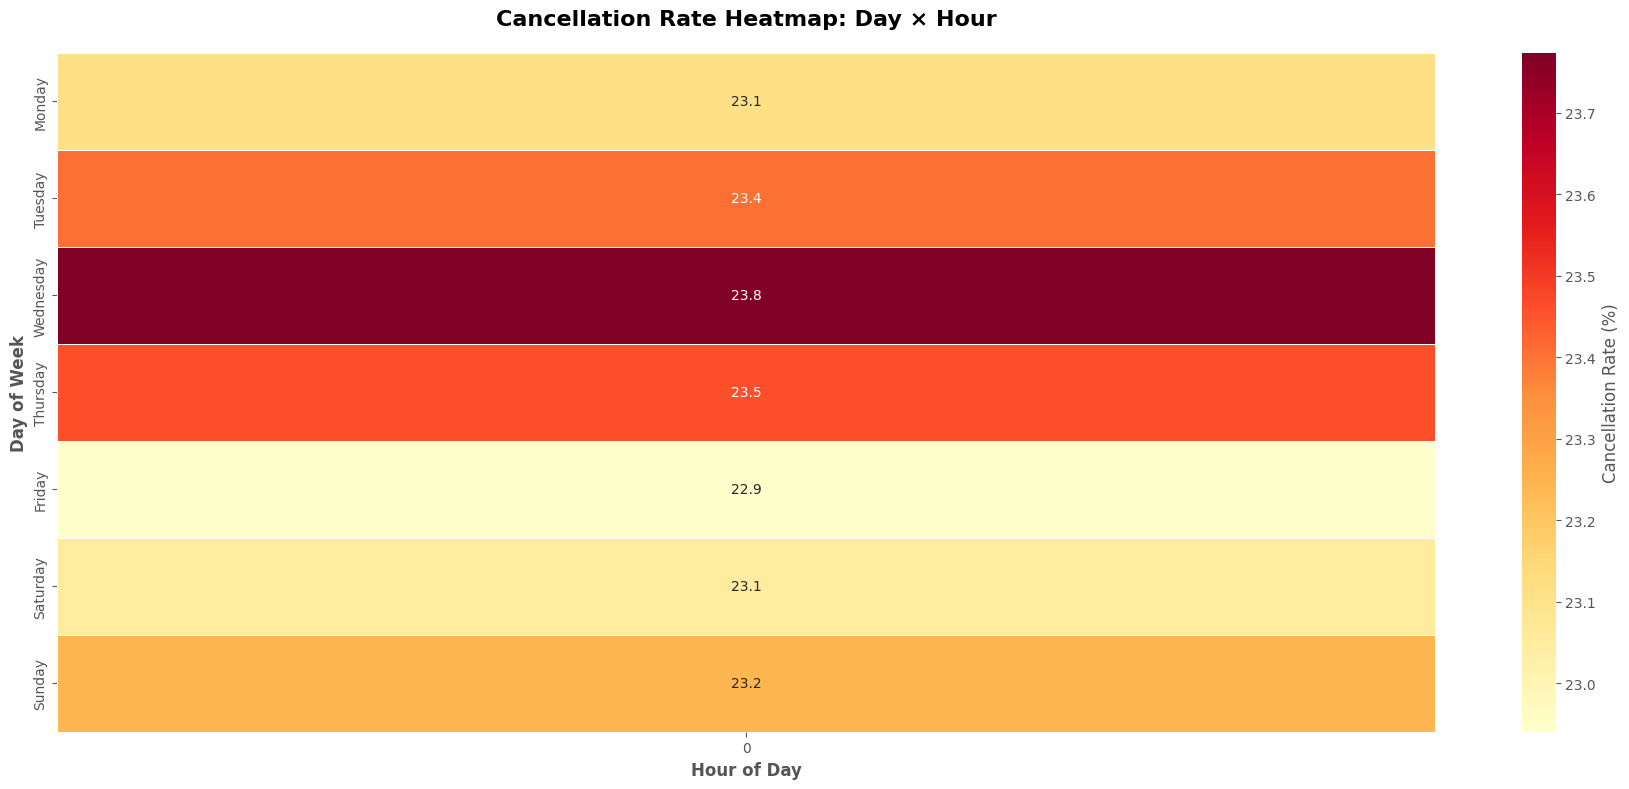


💾 Saved: cancellation_heatmap.png

🔝 TOP 10 PEAK CANCELLATION SLOTS (Day-Hour combinations):
    1. Wednesday at 00:00 - 23.77% cancellation rate
    2. Thursday at 00:00 - 23.46% cancellation rate
    3. Tuesday at 00:00 - 23.40% cancellation rate
    4. Sunday at 00:00 - 23.24% cancellation rate
    5. Monday at 00:00 - 23.11% cancellation rate
    6. Saturday at 00:00 - 23.05% cancellation rate
    7. Friday at 00:00 - 22.94% cancellation rate

✅ TOP 10 SAFEST SLOTS (Lowest cancellation):
    1. Friday at 00:00 - 22.94% cancellation rate
    2. Saturday at 00:00 - 23.05% cancellation rate
    3. Monday at 00:00 - 23.11% cancellation rate
    4. Sunday at 00:00 - 23.24% cancellation rate
    5. Tuesday at 00:00 - 23.40% cancellation rate
    6. Thursday at 00:00 - 23.46% cancellation rate
    7. Wednesday at 00:00 - 23.77% cancellation rate


In [ ]:
"""
Cell 40: Cancellation Heatmap - Hour x Day
"""

print("🔥 CANCELLATION HEATMAP - TIME PATTERNS")
print("="*70)

if 'hour' in df_bookings.columns and 'day_name' in df_bookings.columns and status_col:

    # Create is_cancelled flag
    df_bookings['is_cancelled'] = df_bookings[status_col].str.lower().str.contains('cancel', na=False)

    # Create pivot table
    cancellation_pivot = df_bookings.pivot_table(
        values='is_cancelled',
        index='day_name',
        columns='hour',
        aggfunc='mean'
    ) * 100  # Convert to percentage

    # Reorder days
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    cancellation_pivot = cancellation_pivot.reindex([d for d in day_order if d in cancellation_pivot.index])

    # Visualization
    fig, ax = plt.subplots(figsize=(18, 8))

    sns.heatmap(cancellation_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                cbar_kws={'label': 'Cancellation Rate (%)'},
                linewidths=0.5, ax=ax)

    ax.set_title('Cancellation Rate Heatmap: Day × Hour',
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    ax.set_ylabel('Day of Week', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'cancellation_heatmap.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: cancellation_heatmap.png")

    # Find peak cancellation slots
    print("\n" + "="*70)
    print("🔝 TOP 10 PEAK CANCELLATION SLOTS (Day-Hour combinations):")
    print("="*70)

    # Flatten the pivot table to find top slots
    cancellation_flat = cancellation_pivot.stack().sort_values(ascending=False).head(10)

    for idx, ((day, hour), rate) in enumerate(cancellation_flat.items(), 1):
        print(f"   {idx:2d}. {day} at {hour:02d}:00 - {rate:.2f}% cancellation rate")

    # Find safest slots
    print("\n" + "="*70)
    print("✅ TOP 10 SAFEST SLOTS (Lowest cancellation):")
    print("="*70)

    safest_slots = cancellation_pivot.stack().sort_values(ascending=True).head(10)

    for idx, ((day, hour), rate) in enumerate(safest_slots.items(), 1):
        print(f"   {idx:2d}. {day} at {hour:02d}:00 - {rate:.2f}% cancellation rate")

else:
    print("⚠️ Required columns not available for heatmap")

💰 FARE ANALYSIS: DISTANCE vs FARE

Analyzing:
  Distance: ride_distance_km
  Fare: base_fare

📊 CORRELATION COEFFICIENT: 0.7230
   ⚠️ Moderate correlation - other factors also affect pricing

💰 AVERAGE FARE PER KM: ₹15.51


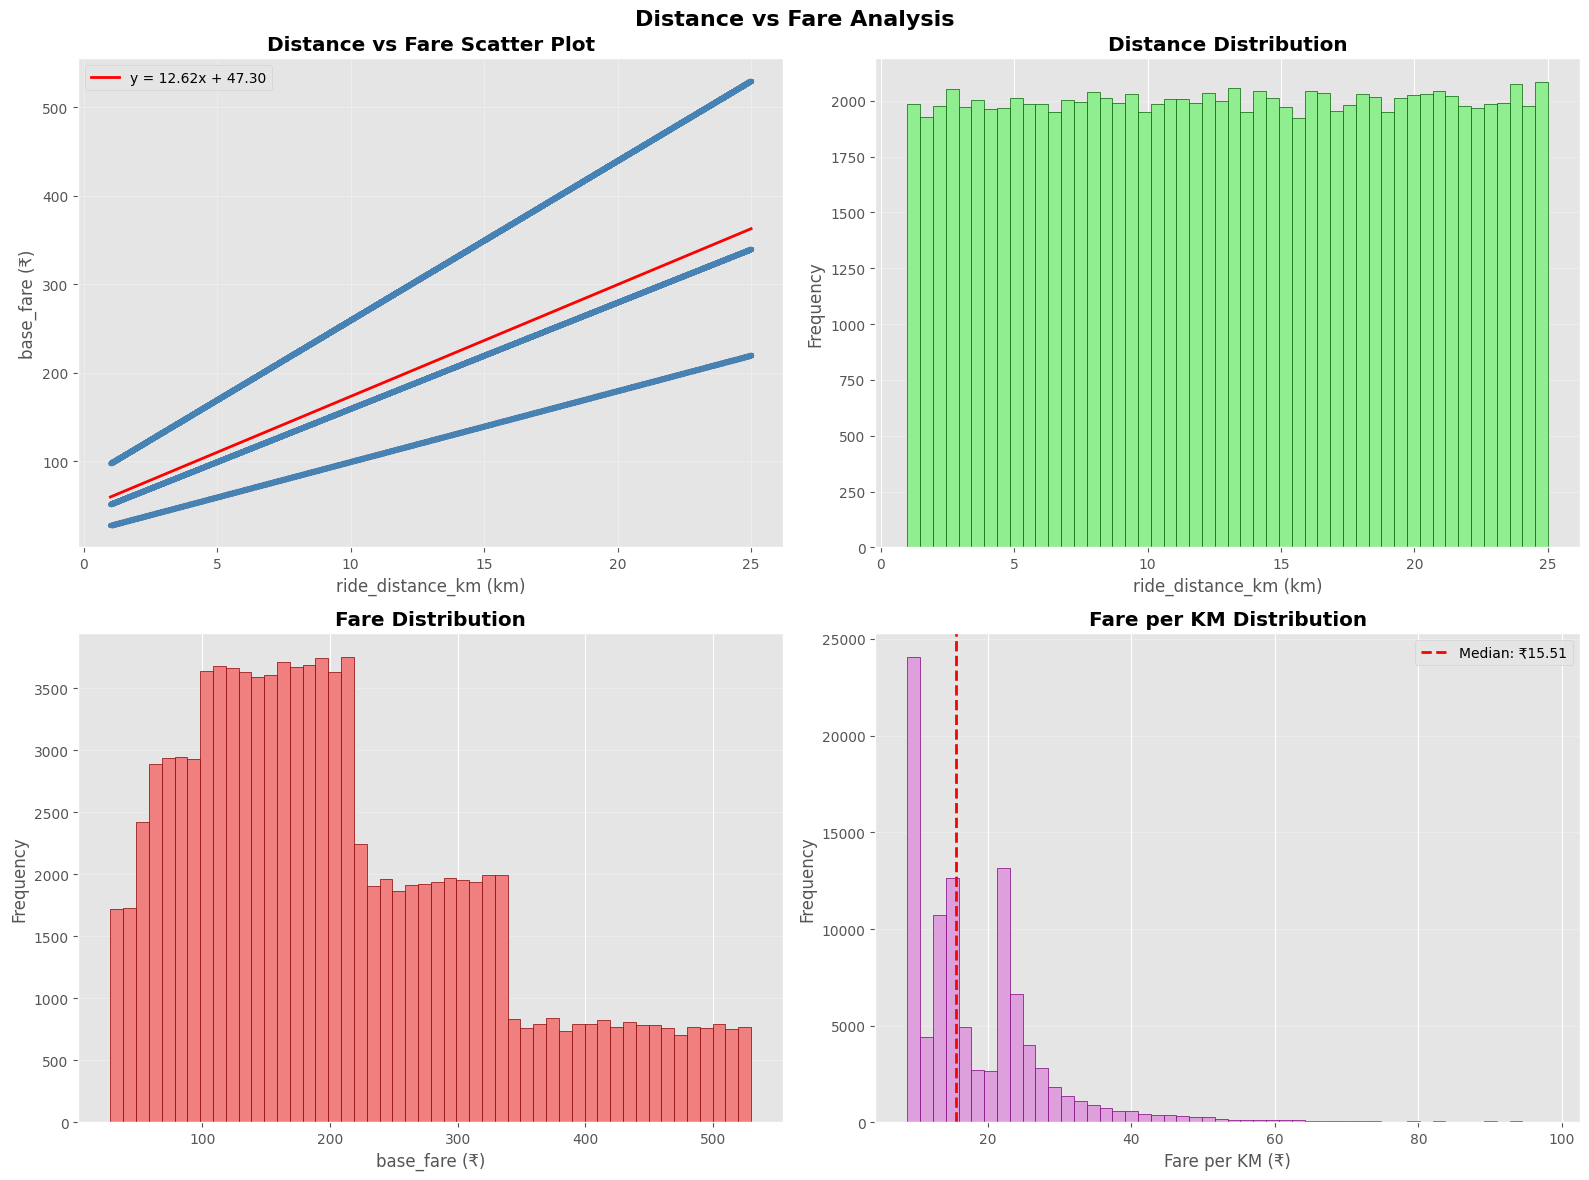


💾 Saved: distance_vs_fare.png

📊 FARE STATISTICS:
Average fare: ₹211.68
Median fare: ₹187.34
Min fare: ₹28.02
Max fare: ₹529.96

📊 DISTANCE STATISTICS:
Average distance: 13.03 km
Median distance: 13.03 km
Min distance: 1.00 km
Max distance: 25.00 km


In [ ]:
"""
Cell 41: Analyze Distance vs Fare Correlation
"""

print("💰 FARE ANALYSIS: DISTANCE vs FARE")
print("="*70)

# Find distance and fare columns
distance_cols = [col for col in df_bookings.columns
                 if 'distance' in col.lower() or 'km' in col.lower()]
fare_cols = [col for col in df_bookings.columns
             if any(keyword in col.lower() for keyword in ['fare', 'value', 'price', 'amount', 'cost'])]

if distance_cols and fare_cols:
    distance_col = distance_cols[0]
    fare_col = fare_cols[0]

    print(f"\nAnalyzing:")
    print(f"  Distance: {distance_col}")
    print(f"  Fare: {fare_col}\n")

    # Calculate correlation
    correlation = df_bookings[[distance_col, fare_col]].corr().iloc[0, 1]

    print(f"📊 CORRELATION COEFFICIENT: {correlation:.4f}")

    if correlation > 0.8:
        print("   ✅ Strong positive correlation - pricing is distance-based")
    elif correlation > 0.5:
        print("   ⚠️ Moderate correlation - other factors also affect pricing")
    else:
        print("   🚨 Weak correlation - pricing may not be primarily distance-based")

    # Calculate fare per km
    df_bookings['fare_per_km'] = df_bookings[fare_col] / df_bookings[distance_col]
    df_bookings['fare_per_km'] = df_bookings['fare_per_km'].replace([np.inf, -np.inf], np.nan)

    avg_fare_per_km = df_bookings['fare_per_km'].median()

    print(f"\n💰 AVERAGE FARE PER KM: ₹{avg_fare_per_km:.2f}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Distance vs Fare Analysis', fontsize=16, fontweight='bold')

    # Scatter plot
    axes[0, 0].scatter(df_bookings[distance_col], df_bookings[fare_col],
                      alpha=0.3, s=10, color='steelblue')
    axes[0, 0].set_xlabel(f'{distance_col} (km)')
    axes[0, 0].set_ylabel(f'{fare_col} (₹)')
    axes[0, 0].set_title('Distance vs Fare Scatter Plot', fontweight='bold')
    axes[0, 0].grid(alpha=0.3)

    # Add regression line
    from scipy.stats import linregress
    mask = ~(df_bookings[distance_col].isna() | df_bookings[fare_col].isna())
    if mask.sum() > 0:
        slope, intercept, r_value, p_value, std_err = linregress(
            df_bookings.loc[mask, distance_col],
            df_bookings.loc[mask, fare_col]
        )
        x_line = np.linspace(df_bookings[distance_col].min(),
                            df_bookings[distance_col].max(), 100)
        y_line = slope * x_line + intercept
        axes[0, 0].plot(x_line, y_line, 'r-', linewidth=2,
                       label=f'y = {slope:.2f}x + {intercept:.2f}')
        axes[0, 0].legend()

    # Distance distribution
    df_bookings[distance_col].hist(bins=50, ax=axes[0, 1],
                                   color='lightgreen', edgecolor='darkgreen')
    axes[0, 1].set_xlabel(f'{distance_col} (km)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distance Distribution', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Fare distribution
    df_bookings[fare_col].hist(bins=50, ax=axes[1, 0],
                               color='lightcoral', edgecolor='darkred')
    axes[1, 0].set_xlabel(f'{fare_col} (₹)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Fare Distribution', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Fare per km distribution
    df_bookings['fare_per_km'].hist(bins=50, ax=axes[1, 1],
                                    color='plum', edgecolor='purple')
    axes[1, 1].set_xlabel('Fare per KM (₹)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Fare per KM Distribution', fontweight='bold')
    axes[1, 1].axvline(x=avg_fare_per_km, color='red', linestyle='--',
                      linewidth=2, label=f'Median: ₹{avg_fare_per_km:.2f}')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'distance_vs_fare.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: distance_vs_fare.png")

    # Statistics
    print("\n" + "="*70)
    print("📊 FARE STATISTICS:")
    print("="*70)
    print(f"Average fare: ₹{df_bookings[fare_col].mean():.2f}")
    print(f"Median fare: ₹{df_bookings[fare_col].median():.2f}")
    print(f"Min fare: ₹{df_bookings[fare_col].min():.2f}")
    print(f"Max fare: ₹{df_bookings[fare_col].max():.2f}")

    print("\n" + "="*70)
    print("📊 DISTANCE STATISTICS:")
    print("="*70)
    print(f"Average distance: {df_bookings[distance_col].mean():.2f} km")
    print(f"Median distance: {df_bookings[distance_col].median():.2f} km")
    print(f"Min distance: {df_bookings[distance_col].min():.2f} km")
    print(f"Max distance: {df_bookings[distance_col].max():.2f} km")

else:
    print("⚠️ Distance or fare column not found")

🚗 FARE ANALYSIS BY VEHICLE TYPE

Analyzing fare by vehicle_type

📊 FARE STATISTICS BY VEHICLE TYPE:


,count,mean,median,min,max,std
vehicle_type,,,,,,
Auto,33191,312.36,298.34,49.73,810.32,150.33
Bike,33394,197.56,188.56,27.28,530.36,98.77
Cab,33415,491.19,477.41,94.48,852.36,210.41



💰 Most expensive (avg): Cab - ₹491.19
💵 Least expensive (avg): Bike - ₹197.56


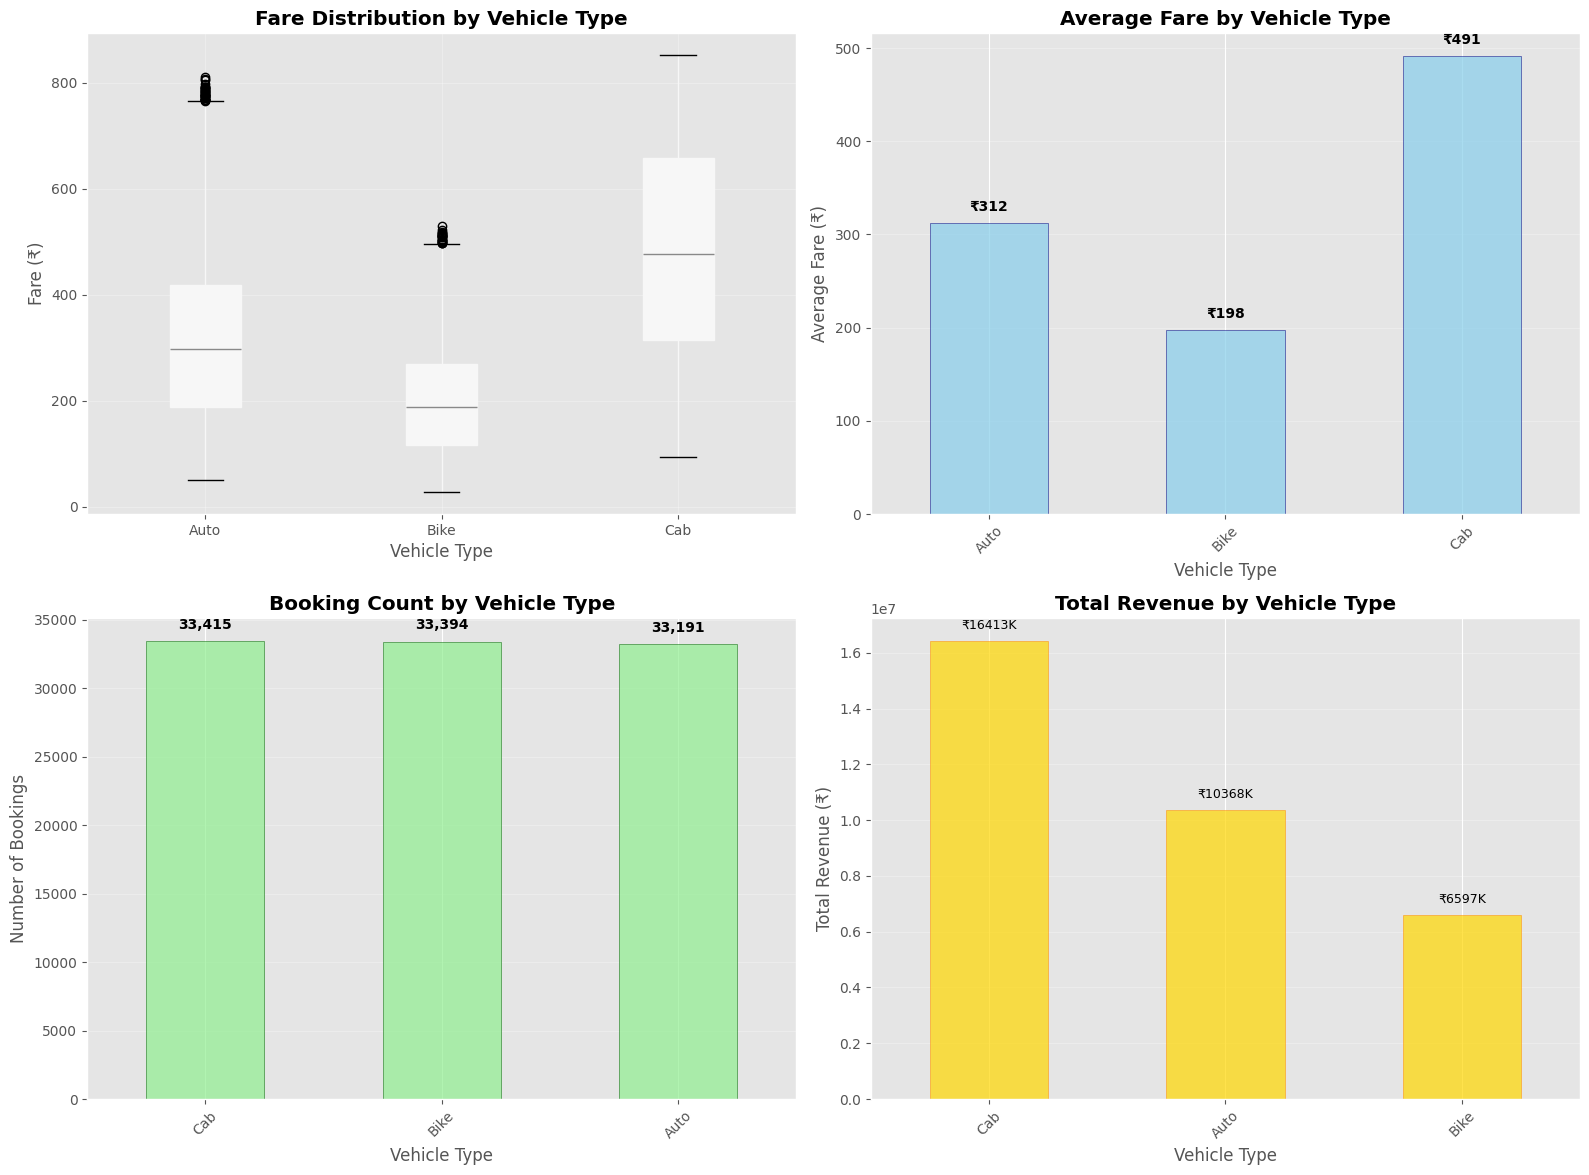


💾 Saved: fare_by_vehicle_type.png

📊 MEDIAN FARE PER KM BY VEHICLE TYPE:
   Auto: ₹25.23/km
   Bike: ₹15.87/km
   Cab: ₹39.35/km


In [ ]:
"""
Cell 42: Fare Analysis by Vehicle Type
"""

print("🚗 FARE ANALYSIS BY VEHICLE TYPE")
print("="*70)

# Check if we have vehicle type and fare columns
vehicle_col = 'vehicle_type' if 'vehicle_type' in df_bookings.columns else None
fare_col = 'booking_value' if 'booking_value' in df_bookings.columns else None

if vehicle_col and fare_col:
    print(f"\nAnalyzing fare by {vehicle_col}\n")

    # Calculate statistics by vehicle type
    fare_by_vehicle = df_bookings.groupby(vehicle_col)[fare_col].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('min', 'min'),
        ('max', 'max'),
        ('std', 'std')
    ]).round(2)

    print("📊 FARE STATISTICS BY VEHICLE TYPE:")
    print("="*70)
    display(fare_by_vehicle)

    # Identify most/least expensive vehicle types
    most_expensive = fare_by_vehicle['mean'].idxmax()
    least_expensive = fare_by_vehicle['mean'].idxmin()

    print("\n" + "="*70)
    print(f"💰 Most expensive (avg): {most_expensive} - ₹{fare_by_vehicle.loc[most_expensive, 'mean']:.2f}")
    print(f"💵 Least expensive (avg): {least_expensive} - ₹{fare_by_vehicle.loc[least_expensive, 'mean']:.2f}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Fare Analysis by Vehicle Type', fontsize=16, fontweight='bold')

    # Box plot
    df_bookings.boxplot(column=fare_col, by=vehicle_col, ax=axes[0, 0],
                        patch_artist=True)
    axes[0, 0].set_title('Fare Distribution by Vehicle Type', fontweight='bold')
    axes[0, 0].set_xlabel('Vehicle Type')
    axes[0, 0].set_ylabel('Fare (₹)')
    axes[0, 0].get_figure().suptitle('')  # Remove auto title
    axes[0, 0].grid(alpha=0.3)

    # Average fare bar chart
    fare_by_vehicle['mean'].plot(kind='bar', ax=axes[0, 1],
                                  color='skyblue', edgecolor='navy', alpha=0.7)
    axes[0, 1].set_title('Average Fare by Vehicle Type', fontweight='bold')
    axes[0, 1].set_ylabel('Average Fare (₹)')
    axes[0, 1].set_xlabel('Vehicle Type')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(fare_by_vehicle['mean'].values):
        axes[0, 1].text(i, v + (fare_by_vehicle['mean'].max() * 0.02),
                       f'₹{v:.0f}', ha='center', va='bottom', fontweight='bold')

    # Count by vehicle type
    vehicle_counts = df_bookings[vehicle_col].value_counts()
    vehicle_counts.plot(kind='bar', ax=axes[1, 0],
                       color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    axes[1, 0].set_title('Booking Count by Vehicle Type', fontweight='bold')
    axes[1, 0].set_ylabel('Number of Bookings')
    axes[1, 0].set_xlabel('Vehicle Type')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(vehicle_counts.values):
        axes[1, 0].text(i, v + (vehicle_counts.max() * 0.02),
                       f'{v:,}', ha='center', va='bottom', fontweight='bold')

    # Revenue by vehicle type (total fare)
    revenue_by_vehicle = df_bookings.groupby(vehicle_col)[fare_col].sum().sort_values(ascending=False)
    revenue_by_vehicle.plot(kind='bar', ax=axes[1, 1],
                           color='gold', edgecolor='darkorange', alpha=0.7)
    axes[1, 1].set_title('Total Revenue by Vehicle Type', fontweight='bold')
    axes[1, 1].set_ylabel('Total Revenue (₹)')
    axes[1, 1].set_xlabel('Vehicle Type')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(revenue_by_vehicle.values):
        axes[1, 1].text(i, v + (revenue_by_vehicle.max() * 0.02),
                       f'₹{v/1000:.0f}K', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'fare_by_vehicle_type.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: fare_by_vehicle_type.png")

    # Calculate fare per km by vehicle type if distance column exists
    if 'ride_distance_km' in df_bookings.columns:
        fare_per_km_vehicle = df_bookings.groupby(vehicle_col).apply(
            lambda x: (x[fare_col] / x['ride_distance_km']).median()
        ).round(2)

        print("\n" + "="*70)
        print("📊 MEDIAN FARE PER KM BY VEHICLE TYPE:")
        print("="*70)
        for vehicle, fare_per_km in fare_per_km_vehicle.items():
            print(f"   {vehicle}: ₹{fare_per_km:.2f}/km")

else:
    print("⚠️ Vehicle type or fare column not found")
    if not vehicle_col:
        print(f"   Missing: vehicle_type column")
    if not fare_col:
        print(f"   Missing: booking_value/fare column")

📈 SURGE PRICING ANALYSIS

Analyzing surge pricing patterns...

📊 SURGE MULTIPLIER STATISTICS:
Mean: 1.59x
Median: 1.60x
Min: 1.00x
Max: 2.30x
Std Dev: 0.33

📊 BOOKINGS BY SURGE CATEGORY:
   Medium Surge (1.5-2.0x): 47,856 (47.86%)
   Low Surge (1.0-1.5x): 37,760 (37.76%)
   No Surge (1.0x): 7,950 (7.95%)
   High Surge (>2.0x): 6,434 (6.43%)

💰 SURGE REVENUE IMPACT:
Average base fare: ₹211.68
Average actual fare: ₹333.78
Average surge uplift: ₹122.10 (57.7%)

📊 AVERAGE SURGE BY HOUR:
   00:00 - 1.59x


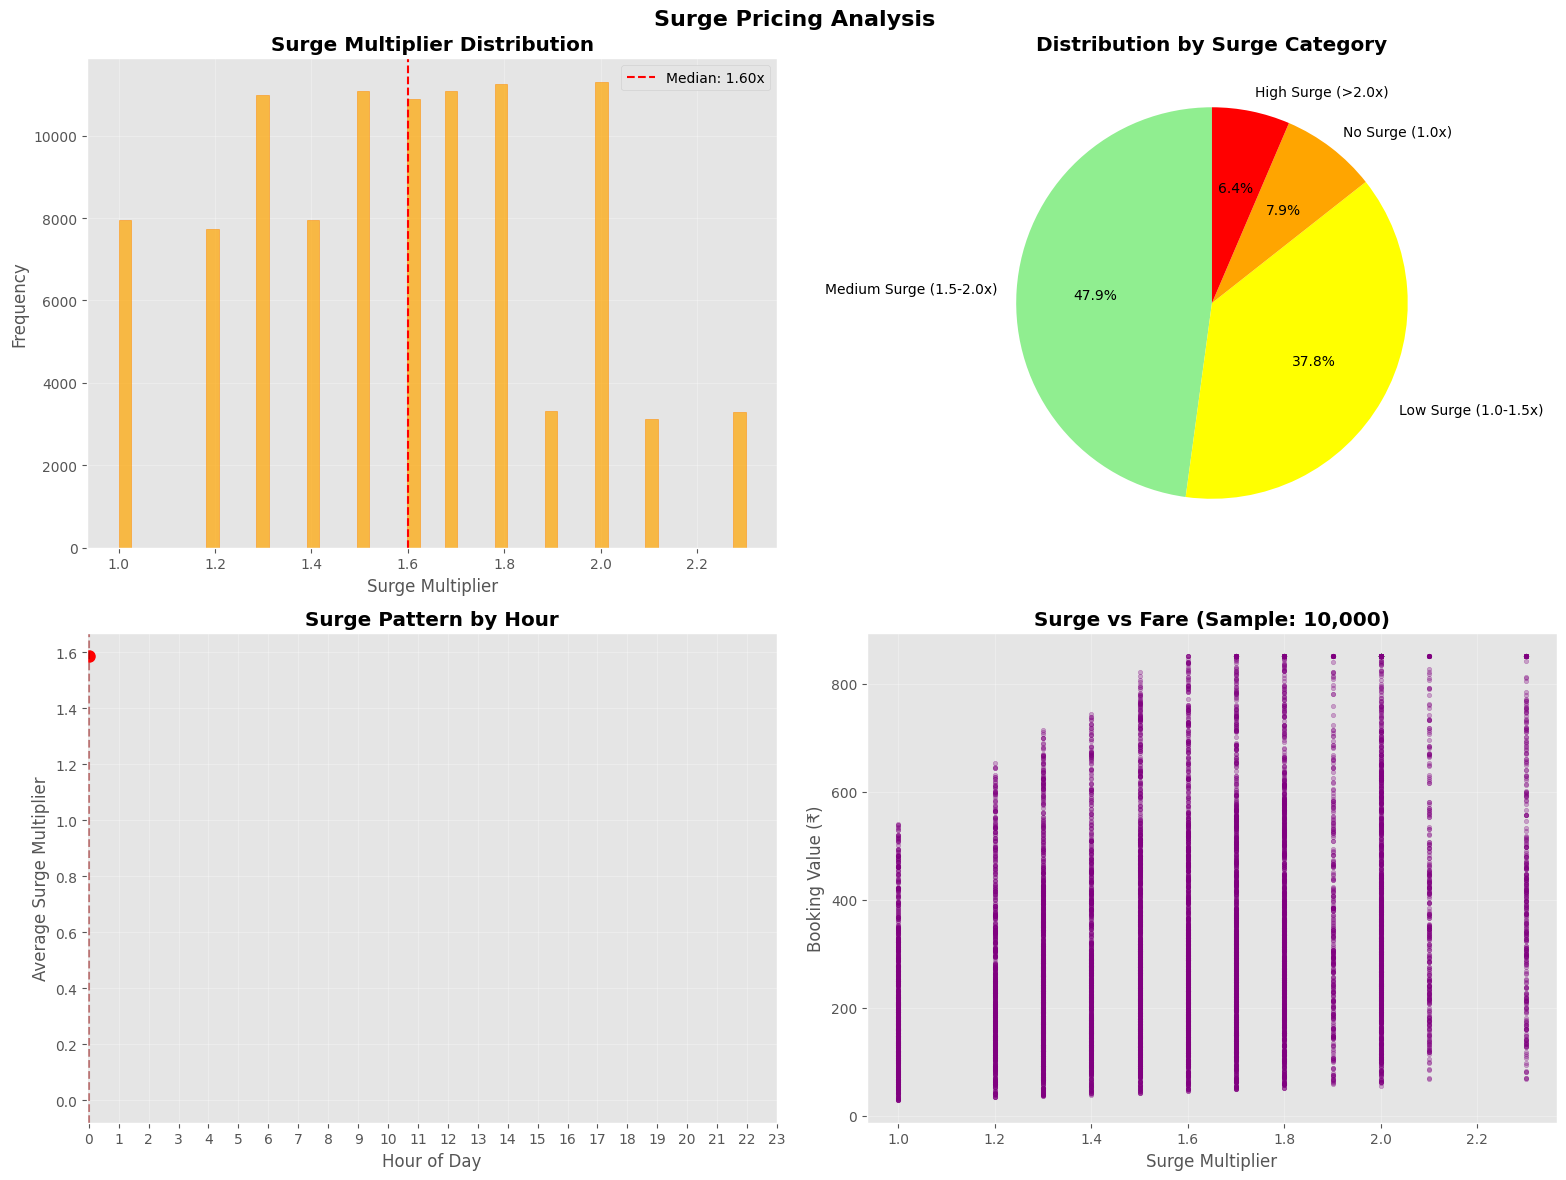


💾 Saved: surge_pricing_analysis.png


In [ ]:
"""
Cell 43: Surge Pricing Pattern Analysis
"""

print("📈 SURGE PRICING ANALYSIS")
print("="*70)

surge_col = 'surge_multiplier' if 'surge_multiplier' in df_bookings.columns else None
fare_col = 'booking_value' if 'booking_value' in df_bookings.columns else None

if surge_col and fare_col:
    print(f"\nAnalyzing surge pricing patterns...\n")

    # Calculate surge statistics
    surge_stats = df_bookings[surge_col].describe()

    print("📊 SURGE MULTIPLIER STATISTICS:")
    print("="*70)
    print(f"Mean: {surge_stats['mean']:.2f}x")
    print(f"Median: {surge_stats['50%']:.2f}x")
    print(f"Min: {surge_stats['min']:.2f}x")
    print(f"Max: {surge_stats['max']:.2f}x")
    print(f"Std Dev: {surge_stats['std']:.2f}")

    # Create surge categories
    df_bookings['surge_category'] = pd.cut(
        df_bookings[surge_col],
        bins=[0, 1.0, 1.5, 2.0, float('inf')],
        labels=['No Surge (1.0x)', 'Low Surge (1.0-1.5x)',
                'Medium Surge (1.5-2.0x)', 'High Surge (>2.0x)'],
        include_lowest=True
    )

    # Count by surge category
    surge_category_counts = df_bookings['surge_category'].value_counts()

    print("\n" + "="*70)
    print("📊 BOOKINGS BY SURGE CATEGORY:")
    print("="*70)
    for category, count in surge_category_counts.items():
        pct = (count / len(df_bookings)) * 100
        print(f"   {category}: {count:,} ({pct:.2f}%)")

    # Calculate surge impact on fare
    base_fare_col = 'base_fare' if 'base_fare' in df_bookings.columns else None

    if base_fare_col:
        avg_base_fare = df_bookings[base_fare_col].mean()
        avg_surge_fare = df_bookings[fare_col].mean()
        surge_revenue_impact = avg_surge_fare - avg_base_fare

        print("\n" + "="*70)
        print("💰 SURGE REVENUE IMPACT:")
        print("="*70)
        print(f"Average base fare: ₹{avg_base_fare:.2f}")
        print(f"Average actual fare: ₹{avg_surge_fare:.2f}")
        print(f"Average surge uplift: ₹{surge_revenue_impact:.2f} ({(surge_revenue_impact/avg_base_fare*100):.1f}%)")

    # Surge by hour
    if 'hour' in df_bookings.columns:
        surge_by_hour = df_bookings.groupby('hour')[surge_col].mean()

        print("\n" + "="*70)
        print("📊 AVERAGE SURGE BY HOUR:")
        print("="*70)
        peak_surge_hours = surge_by_hour.nlargest(5)
        for hour, surge in peak_surge_hours.items():
            print(f"   {hour:02d}:00 - {surge:.2f}x")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Surge Pricing Analysis', fontsize=16, fontweight='bold')

    # Surge distribution
    df_bookings[surge_col].hist(bins=50, ax=axes[0, 0],
                                color='orange', edgecolor='darkorange', alpha=0.7)
    axes[0, 0].set_xlabel('Surge Multiplier')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Surge Multiplier Distribution', fontweight='bold')
    axes[0, 0].axvline(x=surge_stats['50%'], color='red', linestyle='--',
                      label=f"Median: {surge_stats['50%']:.2f}x")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Surge category pie chart
    surge_category_counts.plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%',
                               startangle=90, colors=['lightgreen', 'yellow', 'orange', 'red'])
    axes[0, 1].set_ylabel('')
    axes[0, 1].set_title('Distribution by Surge Category', fontweight='bold')

    # Surge by hour (if available)
    if 'hour' in df_bookings.columns:
        surge_by_hour.plot(ax=axes[1, 0], marker='o', linewidth=2,
                          markersize=8, color='red')
        axes[1, 0].fill_between(surge_by_hour.index, surge_by_hour.values, alpha=0.3)
        axes[1, 0].set_xlabel('Hour of Day')
        axes[1, 0].set_ylabel('Average Surge Multiplier')
        axes[1, 0].set_title('Surge Pattern by Hour', fontweight='bold')
        axes[1, 0].set_xticks(range(24))
        axes[1, 0].grid(alpha=0.3)

        # Highlight peak surge hours
        for hour in peak_surge_hours.index[:3]:
            axes[1, 0].axvline(x=hour, color='darkred', linestyle='--', alpha=0.5)
    else:
        axes[1, 0].text(0.5, 0.5, 'Hour data not available',
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].axis('off')

    # Fare vs Surge scatter
    sample_size = min(10000, len(df_bookings))
    sample_df = df_bookings.sample(n=sample_size, random_state=42)

    axes[1, 1].scatter(sample_df[surge_col], sample_df[fare_col],
                      alpha=0.3, s=10, color='purple')
    axes[1, 1].set_xlabel('Surge Multiplier')
    axes[1, 1].set_ylabel('Booking Value (₹)')
    axes[1, 1].set_title(f'Surge vs Fare (Sample: {sample_size:,})', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'surge_pricing_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: surge_pricing_analysis.png")

else:
    print("⚠️ Surge multiplier or fare column not found")

🌦️ TRAFFIC & WEATHER IMPACT ANALYSIS

📊 TRAFFIC LEVEL ANALYSIS

🚦 Distribution by Traffic Level:

   High: 33,667 (33.67%)
   Medium: 33,198 (33.20%)
   Low: 33,135 (33.13%)

📊 BOOKING STATUS BY TRAFFIC LEVEL (%):


booking_status,Cancelled,Completed,Incomplete
traffic_level,,,
High,33.50,51.67,14.82
Low,18.26,76.60,5.14
Medium,17.93,77.02,5.05



🚫 Cancellation Rate by Traffic Level:
   High: 33.50%
   Low: 18.26%
   Medium: 17.93%

💰 FARE BY TRAFFIC LEVEL:


,mean,median,count
traffic_level,,,
High,374.19,329.94,33667
Low,293.18,253.65,33135
Medium,333.32,291.31,33198



⏱️ TIME DELAY BY TRAFFIC LEVEL (Actual - Estimated, in minutes):


,mean,median
traffic_level,,
High,-10.94,0.00
Low,6.08,2.00
Medium,2.41,2.00



🌤️ WEATHER CONDITION ANALYSIS

☀️ Distribution by Weather Condition:

   Heavy Rain: 33,616 (33.62%)
   Clear: 33,200 (33.20%)
   Rain: 33,184 (33.18%)

📊 BOOKING STATUS BY WEATHER CONDITION (%):


booking_status,Cancelled,Completed,Incomplete
weather_condition,,,
Clear,10.01,81.71,8.28
Heavy Rain,33.67,57.93,8.40
Rain,26.04,65.53,8.43



🚫 Cancellation Rate by Weather:
   Clear: 10.01%
   Heavy Rain: 33.67%
   Rain: 26.04%

💰 FARE BY WEATHER CONDITION:


,mean,median,count
weather_condition,,,
Clear,271.74,235.77,33200
Heavy Rain,392.90,348.40,33616
Rain,335.96,295.58,33184


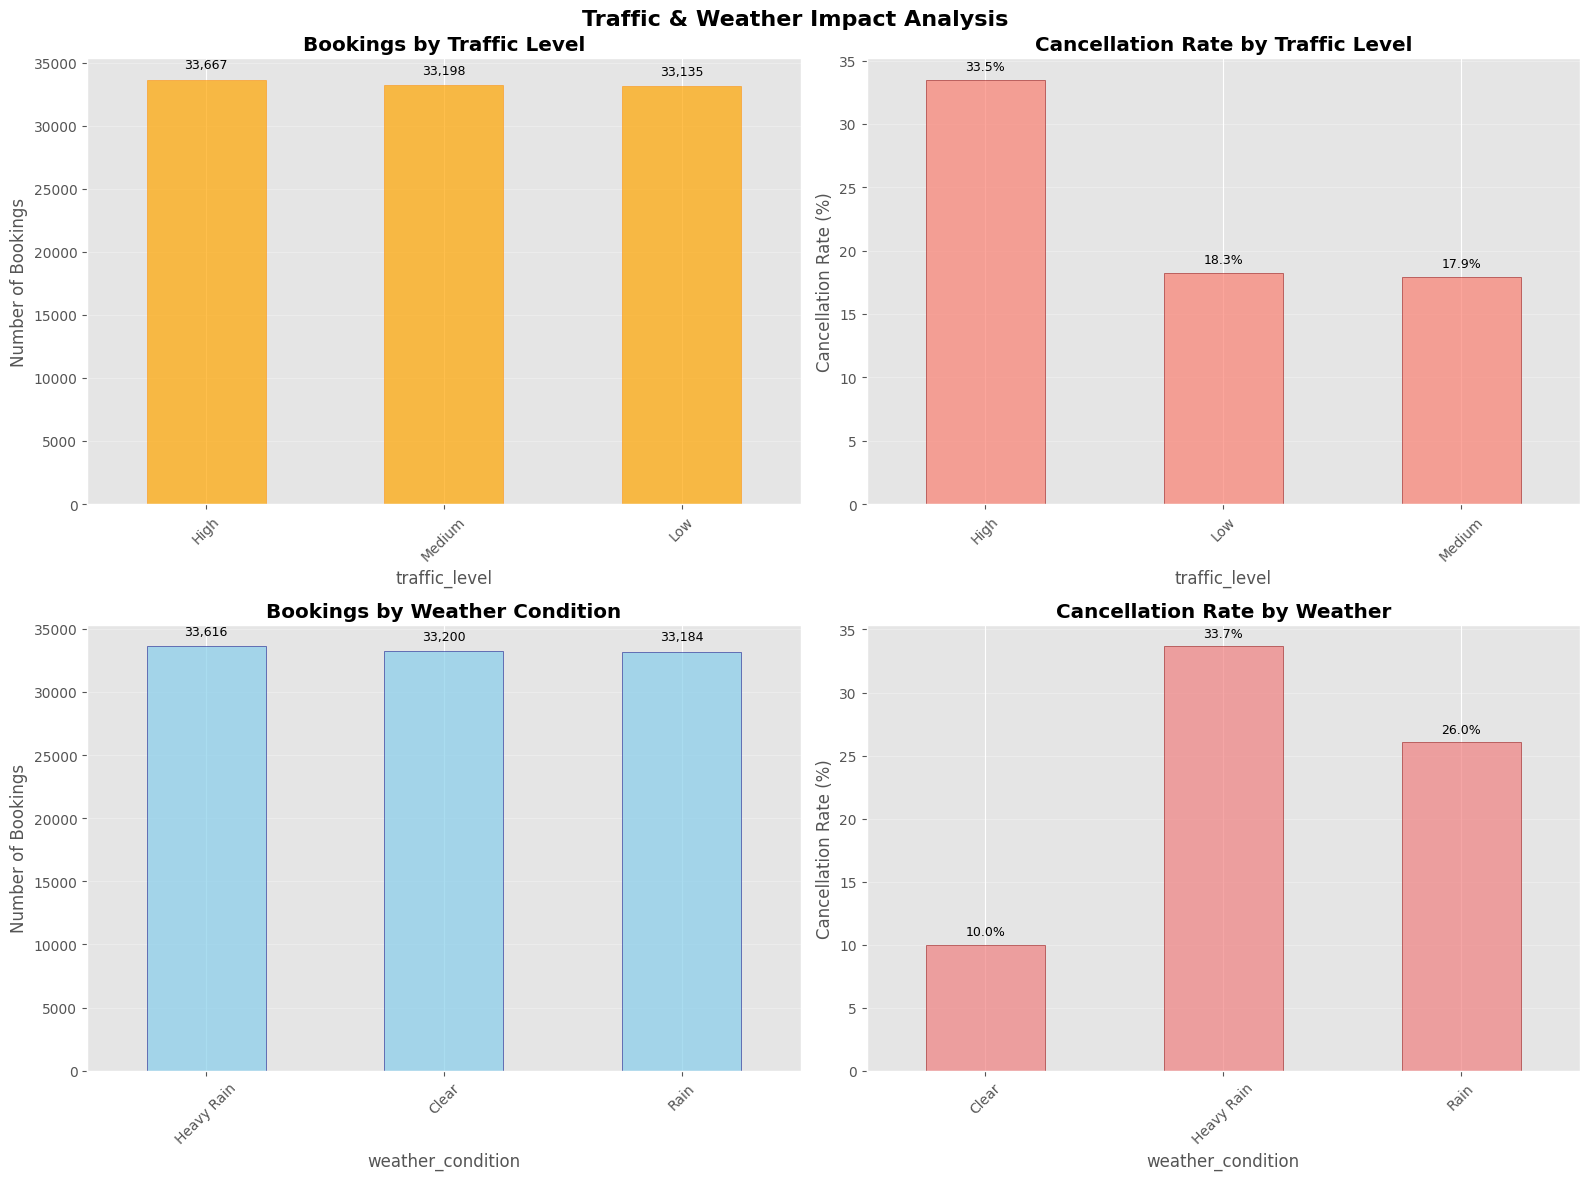


💾 Saved: traffic_weather_analysis.png

💡 KEY INSIGHTS:

🚦 Traffic Impact:
   Highest cancellations: High (33.50%)
   Lowest cancellations: Medium (17.93%)
   ⚠️ High traffic increases cancellations by 86.8%

🌤️ Weather Impact:
   Highest cancellations: Heavy Rain (33.67%)
   Lowest cancellations: Clear (10.01%)
   ⚠️ Heavy Rain weather increases cancellations by 236.4%

⏱️ Time Delay Impact:
   Low traffic adds average 6.1 minutes to ride time

   Average delays by traffic level:
      High: -10.9 min
      Low: 6.1 min
      Medium: 2.4 min

💰 Revenue Impact:
   Fare varies by ₹81.01 across traffic conditions
   Highest fare: High (₹374.19)
   Lowest fare: Low (₹293.18)

   Fare varies by ₹121.16 across weather conditions

✅ Traffic & Weather Analysis Complete!


In [ ]:
"""
Cell 44: Traffic & Weather Impact Analysis
"""

print("🌦️ TRAFFIC & WEATHER IMPACT ANALYSIS")
print("="*70)

# Check for traffic and weather columns
traffic_col = 'traffic_level' if 'traffic_level' in df_bookings.columns else None
weather_col = 'weather_condition' if 'weather_condition' in df_bookings.columns else None

# ==================
# TRAFFIC ANALYSIS
# ==================
if traffic_col:
    print(f"\n📊 TRAFFIC LEVEL ANALYSIS")
    print("="*70)

    # Count by traffic level
    traffic_counts = df_bookings[traffic_col].value_counts()
    traffic_pct = df_bookings[traffic_col].value_counts(normalize=True) * 100

    print("\n🚦 Distribution by Traffic Level:\n")
    for level, count in traffic_counts.items():
        pct = traffic_pct[level]
        print(f"   {level}: {count:,} ({pct:.2f}%)")

    # Traffic impact on cancellations
    if status_col:
        traffic_cancel = pd.crosstab(
            df_bookings[traffic_col],
            df_bookings[status_col],
            normalize='index'
        ) * 100

        print("\n" + "="*70)
        print("📊 BOOKING STATUS BY TRAFFIC LEVEL (%):")
        print("="*70)
        display(traffic_cancel.round(2))

        # Calculate cancellation rate by traffic
        cancelled_mask = df_bookings[status_col].str.lower().str.contains('cancel', na=False)
        cancel_by_traffic = df_bookings.groupby(traffic_col).apply(
            lambda x: (x[status_col].str.lower().str.contains('cancel', na=False).sum() / len(x)) * 100
        ).round(2)

        print("\n🚫 Cancellation Rate by Traffic Level:")
        for level, rate in cancel_by_traffic.items():
            print(f"   {level}: {rate:.2f}%")

    # Traffic impact on fare
    if fare_col:
        fare_by_traffic = df_bookings.groupby(traffic_col)[fare_col].agg([
            ('mean', 'mean'),
            ('median', 'median'),
            ('count', 'count')
        ]).round(2)

        print("\n" + "="*70)
        print("💰 FARE BY TRAFFIC LEVEL:")
        print("="*70)
        display(fare_by_traffic)

    # Traffic impact on ride time
    if 'actual_ride_time_min' in df_bookings.columns and 'estimated_ride_time_min' in df_bookings.columns:
        # Calculate time delay as numeric (not timedelta)
        df_bookings['time_delay_min'] = (
            pd.to_numeric(df_bookings['actual_ride_time_min'], errors='coerce') -
            pd.to_numeric(df_bookings['estimated_ride_time_min'], errors='coerce')
        )

        delay_by_traffic = df_bookings.groupby(traffic_col)['time_delay_min'].agg([
            ('mean', 'mean'),
            ('median', 'median')
        ]).round(2)

        print("\n" + "="*70)
        print("⏱️ TIME DELAY BY TRAFFIC LEVEL (Actual - Estimated, in minutes):")
        print("="*70)
        display(delay_by_traffic)

else:
    print("\n⚠️ No traffic level column found")

# ==================
# WEATHER ANALYSIS
# ==================
if weather_col:
    print("\n" + "="*70)
    print(f"🌤️ WEATHER CONDITION ANALYSIS")
    print("="*70)

    # Count by weather
    weather_counts = df_bookings[weather_col].value_counts()
    weather_pct = df_bookings[weather_col].value_counts(normalize=True) * 100

    print("\n☀️ Distribution by Weather Condition:\n")
    for condition, count in weather_counts.items():
        pct = weather_pct[condition]
        print(f"   {condition}: {count:,} ({pct:.2f}%)")

    # Weather impact on cancellations
    if status_col:
        weather_cancel = pd.crosstab(
            df_bookings[weather_col],
            df_bookings[status_col],
            normalize='index'
        ) * 100

        print("\n" + "="*70)
        print("📊 BOOKING STATUS BY WEATHER CONDITION (%):")
        print("="*70)
        display(weather_cancel.round(2))

        # Calculate cancellation rate by weather
        cancel_by_weather = df_bookings.groupby(weather_col).apply(
            lambda x: (x[status_col].str.lower().str.contains('cancel', na=False).sum() / len(x)) * 100
        ).round(2)

        print("\n🚫 Cancellation Rate by Weather:")
        for condition, rate in cancel_by_weather.items():
            print(f"   {condition}: {rate:.2f}%")

    # Weather impact on fare
    if fare_col:
        fare_by_weather = df_bookings.groupby(weather_col)[fare_col].agg([
            ('mean', 'mean'),
            ('median', 'median'),
            ('count', 'count')
        ]).round(2)

        print("\n" + "="*70)
        print("💰 FARE BY WEATHER CONDITION:")
        print("="*70)
        display(fare_by_weather)

else:
    print("\n⚠️ No weather condition column found")

# ==================
# VISUALIZATION
# ==================
if traffic_col or weather_col:
    n_plots = (1 if traffic_col else 0) + (1 if weather_col else 0)

    if n_plots == 2:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Traffic & Weather Impact Analysis', fontsize=16, fontweight='bold')
        axes = axes.flatten()
    elif n_plots == 1:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Traffic Impact Analysis' if traffic_col else 'Weather Impact Analysis',
                    fontsize=16, fontweight='bold')
        axes = [axes[0], axes[1], None, None]

    plot_idx = 0

    # Traffic plots
    if traffic_col:
        # Traffic distribution
        traffic_counts.plot(kind='bar', ax=axes[plot_idx],
                           color='orange', edgecolor='darkorange', alpha=0.7)
        axes[plot_idx].set_ylabel('Number of Bookings')
        axes[plot_idx].set_title('Bookings by Traffic Level', fontweight='bold')
        axes[plot_idx].tick_params(axis='x', rotation=45)
        axes[plot_idx].grid(axis='y', alpha=0.3)

        # Add value labels
        for i, v in enumerate(traffic_counts.values):
            axes[plot_idx].text(i, v + (traffic_counts.max() * 0.02), f'{v:,}',
                               ha='center', va='bottom', fontsize=9)

        plot_idx += 1

        # Cancellation rate by traffic
        if status_col and axes[plot_idx] is not None:
            cancel_by_traffic.plot(kind='bar', ax=axes[plot_idx],
                                  color='salmon', edgecolor='darkred', alpha=0.7)
            axes[plot_idx].set_ylabel('Cancellation Rate (%)')
            axes[plot_idx].set_title('Cancellation Rate by Traffic Level', fontweight='bold')
            axes[plot_idx].tick_params(axis='x', rotation=45)
            axes[plot_idx].grid(axis='y', alpha=0.3)

            # Add value labels
            for i, v in enumerate(cancel_by_traffic.values):
                axes[plot_idx].text(i, v + 0.5, f'{v:.1f}%',
                                   ha='center', va='bottom', fontsize=9)

            plot_idx += 1

    # Weather plots
    if weather_col:
        # Weather distribution
        if axes[plot_idx] is not None:
            weather_counts.plot(kind='bar', ax=axes[plot_idx],
                               color='skyblue', edgecolor='navy', alpha=0.7)
            axes[plot_idx].set_ylabel('Number of Bookings')
            axes[plot_idx].set_title('Bookings by Weather Condition', fontweight='bold')
            axes[plot_idx].tick_params(axis='x', rotation=45)
            axes[plot_idx].grid(axis='y', alpha=0.3)

            # Add value labels
            for i, v in enumerate(weather_counts.values):
                axes[plot_idx].text(i, v + (weather_counts.max() * 0.02), f'{v:,}',
                                   ha='center', va='bottom', fontsize=9)

            plot_idx += 1

        # Cancellation rate by weather
        if status_col and axes[plot_idx] is not None:
            cancel_by_weather.plot(kind='bar', ax=axes[plot_idx],
                                  color='lightcoral', edgecolor='darkred', alpha=0.7)
            axes[plot_idx].set_ylabel('Cancellation Rate (%)')
            axes[plot_idx].set_title('Cancellation Rate by Weather', fontweight='bold')
            axes[plot_idx].tick_params(axis='x', rotation=45)
            axes[plot_idx].grid(axis='y', alpha=0.3)

            # Add value labels
            for i, v in enumerate(cancel_by_weather.values):
                axes[plot_idx].text(i, v + 0.5, f'{v:.1f}%',
                                   ha='center', va='bottom', fontsize=9)

            plot_idx += 1

    # Hide unused subplots
    if n_plots == 2:
        for idx in range(plot_idx, 4):
            if axes[idx] is not None:
                axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'traffic_weather_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: traffic_weather_analysis.png")

# ==================
# KEY INSIGHTS
# ==================
print("\n" + "="*70)
print("💡 KEY INSIGHTS:")
print("="*70)

if traffic_col and status_col:
    worst_traffic = cancel_by_traffic.idxmax()
    best_traffic = cancel_by_traffic.idxmin()
    print(f"\n🚦 Traffic Impact:")
    print(f"   Highest cancellations: {worst_traffic} ({cancel_by_traffic[worst_traffic]:.2f}%)")
    print(f"   Lowest cancellations: {best_traffic} ({cancel_by_traffic[best_traffic]:.2f}%)")

    if cancel_by_traffic[worst_traffic] > cancel_by_traffic[best_traffic] * 1.5:
        impact_pct = ((cancel_by_traffic[worst_traffic] / cancel_by_traffic[best_traffic] - 1) * 100)
        print(f"   ⚠️ {worst_traffic} traffic increases cancellations by {impact_pct:.1f}%")

if weather_col and status_col:
    worst_weather = cancel_by_weather.idxmax()
    best_weather = cancel_by_weather.idxmin()
    print(f"\n🌤️ Weather Impact:")
    print(f"   Highest cancellations: {worst_weather} ({cancel_by_weather[worst_weather]:.2f}%)")
    print(f"   Lowest cancellations: {best_weather} ({cancel_by_weather[best_weather]:.2f}%)")

    if cancel_by_weather[worst_weather] > cancel_by_weather[best_weather] * 1.5:
        impact_pct = ((cancel_by_weather[worst_weather] / cancel_by_weather[best_weather] - 1) * 100)
        print(f"   ⚠️ {worst_weather} weather increases cancellations by {impact_pct:.1f}%")

if traffic_col and 'time_delay_min' in df_bookings.columns:
    try:
        high_traffic_delay = delay_by_traffic['mean'].max()
        high_traffic_level = delay_by_traffic['mean'].idxmax()

        print(f"\n⏱️ Time Delay Impact:")
        print(f"   {high_traffic_level} traffic adds average {high_traffic_delay:.1f} minutes to ride time")

        # Show all traffic levels
        print(f"\n   Average delays by traffic level:")
        for level in delay_by_traffic.index:
            delay_val = delay_by_traffic.loc[level, 'mean']
            print(f"      {level}: {delay_val:.1f} min")
    except Exception as e:
        print(f"\n⏱️ Time Delay: See table above for delay statistics")

# Additional insights
if traffic_col and fare_col:
    print(f"\n💰 Revenue Impact:")
    fare_diff = fare_by_traffic['mean'].max() - fare_by_traffic['mean'].min()
    print(f"   Fare varies by ₹{fare_diff:.2f} across traffic conditions")

    high_traffic_fare = fare_by_traffic['mean'].max()
    low_traffic_fare = fare_by_traffic['mean'].min()
    high_traffic_level = fare_by_traffic['mean'].idxmax()
    low_traffic_level = fare_by_traffic['mean'].idxmin()

    print(f"   Highest fare: {high_traffic_level} (₹{high_traffic_fare:.2f})")
    print(f"   Lowest fare: {low_traffic_level} (₹{low_traffic_fare:.2f})")

if weather_col and fare_col:
    fare_diff_weather = fare_by_weather['mean'].max() - fare_by_weather['mean'].min()
    print(f"\n   Fare varies by ₹{fare_diff_weather:.2f} across weather conditions")


print("\n" + "="*70)
print("✅ Traffic & Weather Analysis Complete!")
print("="*70)

👥 CUSTOMER BEHAVIOR ANALYSIS

Analyzing customer patterns...

📊 CUSTOMER STATISTICS:
Total unique customers: 10,000
Average rides per customer: 10.00
Median rides per customer: 10
Max rides by single customer: 26

Average spend per customer: ₹3337.80
Median spend per customer: ₹3257.86
Total revenue: ₹33,377,980.83

Average customer cancellation rate: 23.28%

📊 CUSTOMER SEGMENTATION (by ride frequency):
   One-time (1)        :      2 customers ( 0.02%) |       2 rides ( 0.00%)
   Occasional (2-5)    :    685 customers ( 6.85%) |   3,019 rides ( 3.02%)
   Regular (6-10)      :  5,125 customers (51.25%) |  42,476 rides (42.48%)
   Frequent (11-20)    :  4,166 customers (41.66%) |  54,028 rides (54.03%)
   VIP (>20)           :     22 customers ( 0.22%) |     475 rides ( 0.47%)

👑 VIP CUSTOMERS (Top 10% - 1,370 customers):
Criteria: ≥ 14 rides
VIP contribution: 21.1% of total rides
VIP revenue: ₹7,034,787.58 (21.1% of total revenue)

🔄 ONE-TIME CUSTOMERS (2 customers):
Percentage: 0.0%
⚠

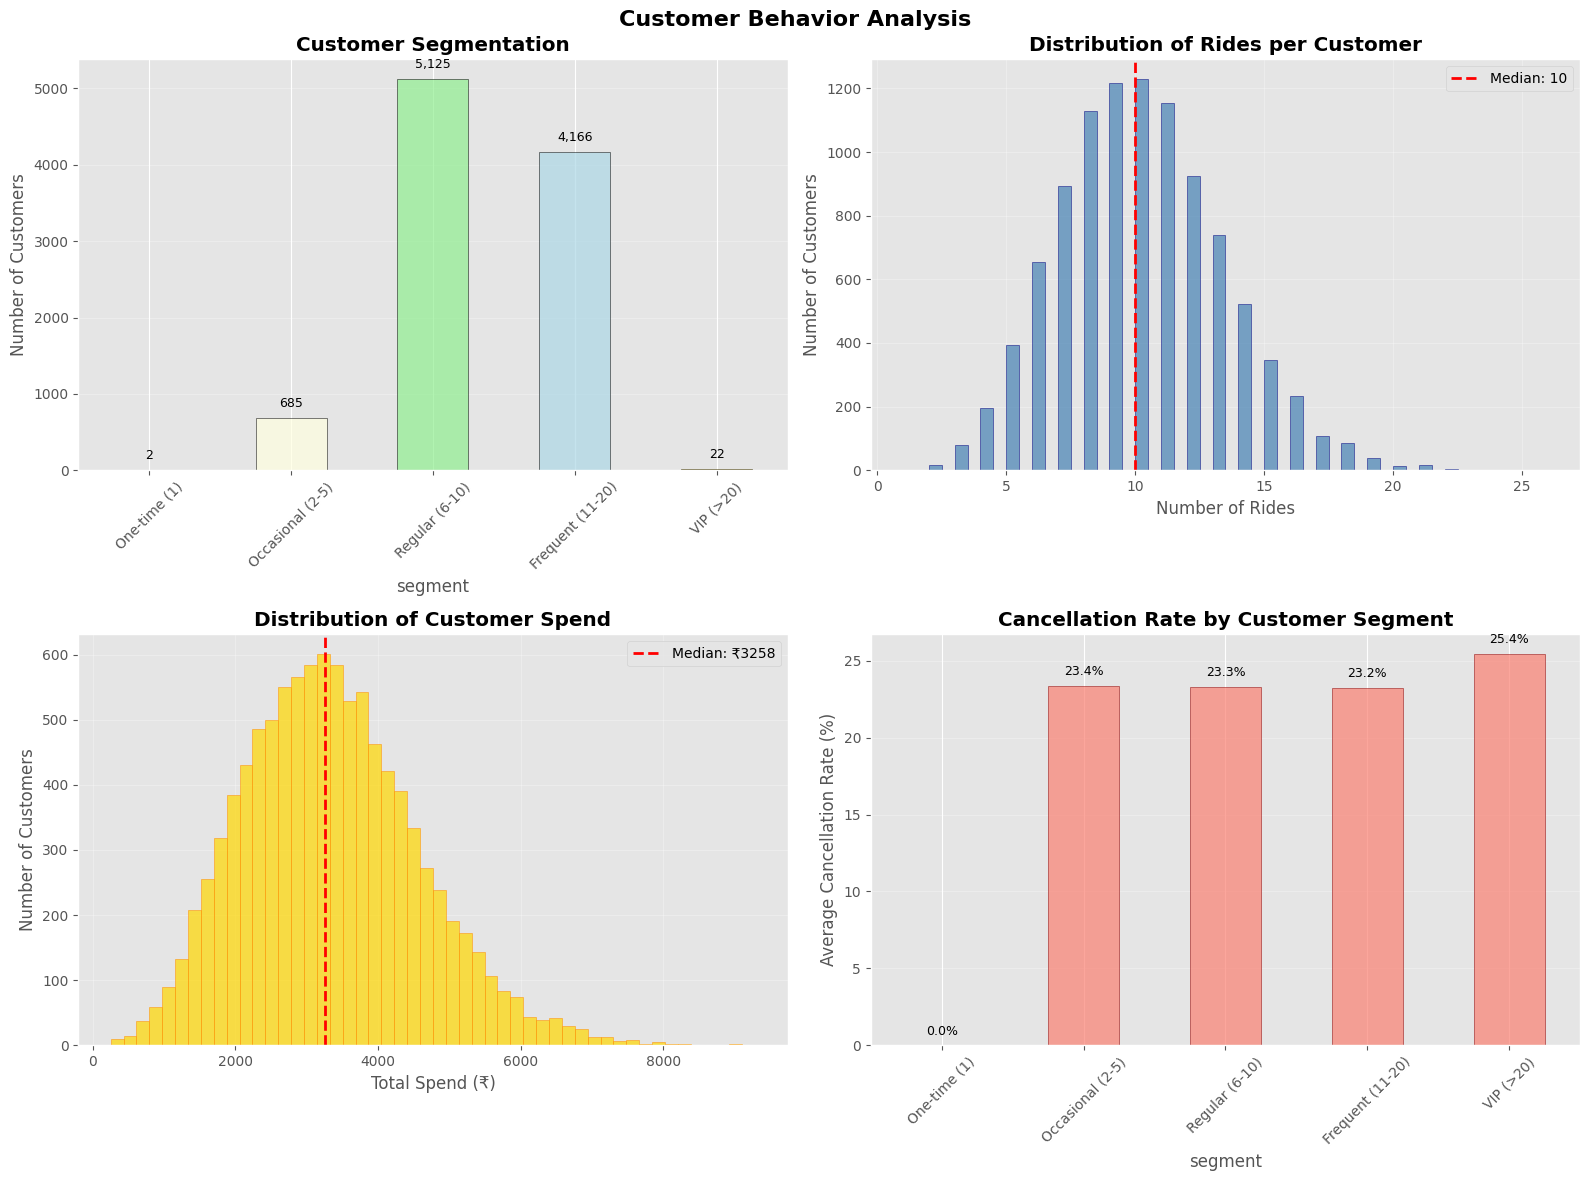


💾 Saved: customer_behavior.png

💡 CUSTOMER INSIGHTS:
Customer retention rate: 100.0%
(9,998 out of 10,000 customers made repeat bookings)
   ✅ GOOD retention rate


In [ ]:
"""
Cell 45: Customer Behavior & Segmentation
"""

print("👥 CUSTOMER BEHAVIOR ANALYSIS")
print("="*70)

if 'customer_id' in df_bookings.columns:
    print("\nAnalyzing customer patterns...\n")

    # Aggregate customer metrics
    customer_metrics = df_bookings.groupby('customer_id').agg({
        'booking_id': 'count',  # Total rides
    }).rename(columns={'booking_id': 'total_rides'})

    # Add fare info if available
    if fare_col:
        customer_spend = df_bookings.groupby('customer_id')[fare_col].sum()
        customer_metrics['total_spend'] = customer_spend
        customer_metrics['avg_fare'] = (
            customer_metrics['total_spend'] / customer_metrics['total_rides']
        ).round(2)

    # Add cancellation info if available
    if status_col:
        customer_cancellations = df_bookings[
            df_bookings[status_col].str.lower().str.contains('cancel', na=False)
        ].groupby('customer_id').size()

        customer_metrics['cancellations'] = customer_cancellations
        customer_metrics['cancellations'] = customer_metrics['cancellations'].fillna(0)
        customer_metrics['cancellation_rate'] = (
            customer_metrics['cancellations'] / customer_metrics['total_rides'] * 100
        ).round(2)

    print("📊 CUSTOMER STATISTICS:")
    print("="*70)
    print(f"Total unique customers: {len(customer_metrics):,}")
    print(f"Average rides per customer: {customer_metrics['total_rides'].mean():.2f}")
    print(f"Median rides per customer: {customer_metrics['total_rides'].median():.0f}")
    print(f"Max rides by single customer: {customer_metrics['total_rides'].max():,}")

    if fare_col:
        print(f"\nAverage spend per customer: ₹{customer_metrics['total_spend'].mean():.2f}")
        print(f"Median spend per customer: ₹{customer_metrics['total_spend'].median():.2f}")
        print(f"Total revenue: ₹{customer_metrics['total_spend'].sum():,.2f}")

    if 'cancellation_rate' in customer_metrics.columns:
        print(f"\nAverage customer cancellation rate: {customer_metrics['cancellation_rate'].mean():.2f}%")

    # Customer segmentation based on ride frequency
    customer_metrics['segment'] = pd.cut(
        customer_metrics['total_rides'],
        bins=[0, 1, 5, 10, 20, float('inf')],
        labels=['One-time (1)', 'Occasional (2-5)', 'Regular (6-10)',
                'Frequent (11-20)', 'VIP (>20)']
    )

    segment_counts = customer_metrics['segment'].value_counts().sort_index()

    print("\n" + "="*70)
    print("📊 CUSTOMER SEGMENTATION (by ride frequency):")
    print("="*70)
    for segment, count in segment_counts.items():
        pct = (count / len(customer_metrics)) * 100
        rides = customer_metrics[customer_metrics['segment'] == segment]['total_rides'].sum()
        rides_pct = (rides / customer_metrics['total_rides'].sum()) * 100
        print(f"   {segment:20s}: {count:6,} customers ({pct:5.2f}%) | {rides:7,} rides ({rides_pct:5.2f}%)")

    # Identify VIP customers (top 10%)
    vip_threshold = customer_metrics['total_rides'].quantile(0.90)
    vip_customers = customer_metrics[customer_metrics['total_rides'] >= vip_threshold]

    print("\n" + "="*70)
    print(f"👑 VIP CUSTOMERS (Top 10% - {len(vip_customers):,} customers):")
    print("="*70)
    print(f"Criteria: ≥ {vip_threshold:.0f} rides")
    print(f"VIP contribution: {(vip_customers['total_rides'].sum()/customer_metrics['total_rides'].sum()*100):.1f}% of total rides")

    if fare_col:
        vip_revenue = vip_customers['total_spend'].sum()
        total_revenue = customer_metrics['total_spend'].sum()
        print(f"VIP revenue: ₹{vip_revenue:,.2f} ({(vip_revenue/total_revenue*100):.1f}% of total revenue)")

    # One-time customers analysis
    one_time_customers = customer_metrics[customer_metrics['total_rides'] == 1]

    print("\n" + "="*70)
    print(f"🔄 ONE-TIME CUSTOMERS ({len(one_time_customers):,} customers):")
    print("="*70)
    print(f"Percentage: {(len(one_time_customers)/len(customer_metrics)*100):.1f}%")
    print(f"⚠️ Opportunity: Convert one-time to repeat customers")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Customer Behavior Analysis', fontsize=16, fontweight='bold')

    # Segment distribution
    segment_counts.plot(kind='bar', ax=axes[0, 0],
                       color=['lightcoral', 'lightyellow', 'lightgreen', 'lightblue', 'gold'],
                       edgecolor='black', alpha=0.7)
    axes[0, 0].set_ylabel('Number of Customers')
    axes[0, 0].set_title('Customer Segmentation', fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(segment_counts.values):
        axes[0, 0].text(i, v + (segment_counts.max() * 0.02), f'{v:,}',
                       ha='center', va='bottom', fontsize=9)

    # Rides distribution
    customer_metrics['total_rides'].hist(bins=50, ax=axes[0, 1],
                                         color='steelblue', edgecolor='navy', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Rides')
    axes[0, 1].set_ylabel('Number of Customers')
    axes[0, 1].set_title('Distribution of Rides per Customer', fontweight='bold')
    axes[0, 1].axvline(x=customer_metrics['total_rides'].median(), color='red',
                      linestyle='--', linewidth=2, label=f"Median: {customer_metrics['total_rides'].median():.0f}")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Spend distribution (if available)
    if fare_col:
        customer_metrics['total_spend'].hist(bins=50, ax=axes[1, 0],
                                            color='gold', edgecolor='darkorange', alpha=0.7)
        axes[1, 0].set_xlabel('Total Spend (₹)')
        axes[1, 0].set_ylabel('Number of Customers')
        axes[1, 0].set_title('Distribution of Customer Spend', fontweight='bold')
        axes[1, 0].axvline(x=customer_metrics['total_spend'].median(), color='red',
                          linestyle='--', linewidth=2,
                          label=f"Median: ₹{customer_metrics['total_spend'].median():.0f}")
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].axis('off')

    # Cancellation rate by segment (if available)
    if 'cancellation_rate' in customer_metrics.columns:
        cancellation_by_segment = customer_metrics.groupby('segment')['cancellation_rate'].mean()
        cancellation_by_segment.plot(kind='bar', ax=axes[1, 1],
                                     color='salmon', edgecolor='darkred', alpha=0.7)
        axes[1, 1].set_ylabel('Average Cancellation Rate (%)')
        axes[1, 1].set_title('Cancellation Rate by Customer Segment', fontweight='bold')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(axis='y', alpha=0.3)

        # Add value labels
        for i, v in enumerate(cancellation_by_segment.values):
            axes[1, 1].text(i, v + 0.5, f'{v:.1f}%',
                           ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'customer_behavior.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: customer_behavior.png")

    # Customer insights
    print("\n" + "="*70)
    print("💡 CUSTOMER INSIGHTS:")
    print("="*70)

    # Retention rate (customers with >1 ride)
    repeat_customers = len(customer_metrics[customer_metrics['total_rides'] > 1])
    retention_rate = (repeat_customers / len(customer_metrics)) * 100

    print(f"Customer retention rate: {retention_rate:.1f}%")
    print(f"({repeat_customers:,} out of {len(customer_metrics):,} customers made repeat bookings)")

    if retention_rate < 50:
        print("   ⚠️ LOW retention - focus on converting one-time users")
    elif retention_rate < 70:
        print("   ⚠️ MODERATE retention - room for improvement")
    else:
        print("   ✅ GOOD retention rate")

else:
    print("⚠️ Customer ID column not found")


🚕 DRIVER PERFORMANCE ANALYSIS

Analyzing driver patterns...

📊 DRIVER STATISTICS:
Total unique drivers: 5,000
Average rides per driver: 20.00
Median rides per driver: 20
Max rides by single driver: 38

Average completion rate: 76.72%
Average cancellation rate: 23.28%

Average revenue per driver: ₹6675.60
Total revenue: ₹33,377,980.83

📊 DRIVER SEGMENTATION (by activity):
   New (<10)                :    49 drivers ( 0.98%) |     448 rides ( 0.45%)
   Beginner (10-50)         : 4,951 drivers (99.02%) |  99,552 rides (99.55%)
   Intermediate (50-100)    :     0 drivers ( 0.00%) |       0 rides ( 0.00%)
   Active (100-200)         :     0 drivers ( 0.00%) |       0 rides ( 0.00%)
   Super Active (>200)      :     0 drivers ( 0.00%) |       0 rides ( 0.00%)

⭐ TOP PERFORMING DRIVERS (19 drivers):
Criteria: Top 25% by rides AND ≥95% completion rate
Top drivers handle: 0.5% of all rides
Top drivers generate: ₹152,686.72 (0.5% of revenue)

⚠️ PROBLEM DRIVERS (2,988 drivers):
Criteria: >20% ca

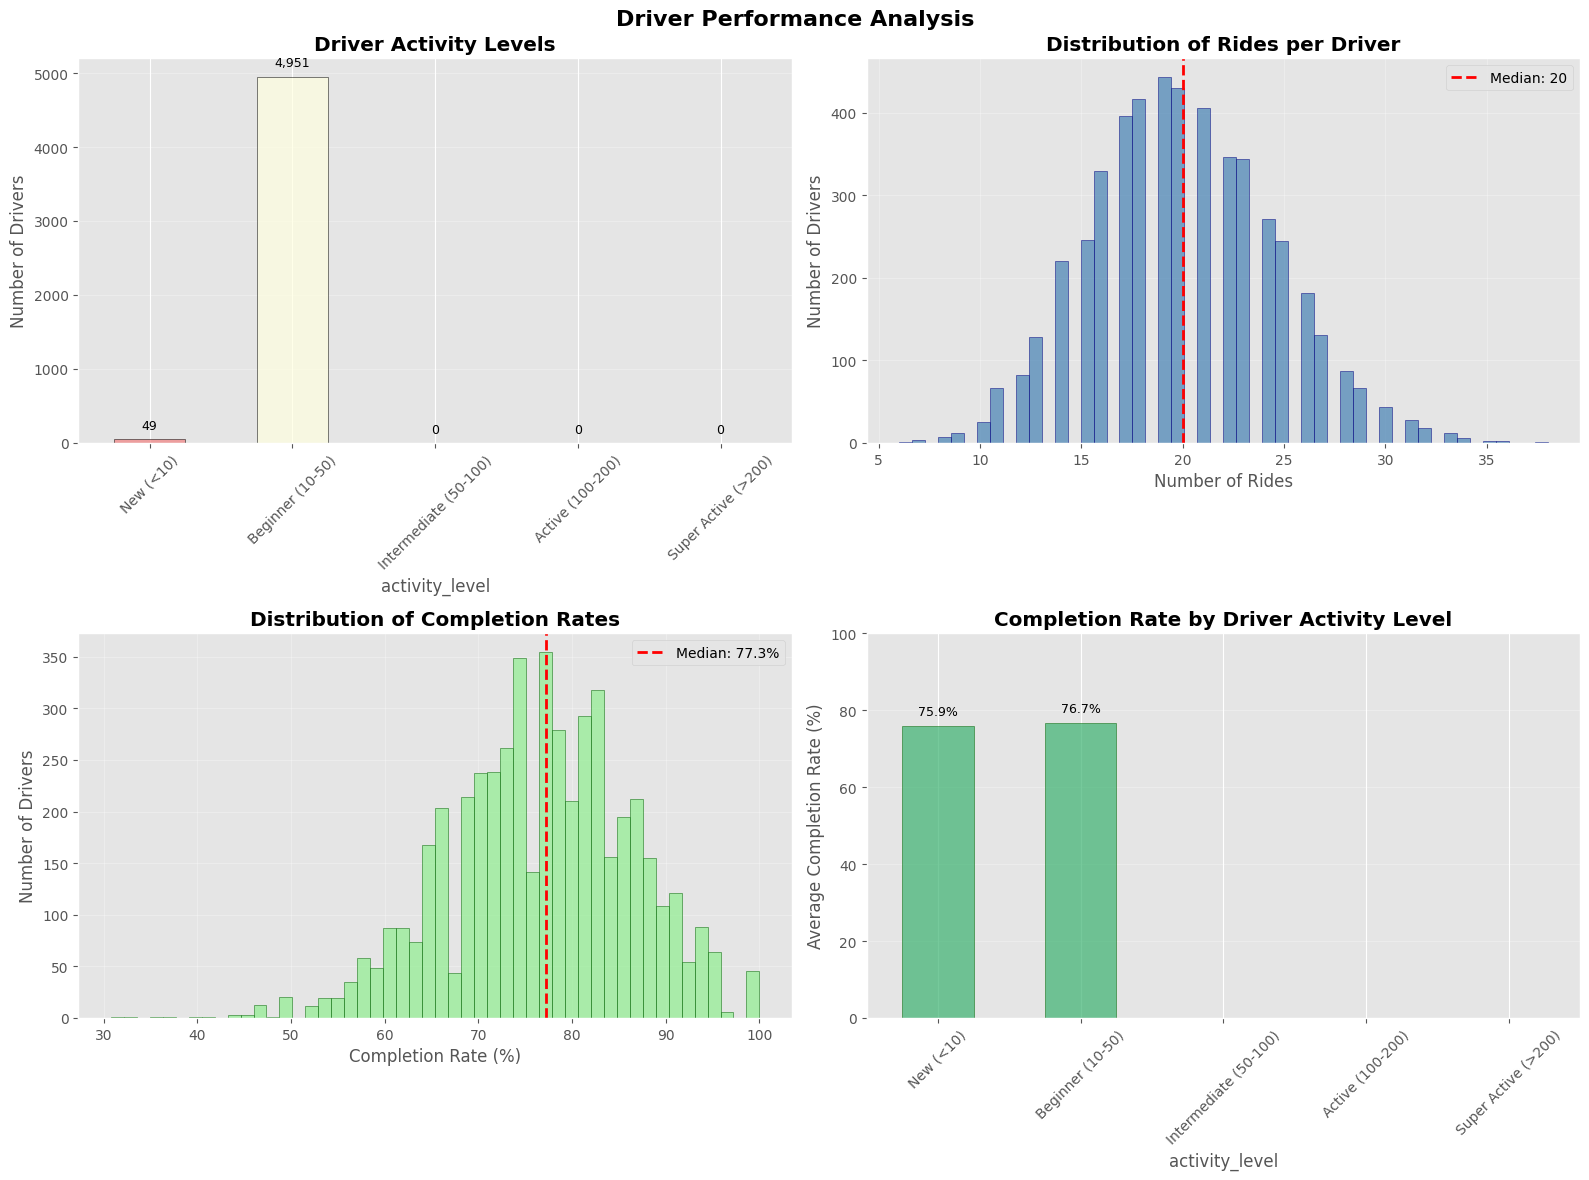


💾 Saved: driver_performance.png

💡 DRIVER UTILIZATION INSIGHTS:
Top 20% of drivers handle: 26.5% of rides

New drivers (<10 rides): 24 (0.5%)
Experienced drivers (≥100 rides): 0 (0.0%)


In [ ]:
"""
Cell 46: Driver Performance & Reliability
"""

print("🚕 DRIVER PERFORMANCE ANALYSIS")
print("="*70)

if 'driver_id' in df_bookings.columns:
    print("\nAnalyzing driver patterns...\n")

    # Aggregate driver metrics
    driver_metrics = df_bookings.groupby('driver_id').agg({
        'booking_id': 'count',  # Total rides
    }).rename(columns={'booking_id': 'total_rides'})

    # Add completion/cancellation info
    if status_col:
        # Completed rides
        completed_rides = df_bookings[
            df_bookings[status_col].str.lower().str.contains('complet', na=False)
        ].groupby('driver_id').size()

        # Cancelled rides
        cancelled_rides = df_bookings[
            df_bookings[status_col].str.lower().str.contains('cancel', na=False)
        ].groupby('driver_id').size()

        driver_metrics['completed_rides'] = completed_rides.reindex(driver_metrics.index, fill_value=0)
        driver_metrics['cancelled_rides'] = cancelled_rides.reindex(driver_metrics.index, fill_value=0)

        driver_metrics['completion_rate'] = (
            driver_metrics['completed_rides'] / driver_metrics['total_rides'] * 100
        ).round(2)

        driver_metrics['cancellation_rate'] = (
            driver_metrics['cancelled_rides'] / driver_metrics['total_rides'] * 100
        ).round(2)

    # Add revenue info
    if fare_col:
        driver_revenue = df_bookings.groupby('driver_id')[fare_col].sum()
        driver_metrics['total_revenue'] = driver_revenue
        driver_metrics['avg_fare'] = (
            driver_metrics['total_revenue'] / driver_metrics['total_rides']
        ).round(2)

    print("📊 DRIVER STATISTICS:")
    print("="*70)
    print(f"Total unique drivers: {len(driver_metrics):,}")
    print(f"Average rides per driver: {driver_metrics['total_rides'].mean():.2f}")
    print(f"Median rides per driver: {driver_metrics['total_rides'].median():.0f}")
    print(f"Max rides by single driver: {driver_metrics['total_rides'].max():,}")

    if 'completion_rate' in driver_metrics.columns:
        print(f"\nAverage completion rate: {driver_metrics['completion_rate'].mean():.2f}%")
        print(f"Average cancellation rate: {driver_metrics['cancellation_rate'].mean():.2f}%")

    if fare_col:
        print(f"\nAverage revenue per driver: ₹{driver_metrics['total_revenue'].mean():.2f}")
        print(f"Total revenue: ₹{driver_metrics['total_revenue'].sum():,.2f}")

    # Driver segmentation by activity
    driver_metrics['activity_level'] = pd.cut(
        driver_metrics['total_rides'],
        bins=[0, 10, 50, 100, 200, float('inf')],
        labels=['New (<10)', 'Beginner (10-50)', 'Intermediate (50-100)',
                'Active (100-200)', 'Super Active (>200)']
    )

    activity_counts = driver_metrics['activity_level'].value_counts().sort_index()

    print("\n" + "="*70)
    print("📊 DRIVER SEGMENTATION (by activity):")
    print("="*70)
    for level, count in activity_counts.items():
        pct = (count / len(driver_metrics)) * 100
        rides = driver_metrics[driver_metrics['activity_level'] == level]['total_rides'].sum()
        rides_pct = (rides / driver_metrics['total_rides'].sum()) * 100
        print(f"   {level:25s}: {count:5,} drivers ({pct:5.2f}%) | {rides:7,} rides ({rides_pct:5.2f}%)")

    # Identify top performers
    if 'completion_rate' in driver_metrics.columns:
        # Top drivers = high rides + high completion rate
        top_drivers = driver_metrics[
            (driver_metrics['total_rides'] >= driver_metrics['total_rides'].quantile(0.75)) &
            (driver_metrics['completion_rate'] >= 95)
        ]

        print("\n" + "="*70)
        print(f"⭐ TOP PERFORMING DRIVERS ({len(top_drivers):,} drivers):")
        print("="*70)
        print(f"Criteria: Top 25% by rides AND ≥95% completion rate")

        if len(top_drivers) > 0:
            top_rides = top_drivers['total_rides'].sum()
            total_rides = driver_metrics['total_rides'].sum()
            print(f"Top drivers handle: {(top_rides/total_rides*100):.1f}% of all rides")

            if fare_col:
                top_revenue = top_drivers['total_revenue'].sum()
                total_revenue = driver_metrics['total_revenue'].sum()
                print(f"Top drivers generate: ₹{top_revenue:,.2f} ({(top_revenue/total_revenue*100):.1f}% of revenue)")

        # Problem drivers
        problem_drivers = driver_metrics[driver_metrics['cancellation_rate'] > 20]

        print("\n" + "="*70)
        print(f"⚠️ PROBLEM DRIVERS ({len(problem_drivers):,} drivers):")
        print("="*70)
        print(f"Criteria: >20% cancellation rate")

        if len(problem_drivers) > 0:
            problem_cancellations = problem_drivers['cancelled_rides'].sum()
            total_cancellations = driver_metrics['cancelled_rides'].sum()
            print(f"Impact: {(problem_cancellations/total_cancellations*100):.1f}% of all driver cancellations")
            print(f"⚠️ Recommendation: Provide training or incentives to improve performance")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Driver Performance Analysis', fontsize=16, fontweight='bold')

    # Activity level distribution
    activity_counts.plot(kind='bar', ax=axes[0, 0],
                        color=['lightcoral', 'lightyellow', 'lightgreen', 'lightblue', 'gold'],
                        edgecolor='black', alpha=0.7)
    axes[0, 0].set_ylabel('Number of Drivers')
    axes[0, 0].set_title('Driver Activity Levels', fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(activity_counts.values):
        axes[0, 0].text(i, v + (activity_counts.max() * 0.02), f'{v:,}',
                       ha='center', va='bottom', fontsize=9)

    # Rides distribution
    driver_metrics['total_rides'].hist(bins=50, ax=axes[0, 1],
                                       color='steelblue', edgecolor='navy', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Rides')
    axes[0, 1].set_ylabel('Number of Drivers')
    axes[0, 1].set_title('Distribution of Rides per Driver', fontweight='bold')
    axes[0, 1].axvline(x=driver_metrics['total_rides'].median(), color='red',
                      linestyle='--', linewidth=2,
                      label=f"Median: {driver_metrics['total_rides'].median():.0f}")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Completion rate distribution
    if 'completion_rate' in driver_metrics.columns:
        driver_metrics['completion_rate'].hist(bins=50, ax=axes[1, 0],
                                               color='lightgreen', edgecolor='darkgreen', alpha=0.7)
        axes[1, 0].set_xlabel('Completion Rate (%)')
        axes[1, 0].set_ylabel('Number of Drivers')
        axes[1, 0].set_title('Distribution of Completion Rates', fontweight='bold')
        axes[1, 0].axvline(x=driver_metrics['completion_rate'].median(), color='red',
                          linestyle='--', linewidth=2,
                          label=f"Median: {driver_metrics['completion_rate'].median():.1f}%")
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].axis('off')

    # Completion rate by activity level
    if 'completion_rate' in driver_metrics.columns:
        completion_by_activity = driver_metrics.groupby('activity_level')['completion_rate'].mean()
        completion_by_activity.plot(kind='bar', ax=axes[1, 1],
                                    color='mediumseagreen', edgecolor='darkgreen', alpha=0.7)
        axes[1, 1].set_ylabel('Average Completion Rate (%)')
        axes[1, 1].set_title('Completion Rate by Driver Activity Level', fontweight='bold')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(axis='y', alpha=0.3)
        axes[1, 1].set_ylim([0, 100])

        # Add value labels
        for i, v in enumerate(completion_by_activity.values):
            axes[1, 1].text(i, v + 2, f'{v:.1f}%',
                           ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'driver_performance.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: driver_performance.png")

    # Driver utilization insights
    print("\n" + "="*70)
    print("💡 DRIVER UTILIZATION INSIGHTS:")
    print("="*70)

    # Calculate driver concentration
    top_20_pct_drivers = int(len(driver_metrics) * 0.20)
    top_drivers_rides = driver_metrics.nlargest(top_20_pct_drivers, 'total_rides')['total_rides'].sum()
    total_rides = driver_metrics['total_rides'].sum()

    print(f"Top 20% of drivers handle: {(top_drivers_rides/total_rides*100):.1f}% of rides")

    # New vs experienced drivers
    new_drivers = len(driver_metrics[driver_metrics['total_rides'] < 10])
    experienced_drivers = len(driver_metrics[driver_metrics['total_rides'] >= 100])

    print(f"\nNew drivers (<10 rides): {new_drivers:,} ({(new_drivers/len(driver_metrics)*100):.1f}%)")
    print(f"Experienced drivers (≥100 rides): {experienced_drivers:,} ({(experienced_drivers/len(driver_metrics)*100):.1f}%)")

else:
    print("⚠️ Driver ID column not found")

🚕 DRIVER PERFORMANCE ANALYSIS

Analyzing driver patterns...

📊 DRIVER STATISTICS:
Total unique drivers: 5,000
Average rides per driver: 20.00
Median rides per driver: 20
Max rides by single driver: 38

Average completion rate: 76.72%
Average cancellation rate: 23.28%

Average revenue per driver: ₹6675.60
Total revenue: ₹33,377,980.83

📊 DRIVER SEGMENTATION (by activity):
   New (<10)                :    49 drivers ( 0.98%) |     448 rides ( 0.45%)
   Beginner (10-50)         : 4,951 drivers (99.02%) |  99,552 rides (99.55%)
   Intermediate (50-100)    :     0 drivers ( 0.00%) |       0 rides ( 0.00%)
   Active (100-200)         :     0 drivers ( 0.00%) |       0 rides ( 0.00%)
   Super Active (>200)      :     0 drivers ( 0.00%) |       0 rides ( 0.00%)

⭐ TOP PERFORMING DRIVERS (19 drivers):
Criteria: Top 25% by rides AND ≥95% completion rate
Top drivers handle: 0.5% of all rides
Top drivers generate: ₹152,686.72 (0.5% of revenue)

⚠️ PROBLEM DRIVERS (2,988 drivers):
Criteria: >20% ca

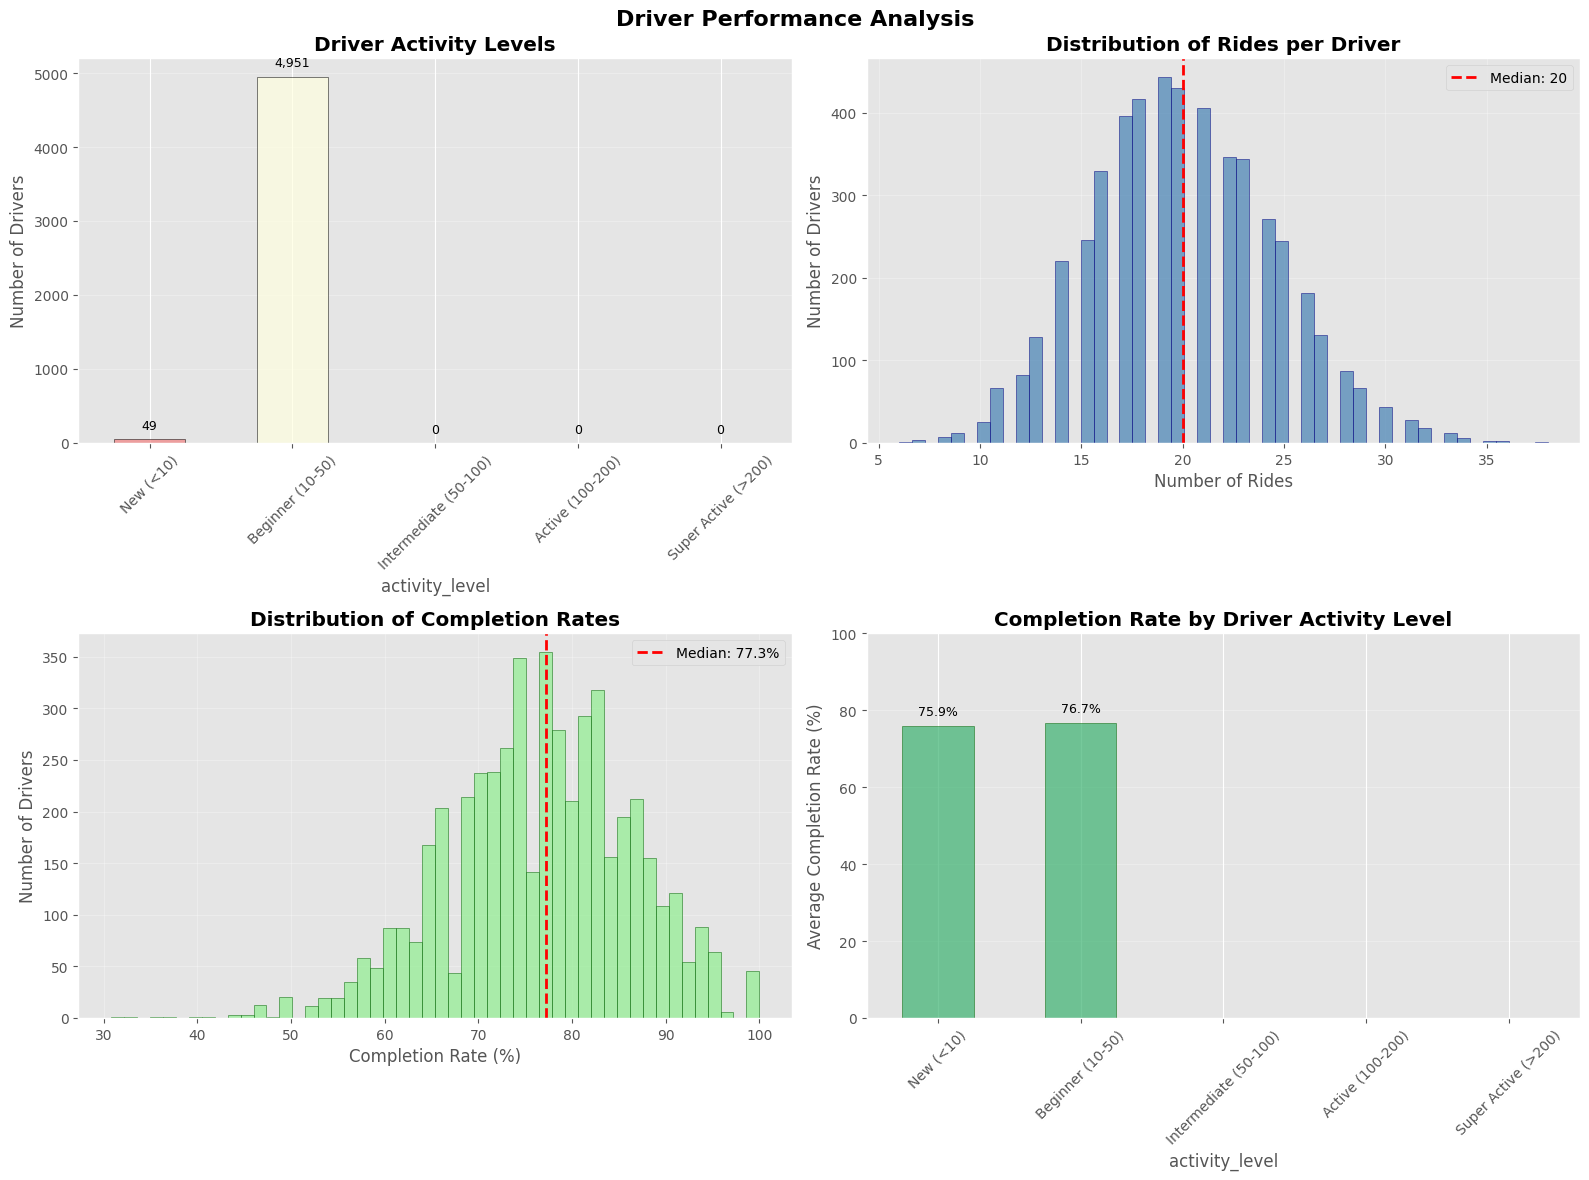


💾 Saved: driver_performance.png

💡 DRIVER UTILIZATION INSIGHTS:
Top 20% of drivers handle: 26.5% of rides

New drivers (<10 rides): 24 (0.5%)
Experienced drivers (≥100 rides): 0 (0.0%)


In [ ]:
"""
Cell 46: Driver Performance & Reliability
"""

print("🚕 DRIVER PERFORMANCE ANALYSIS")
print("="*70)

if 'driver_id' in df_bookings.columns:
    print("\nAnalyzing driver patterns...\n")

    # Aggregate driver metrics
    driver_metrics = df_bookings.groupby('driver_id').agg({
        'booking_id': 'count',  # Total rides
    }).rename(columns={'booking_id': 'total_rides'})

    # Add completion/cancellation info
    if status_col:
        # Completed rides
        completed_rides = df_bookings[
            df_bookings[status_col].str.lower().str.contains('complet', na=False)
        ].groupby('driver_id').size()

        # Cancelled rides
        cancelled_rides = df_bookings[
            df_bookings[status_col].str.lower().str.contains('cancel', na=False)
        ].groupby('driver_id').size()

        driver_metrics['completed_rides'] = completed_rides.reindex(driver_metrics.index, fill_value=0)
        driver_metrics['cancelled_rides'] = cancelled_rides.reindex(driver_metrics.index, fill_value=0)

        driver_metrics['completion_rate'] = (
            driver_metrics['completed_rides'] / driver_metrics['total_rides'] * 100
        ).round(2)

        driver_metrics['cancellation_rate'] = (
            driver_metrics['cancelled_rides'] / driver_metrics['total_rides'] * 100
        ).round(2)

    # Add revenue info
    if fare_col:
        driver_revenue = df_bookings.groupby('driver_id')[fare_col].sum()
        driver_metrics['total_revenue'] = driver_revenue
        driver_metrics['avg_fare'] = (
            driver_metrics['total_revenue'] / driver_metrics['total_rides']
        ).round(2)

    print("📊 DRIVER STATISTICS:")
    print("="*70)
    print(f"Total unique drivers: {len(driver_metrics):,}")
    print(f"Average rides per driver: {driver_metrics['total_rides'].mean():.2f}")
    print(f"Median rides per driver: {driver_metrics['total_rides'].median():.0f}")
    print(f"Max rides by single driver: {driver_metrics['total_rides'].max():,}")

    if 'completion_rate' in driver_metrics.columns:
        print(f"\nAverage completion rate: {driver_metrics['completion_rate'].mean():.2f}%")
        print(f"Average cancellation rate: {driver_metrics['cancellation_rate'].mean():.2f}%")

    if fare_col:
        print(f"\nAverage revenue per driver: ₹{driver_metrics['total_revenue'].mean():.2f}")
        print(f"Total revenue: ₹{driver_metrics['total_revenue'].sum():,.2f}")

    # Driver segmentation by activity
    driver_metrics['activity_level'] = pd.cut(
        driver_metrics['total_rides'],
        bins=[0, 10, 50, 100, 200, float('inf')],
        labels=['New (<10)', 'Beginner (10-50)', 'Intermediate (50-100)',
                'Active (100-200)', 'Super Active (>200)']
    )

    activity_counts = driver_metrics['activity_level'].value_counts().sort_index()

    print("\n" + "="*70)
    print("📊 DRIVER SEGMENTATION (by activity):")
    print("="*70)
    for level, count in activity_counts.items():
        pct = (count / len(driver_metrics)) * 100
        rides = driver_metrics[driver_metrics['activity_level'] == level]['total_rides'].sum()
        rides_pct = (rides / driver_metrics['total_rides'].sum()) * 100
        print(f"   {level:25s}: {count:5,} drivers ({pct:5.2f}%) | {rides:7,} rides ({rides_pct:5.2f}%)")

    # Identify top performers
    if 'completion_rate' in driver_metrics.columns:
        # Top drivers = high rides + high completion rate
        top_drivers = driver_metrics[
            (driver_metrics['total_rides'] >= driver_metrics['total_rides'].quantile(0.75)) &
            (driver_metrics['completion_rate'] >= 95)
        ]

        print("\n" + "="*70)
        print(f"⭐ TOP PERFORMING DRIVERS ({len(top_drivers):,} drivers):")
        print("="*70)
        print(f"Criteria: Top 25% by rides AND ≥95% completion rate")

        if len(top_drivers) > 0:
            top_rides = top_drivers['total_rides'].sum()
            total_rides = driver_metrics['total_rides'].sum()
            print(f"Top drivers handle: {(top_rides/total_rides*100):.1f}% of all rides")

            if fare_col:
                top_revenue = top_drivers['total_revenue'].sum()
                total_revenue = driver_metrics['total_revenue'].sum()
                print(f"Top drivers generate: ₹{top_revenue:,.2f} ({(top_revenue/total_revenue*100):.1f}% of revenue)")

        # Problem drivers
        problem_drivers = driver_metrics[driver_metrics['cancellation_rate'] > 20]

        print("\n" + "="*70)
        print(f"⚠️ PROBLEM DRIVERS ({len(problem_drivers):,} drivers):")
        print("="*70)
        print(f"Criteria: >20% cancellation rate")

        if len(problem_drivers) > 0:
            problem_cancellations = problem_drivers['cancelled_rides'].sum()
            total_cancellations = driver_metrics['cancelled_rides'].sum()
            print(f"Impact: {(problem_cancellations/total_cancellations*100):.1f}% of all driver cancellations")
            print(f"⚠️ Recommendation: Provide training or incentives to improve performance")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Driver Performance Analysis', fontsize=16, fontweight='bold')

    # Activity level distribution
    activity_counts.plot(kind='bar', ax=axes[0, 0],
                        color=['lightcoral', 'lightyellow', 'lightgreen', 'lightblue', 'gold'],
                        edgecolor='black', alpha=0.7)
    axes[0, 0].set_ylabel('Number of Drivers')
    axes[0, 0].set_title('Driver Activity Levels', fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(activity_counts.values):
        axes[0, 0].text(i, v + (activity_counts.max() * 0.02), f'{v:,}',
                       ha='center', va='bottom', fontsize=9)

    # Rides distribution
    driver_metrics['total_rides'].hist(bins=50, ax=axes[0, 1],
                                       color='steelblue', edgecolor='navy', alpha=0.7)
    axes[0, 1].set_xlabel('Number of Rides')
    axes[0, 1].set_ylabel('Number of Drivers')
    axes[0, 1].set_title('Distribution of Rides per Driver', fontweight='bold')
    axes[0, 1].axvline(x=driver_metrics['total_rides'].median(), color='red',
                      linestyle='--', linewidth=2,
                      label=f"Median: {driver_metrics['total_rides'].median():.0f}")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Completion rate distribution
    if 'completion_rate' in driver_metrics.columns:
        driver_metrics['completion_rate'].hist(bins=50, ax=axes[1, 0],
                                               color='lightgreen', edgecolor='darkgreen', alpha=0.7)
        axes[1, 0].set_xlabel('Completion Rate (%)')
        axes[1, 0].set_ylabel('Number of Drivers')
        axes[1, 0].set_title('Distribution of Completion Rates', fontweight='bold')
        axes[1, 0].axvline(x=driver_metrics['completion_rate'].median(), color='red',
                          linestyle='--', linewidth=2,
                          label=f"Median: {driver_metrics['completion_rate'].median():.1f}%")
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].axis('off')

    # Completion rate by activity level
    if 'completion_rate' in driver_metrics.columns:
        completion_by_activity = driver_metrics.groupby('activity_level')['completion_rate'].mean()
        completion_by_activity.plot(kind='bar', ax=axes[1, 1],
                                    color='mediumseagreen', edgecolor='darkgreen', alpha=0.7)
        axes[1, 1].set_ylabel('Average Completion Rate (%)')
        axes[1, 1].set_title('Completion Rate by Driver Activity Level', fontweight='bold')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(axis='y', alpha=0.3)
        axes[1, 1].set_ylim([0, 100])

        # Add value labels
        for i, v in enumerate(completion_by_activity.values):
            axes[1, 1].text(i, v + 2, f'{v:.1f}%',
                           ha='center', va='bottom', fontsize=9)
    else:
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'driver_performance.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: driver_performance.png")

    # Driver utilization insights
    print("\n" + "="*70)
    print("💡 DRIVER UTILIZATION INSIGHTS:")
    print("="*70)

    # Calculate driver concentration
    top_20_pct_drivers = int(len(driver_metrics) * 0.20)
    top_drivers_rides = driver_metrics.nlargest(top_20_pct_drivers, 'total_rides')['total_rides'].sum()
    total_rides = driver_metrics['total_rides'].sum()

    print(f"Top 20% of drivers handle: {(top_drivers_rides/total_rides*100):.1f}% of rides")

    # New vs experienced drivers
    new_drivers = len(driver_metrics[driver_metrics['total_rides'] < 10])
    experienced_drivers = len(driver_metrics[driver_metrics['total_rides'] >= 100])

    print(f"\nNew drivers (<10 rides): {new_drivers:,} ({(new_drivers/len(driver_metrics)*100):.1f}%)")
    print(f"Experienced drivers (≥100 rides): {experienced_drivers:,} ({(experienced_drivers/len(driver_metrics)*100):.1f}%)")

else:
    print("⚠️ Driver ID column not found")

🔗 CORRELATION ANALYSIS

Analyzing correlations between 10 numerical features:

   - day_of_week
   - is_weekend
   - hour_of_day
   - base_fare
   - surge_multiplier
   - booking_value
   - hour
   - month
   - fare_per_km
   - time_delay_min

🔝 STRONG CORRELATIONS (|r| > 0.5):


,Feature 1,Feature 2,Correlation
1,base_fare,booking_value,0.93
0,day_of_week,is_weekend,0.79



🎯 TOP 10 CORRELATIONS WITH BOOKING STATUS:
   surge_multiplier                   : -0.1725 (weak negative)
   booking_value                      : -0.0528 (weak negative)
   time_delay_min                     :  0.0522 (weak positive)
   hour_of_day                        : -0.0125 (weak negative)
   base_fare                          :  0.0040 (weak positive)
   fare_per_km                        : -0.0030 (weak negative)
   month                              :  0.0023 (weak positive)
   day_of_week                        :  0.0011 (weak positive)
   is_weekend                         : -0.0008 (weak negative)
   hour                               :     nan (weak negative)


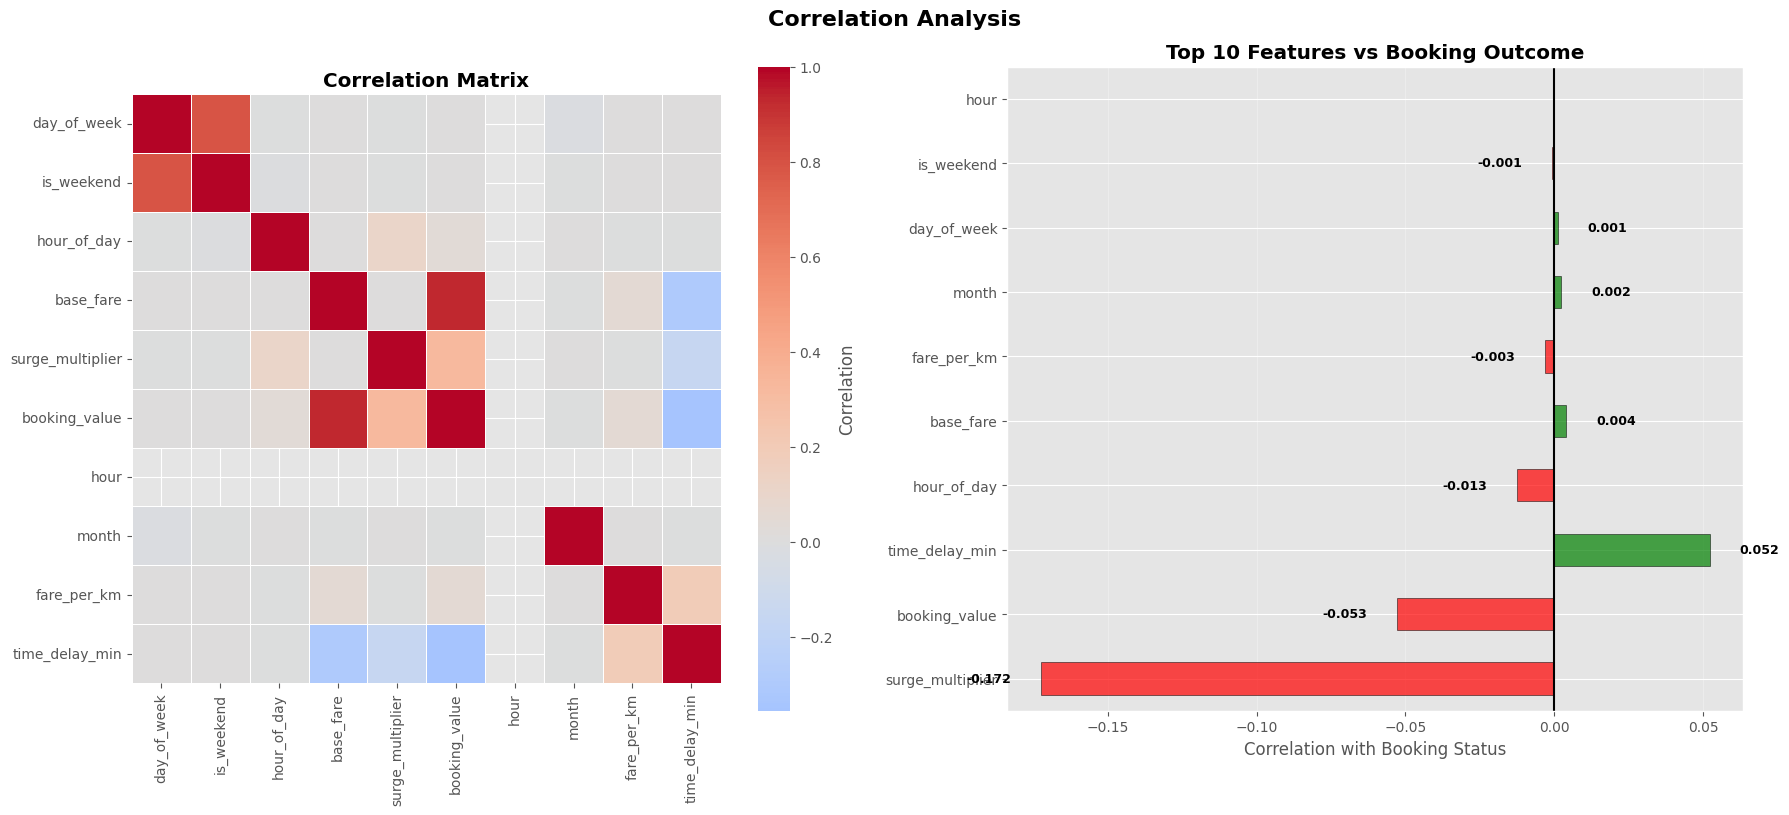


💾 Saved: correlation_analysis.png

⚠️ MULTICOLLINEARITY WARNING (|r| > 0.9):
These feature pairs are highly correlated - consider removing one for modeling:
   • base_fare ↔ booking_value: 0.9287


In [ ]:
"""
Cell 47: Correlation Analysis - Identify Relationships
"""

print("🔗 CORRELATION ANALYSIS")
print("="*70)

# Select numerical columns for correlation
numerical_cols = df_bookings.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numerical_cols = [col for col in numerical_cols
                  if not any(id_word in col.lower() for id_word in ['id', '_id'])]

# Also remove any encoded columns we created temporarily
numerical_cols = [col for col in numerical_cols if 'encoded' not in col.lower()]

print(f"\nAnalyzing correlations between {len(numerical_cols)} numerical features:\n")
for col in numerical_cols[:15]:  # Show first 15
    print(f"   - {col}")
if len(numerical_cols) > 15:
    print(f"   ... and {len(numerical_cols) - 15} more")

if len(numerical_cols) >= 2:
    # Calculate correlation matrix
    correlation_matrix = df_bookings[numerical_cols].corr()

    # Find strong correlations (excluding diagonal)
    strong_correlations = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.5:  # Strong correlation threshold
                strong_correlations.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': corr_value
                })

    if strong_correlations:
        strong_corr_df = pd.DataFrame(strong_correlations).sort_values(
            'Correlation', key=abs, ascending=False
        )

        print("\n" + "="*70)
        print("🔝 STRONG CORRELATIONS (|r| > 0.5):")
        print("="*70)
        display(strong_corr_df.head(15))
    else:
        print("\n✅ No strong correlations found (|r| > 0.5)")

    # Correlation with target (booking status)
    if status_col:
        # Create numerical encoding of status
        status_mapping = {status: idx for idx, status in
                         enumerate(df_bookings[status_col].unique())}
        df_bookings['status_encoded_temp'] = df_bookings[status_col].map(status_mapping)

        # Calculate correlations with target
        target_correlations = df_bookings[numerical_cols + ['status_encoded_temp']].corr()['status_encoded_temp'].drop('status_encoded_temp')
        target_correlations = target_correlations.sort_values(key=abs, ascending=False)

        print("\n" + "="*70)
        print("🎯 TOP 10 CORRELATIONS WITH BOOKING STATUS:")
        print("="*70)
        for feature, corr in target_correlations.head(10).items():
            direction = "positive" if corr > 0 else "negative"
            strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
            print(f"   {feature:35s}: {corr:7.4f} ({strength} {direction})")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')

    # Full correlation matrix heatmap (sample if too many features)
    if len(numerical_cols) > 20:
        # Sample top 20 most correlated with each other
        corr_sum = correlation_matrix.abs().sum().sort_values(ascending=False)
        top_features = corr_sum.head(20).index.tolist()
        plot_corr = correlation_matrix.loc[top_features, top_features]
        title_suffix = " (Top 20 Features)"
    else:
        plot_corr = correlation_matrix
        title_suffix = ""

    sns.heatmap(plot_corr, annot=False, cmap='coolwarm', center=0,
                linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Correlation'},
                square=True)
    axes[0].set_title(f'Correlation Matrix{title_suffix}', fontweight='bold')

    # Top correlations with target
    if 'status_encoded_temp' in df_bookings.columns:
        top_features_target = target_correlations.head(10).index.tolist()

        if len(top_features_target) > 0:
            subset_corr = target_correlations.head(10)

            # Color based on positive/negative
            colors = ['green' if x > 0 else 'red' for x in subset_corr.values]

            subset_corr.plot(kind='barh', ax=axes[1], color=colors, alpha=0.7, edgecolor='black')
            axes[1].set_xlabel('Correlation with Booking Status')
            axes[1].set_title('Top 10 Features vs Booking Outcome', fontweight='bold')
            axes[1].grid(axis='x', alpha=0.3)
            axes[1].axvline(x=0, color='black', linewidth=1.5)

            # Add value labels
            for i, v in enumerate(subset_corr.values):
                ha_align = 'left' if v > 0 else 'right'
                x_pos = v + 0.01 if v > 0 else v - 0.01
                axes[1].text(x_pos, i, f'{v:.3f}',
                           va='center', ha=ha_align, fontsize=9, fontweight='bold')

        # Clean up temporary column
        df_bookings.drop('status_encoded_temp', axis=1, inplace=True)
    else:
        axes[1].text(0.5, 0.5, 'Target encoding not available',
                    ha='center', va='center', transform=axes[1].transAxes,
                    fontsize=12)
        axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_PATH, 'correlation_analysis.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n💾 Saved: correlation_analysis.png")

    # Identify multicollinearity issues
    high_multicollinearity = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.9:
                high_multicollinearity.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })

    if high_multicollinearity:
        print("\n" + "="*70)
        print("⚠️ MULTICOLLINEARITY WARNING (|r| > 0.9):")
        print("="*70)
        print("These feature pairs are highly correlated - consider removing one for modeling:")
        for item in high_multicollinearity:
            print(f"   • {item['Feature 1']} ↔ {item['Feature 2']}: {item['Correlation']:.4f}")
    else:
        print("\n✅ No severe multicollinearity detected (all |r| < 0.9)")

else:
    print("\n⚠️ Not enough numerical columns for correlation analysis")

🎯 KEY FEATURES vs BOOKING STATUS

Analyzing 6 key features vs booking status:


📊 ride_distance_km by Booking Status:


,count,mean,median,std,min,max
booking_status,,,,,,
Cancelled,23284,12.96,12.90,6.92,1.00,25.00
Completed,68346,13.05,13.09,6.93,1.00,25.00
Incomplete,8370,13.01,12.93,6.93,1.00,25.00



   ANOVA Test: F-statistic = 1.6296, p-value = 1.9601e-01
   ⚠️ No significant difference between groups (p ≥ 0.05)

📊 booking_value by Booking Status:


,count,mean,median,std,min,max
booking_status,,,,,,
Cancelled,23284,364.47,320.42,211.25,30.50,852.36
Completed,68346,321.27,278.62,194.53,27.28,852.36
Incomplete,8370,350.59,306.12,206.72,28.88,852.36



   ANOVA Test: F-statistic = 439.3286, p-value = 1.0849e-190
   ✅ Statistically significant difference between groups (p < 0.05)

📊 surge_multiplier by Booking Status:


...


   ANOVA Test: F-statistic = 4707.4743, p-value = 0.0000e+00
   ✅ Statistically significant difference between groups (p < 0.05)

📊 base_fare by Booking Status:


,count,mean,median,std,min,max
booking_status,,,,,,
Cancelled,23284,210.86,186.38,120.78,28.16,529.96
Completed,68346,211.85,187.42,120.93,28.02,529.95
Incomplete,8370,212.53,189.58,121.07,28.19,529.70



   ANOVA Test: F-statistic = 0.8117, p-value = 4.4411e-01
   ⚠️ No significant difference between groups (p ≥ 0.05)

📊 hour_of_day by Booking Status:


,count,mean,median,std,min,max
booking_status,,,,,,
Cancelled,23284,11.71,12.00,6.85,0,23
Completed,68346,11.44,11.00,6.94,0,23
Incomplete,8370,11.51,12.00,6.94,0,23



   ANOVA Test: F-statistic = 13.4424, p-value = 1.4548e-06
   ✅ Statistically significant difference between groups (p < 0.05)


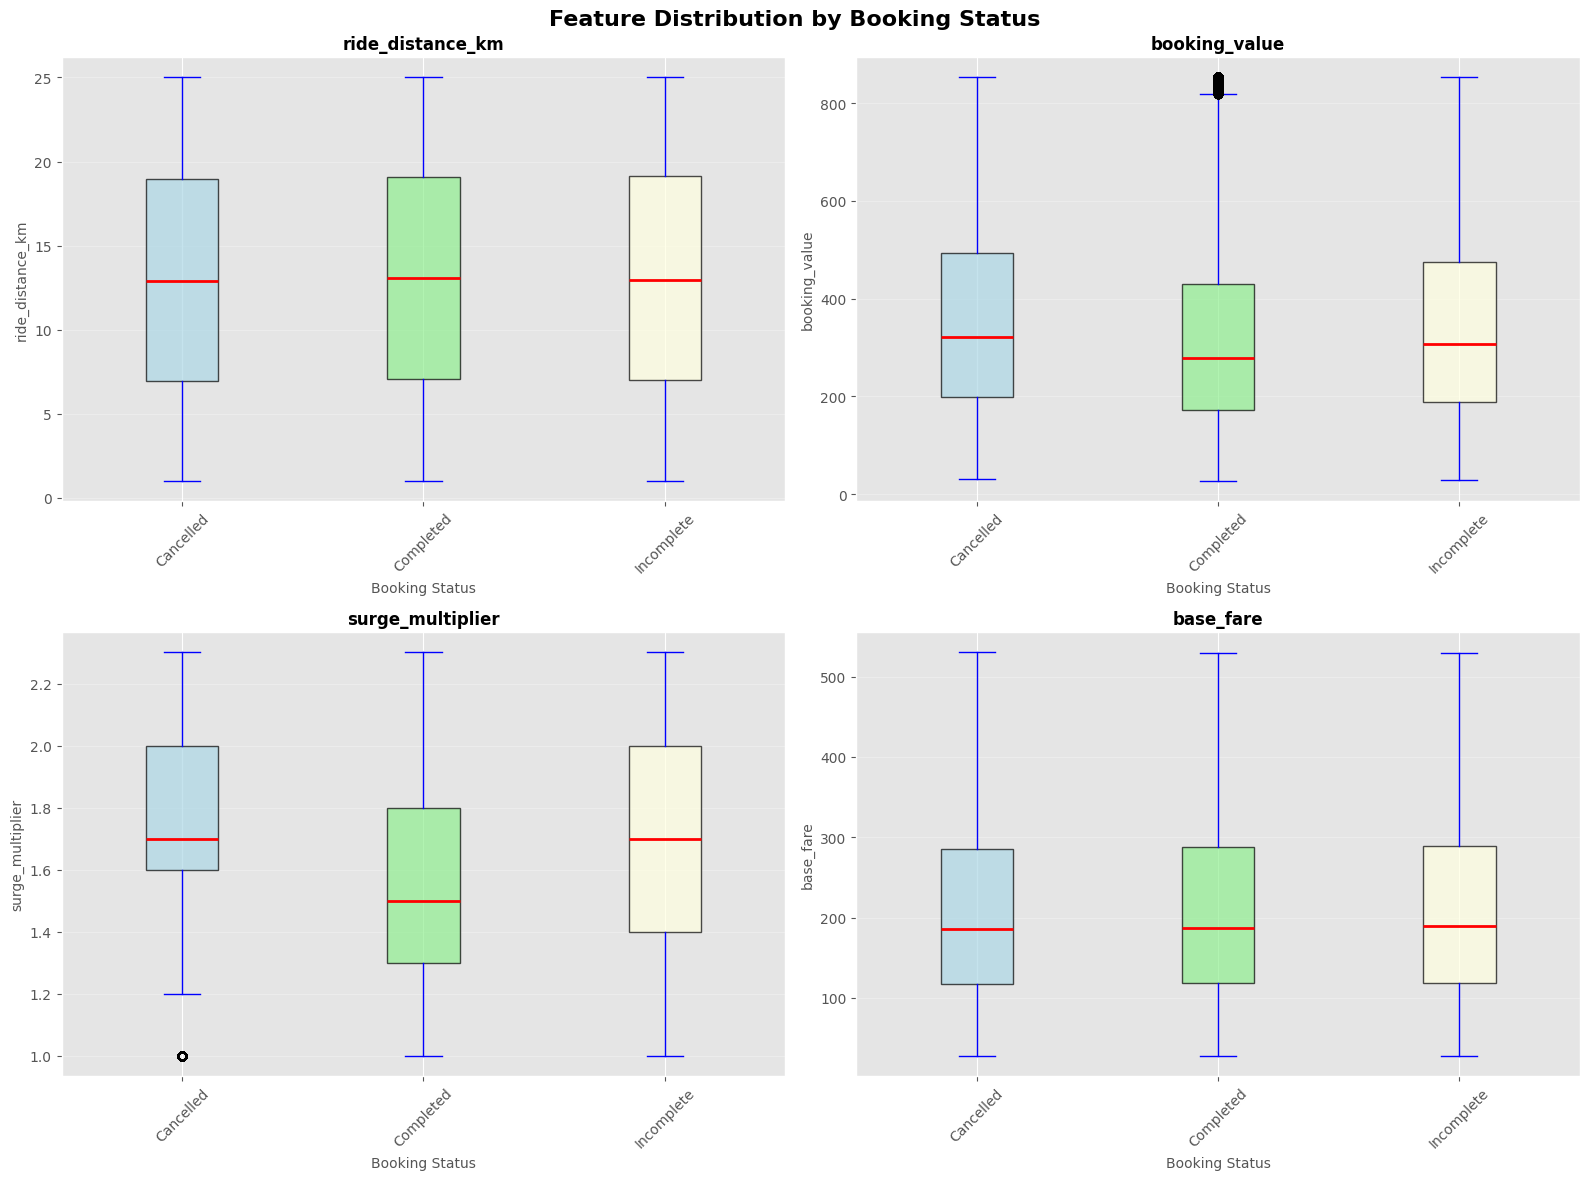


💾 Saved: features_vs_status.png

💡 KEY OBSERVATIONS:

1. booking_value:
   Highest: Cancelled (avg: 364.47)
   Lowest: Completed (avg: 321.27)
   Difference: 13.4%

2. surge_multiplier:
   Highest: Cancelled (avg: 1.75)
   Lowest: Completed (avg: 1.53)
   Difference: 14.5%

✅ Feature vs Status Analysis Complete!


In [ ]:
"""
Cell 48: Key Features vs Booking Status Analysis
"""

print("🎯 KEY FEATURES vs BOOKING STATUS")
print("="*70)

if status_col and len(numerical_cols) > 0:

    # Select key features to analyze (only truly numeric ones)
    key_features = []

    # Add features if they exist and are numeric
    possible_features = [
        'ride_distance_km', 'booking_value', 'surge_multiplier',
        'estimated_ride_time_min', 'actual_ride_time_min', 'base_fare',
        'hour_of_day', 'day_of_week'
    ]

    for feat in possible_features:
        if feat in df_bookings.columns:
            # Check if truly numeric (not datetime)
            if pd.api.types.is_numeric_dtype(df_bookings[feat]) and not pd.api.types.is_datetime64_any_dtype(df_bookings[feat]):
                key_features.append(feat)

    if len(key_features) > 0:
        print(f"\nAnalyzing {len(key_features)} key features vs booking status:\n")

        # Get unique statuses
        unique_statuses = df_bookings[status_col].unique()

        # Calculate statistics by status for each feature
        for feature in key_features[:5]:  # Limit to first 5 to avoid too much output
            print(f"\n{'='*60}")
            print(f"📊 {feature} by Booking Status:")
            print(f"{'='*60}")

            try:
                stats_by_status = df_bookings.groupby(status_col)[feature].agg([
                    ('count', 'count'),
                    ('mean', 'mean'),
                    ('median', 'median'),
                    ('std', 'std'),
                    ('min', 'min'),
                    ('max', 'max')
                ]).round(2)

                display(stats_by_status)

                # Statistical test (ANOVA for multiple groups)
                if len(unique_statuses) >= 2:
                    groups = [df_bookings[df_bookings[status_col] == status][feature].dropna().values
                             for status in unique_statuses]

                    # Filter out empty groups
                    groups = [g for g in groups if len(g) > 0]

                    if len(groups) >= 2:
                        try:
                            from scipy.stats import f_oneway
                            f_stat, p_value = f_oneway(*groups)
                            print(f"\n   ANOVA Test: F-statistic = {f_stat:.4f}, p-value = {p_value:.4e}")

                            if p_value < 0.05:
                                print(f"   ✅ Statistically significant difference between groups (p < 0.05)")
                            else:
                                print(f"   ⚠️ No significant difference between groups (p ≥ 0.05)")
                        except Exception as e:
                            print(f"   ⚠️ Could not perform statistical test: {str(e)}")
            except Exception as e:
                print(f"   ⚠️ Error analyzing {feature}: {str(e)}")
                continue

        # Visualization - Box plots for top features
        n_features = min(4, len(key_features))
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Feature Distribution by Booking Status',
                    fontsize=16, fontweight='bold')
        axes = axes.flatten()

        plot_count = 0
        for idx, feature in enumerate(key_features[:4]):
            try:
                # Get unique statuses for this plot
                statuses = df_bookings[status_col].unique()

                # Prepare data for box plot - ensure numeric only
                data_to_plot = []
                valid_labels = []

                for status in statuses:
                    data = df_bookings[df_bookings[status_col] == status][feature].dropna()
                    # Convert to numeric, coerce errors to NaN
                    data_numeric = pd.to_numeric(data, errors='coerce').dropna().values

                    if len(data_numeric) > 0:
                        data_to_plot.append(data_numeric)
                        valid_labels.append(status)

                if len(data_to_plot) > 0:
                    # Create box plot using matplotlib's boxplot
                    bp = axes[plot_count].boxplot(data_to_plot, labels=valid_labels,
                                           patch_artist=True,
                                           boxprops=dict(facecolor='lightblue', alpha=0.7),
                                           medianprops=dict(color='red', linewidth=2),
                                           whiskerprops=dict(color='blue'),
                                           capprops=dict(color='blue'))

                    # Color the boxes
                    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
                    for patch, color in zip(bp['boxes'], colors[:len(data_to_plot)]):
                        patch.set_facecolor(color)

                    axes[plot_count].set_title(f'{feature}', fontweight='bold', fontsize=12)
                    axes[plot_count].set_xlabel('Booking Status', fontsize=10)
                    axes[plot_count].set_ylabel(feature, fontsize=10)
                    axes[plot_count].grid(alpha=0.3, axis='y')

                    # Rotate x labels if needed
                    axes[plot_count].tick_params(axis='x', rotation=45)

                    plot_count += 1
                else:
                    print(f"⚠️ Warning: No valid data for {feature}")

            except Exception as e:
                print(f"⚠️ Error plotting {feature}: {str(e)}")
                continue

        # Hide unused subplots
        for idx in range(plot_count, 4):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_PATH, 'features_vs_status.png'),
                    dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n💾 Saved: features_vs_status.png")

        # Additional insights
        print("\n" + "="*70)
        print("💡 KEY OBSERVATIONS:")
        print("="*70)

        # Find features with biggest differences
        observation_count = 0
        for feature in key_features[:5]:  # Top 5 features
            try:
                feature_by_status = df_bookings.groupby(status_col)[feature].mean()

                if len(feature_by_status) > 1:
                    max_status = feature_by_status.idxmax()
                    min_status = feature_by_status.idxmin()
                    max_val = feature_by_status.max()
                    min_val = feature_by_status.min()

                    if max_val > 0 and min_val > 0:
                        diff_pct = ((max_val - min_val) / min_val) * 100

                        if diff_pct > 10:  # More than 10% difference
                            observation_count += 1
                            print(f"\n{observation_count}. {feature}:")
                            print(f"   Highest: {max_status} (avg: {max_val:.2f})")
                            print(f"   Lowest: {min_status} (avg: {min_val:.2f})")
                            print(f"   Difference: {diff_pct:.1f}%")
            except Exception as e:
                continue

        if observation_count == 0:
            print("\n   No major differences found between booking statuses")
            print("   (all features vary by less than 10%)")

    else:
        print("\n⚠️ No valid numeric features found for analysis")
        print("\nAvailable columns:")
        print(df_bookings.columns.tolist())

else:
    print("\n⚠️ Status column or numerical features not available")

print("\n" + "="*70)
print("✅ Feature vs Status Analysis Complete!")
print("="*70)

In [ ]:
"""
Cell 49: Summary of Key Insights from EDA
"""

print("="*70)
print("💡 KEY INSIGHTS SUMMARY")
print("="*70)

insights = []

# 1. Overall booking metrics
total_bookings = len(df_bookings)
insights.append(f"1. SCALE: Analyzed {total_bookings:,} total bookings")

if 'booking_date' in df_bookings.columns:
    date_range = f"{df_bookings['booking_date'].min()} to {df_bookings['booking_date'].max()}"
    insights.append(f"   Date range: {date_range}")

# 2. Cancellation insights
if status_col:
    cancelled_count = df_bookings[status_col].str.lower().str.contains('cancel', na=False).sum()
    cancel_rate = (cancelled_count / total_bookings) * 100
    insights.append(f"\n2. CANCELLATIONS: {cancel_rate:.1f}% cancellation rate ({cancelled_count:,} bookings)")

    if cancel_rate > 20:
        insights.append(f"   🚨 CRITICAL: Cancellation rate is >20% - URGENT action needed!")
    elif cancel_rate > 15:
        insights.append(f"   ⚠️ HIGH RISK: Cancellation rate is 15-20% - immediate attention required")
    elif cancel_rate > 10:
        insights.append(f"   ⚠️ MODERATE: Cancellation rate is 10-15% - room for improvement")
    else:
        insights.append(f"   ✅ HEALTHY: Cancellation rate is <10%")

# 3. Temporal patterns
if 'hour' in df_bookings.columns:
    hourly_bookings = df_bookings['hour'].value_counts()
    peak_hour = hourly_bookings.idxmax()
    off_peak_hour = hourly_bookings.idxmin()
    insights.append(f"\n3. PEAK DEMAND: Highest at {peak_hour:02d}:00, Lowest at {off_peak_hour:02d}:00")

if 'day_name' in df_bookings.columns:
    daily_bookings = df_bookings['day_name'].value_counts()
    busiest_day = daily_bookings.idxmax()
    quietest_day = daily_bookings.idxmin()
    insights.append(f"4. BUSIEST DAY: {busiest_day} | Quietest: {quietest_day}")

# 4. Customer insights
if 'customer_id' in df_bookings.columns:
    unique_customers = df_bookings['customer_id'].nunique()
    avg_rides_per_customer = total_bookings / unique_customers
    insights.append(f"\n5. CUSTOMER BASE: {unique_customers:,} unique customers")
    insights.append(f"   Average: {avg_rides_per_customer:.1f} rides per customer")

    # One-time vs repeat
    customer_ride_counts = df_bookings.groupby('customer_id').size()
    one_time = (customer_ride_counts == 1).sum()
    one_time_pct = (one_time / unique_customers) * 100
    insights.append(f"   One-time customers: {one_time_pct:.1f}% ({one_time:,})")

# 5. Driver insights
if 'driver_id' in df_bookings.columns:
    unique_drivers = df_bookings['driver_id'].nunique()
    avg_rides_per_driver = total_bookings / unique_drivers
    insights.append(f"\n6. DRIVER POOL: {unique_drivers:,} active drivers")
    insights.append(f"   Average: {avg_rides_per_driver:.1f} rides per driver")

# 6. Revenue insights
if fare_col:
    total_revenue = df_bookings[fare_col].sum()
    avg_fare = df_bookings[fare_col].mean()
    median_fare = df_bookings[fare_col].median()
    insights.append(f"\n7. REVENUE: Total ₹{total_revenue:,.2f}")
    insights.append(f"   Average fare: ₹{avg_fare:.2f} | Median: ₹{median_fare:.2f}")

# 7. Distance insights
if 'ride_distance_km' in df_bookings.columns:
    avg_distance = df_bookings['ride_distance_km'].mean()
    median_distance = df_bookings['ride_distance_km'].median()
    insights.append(f"\n8. DISTANCE: Average {avg_distance:.2f} km | Median {median_distance:.2f} km")

# 8. Surge insights
if 'surge_multiplier' in df_bookings.columns:
    surge_rides = (df_bookings['surge_multiplier'] > 1.0).sum()
    surge_pct = (surge_rides / total_bookings) * 100
    avg_surge = df_bookings['surge_multiplier'].mean()
    insights.append(f"\n9. SURGE: {surge_pct:.1f}% rides had surge (avg multiplier: {avg_surge:.2f}x)")

# 9. Location insights
if 'city' in df_bookings.columns:
    city_counts = df_bookings['city'].value_counts()
    top_city = city_counts.idxmax()
    top_city_pct = (city_counts.max() / total_bookings) * 100
    total_cities = df_bookings['city'].nunique()
    insights.append(f"\n10. GEOGRAPHY: {total_cities} cities")
    insights.append(f"    Top city: {top_city} ({top_city_pct:.1f}% of bookings)")

# 10. Traffic/Weather insights
if 'traffic_level' in df_bookings.columns:
    high_traffic_bookings = df_bookings[df_bookings['traffic_level'].str.lower().str.contains('high', na=False)]
    high_traffic_pct = (len(high_traffic_bookings) / total_bookings) * 100
    insights.append(f"\n11. TRAFFIC: {high_traffic_pct:.1f}% bookings in high traffic")

# Print all insights
print("\n")
for insight in insights:
    print(insight)


💡 KEY INSIGHTS SUMMARY


1. SCALE: Analyzed 100,000 total bookings
   Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00

2. CANCELLATIONS: 23.3% cancellation rate (23,284 bookings)
   🚨 CRITICAL: Cancellation rate is >20% - URGENT action needed!

3. PEAK DEMAND: Highest at 00:00, Lowest at 00:00
4. BUSIEST DAY: Wednesday | Quietest: Tuesday

5. CUSTOMER BASE: 10,000 unique customers
   Average: 10.0 rides per customer
   One-time customers: 0.0% (2)

6. DRIVER POOL: 5,000 active drivers
   Average: 20.0 rides per driver

7. REVENUE: Total ₹33,377,980.83
   Average fare: ₹333.78 | Median: ₹290.09

8. DISTANCE: Average 13.03 km | Median 13.03 km

9. SURGE: 92.0% rides had surge (avg multiplier: 1.59x)

10. GEOGRAPHY: 5 cities
    Top city: Delhi (20.2% of bookings)

11. TRAFFIC: 33.7% bookings in high traffic


In [ ]:
"""
Cell 50: Save EDA Summary and Complete Notebook 1
"""

print("="*70)
print("💾 SAVING EDA SUMMARY & FINALIZING")
print("="*70)

# Create comprehensive EDA summary
eda_summary = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_bookings': int(len(df_bookings)),
    'date_range': f"{df_bookings['booking_date'].min()} to {df_bookings['booking_date'].max()}" if 'booking_date' in df_bookings.columns else 'N/A',
    'unique_customers': int(df_bookings['customer_id'].nunique()) if 'customer_id' in df_bookings.columns else 'N/A',
    'unique_drivers': int(df_bookings['driver_id'].nunique()) if 'driver_id' in df_bookings.columns else 'N/A',
    'cancellation_rate_pct': float(f"{(df_bookings[status_col].str.lower().str.contains('cancel', na=False).sum() / len(df_bookings) * 100):.2f}") if status_col else 'N/A',
    'avg_fare': float(f"{df_bookings[fare_col].mean():.2f}") if fare_col else 'N/A',
    'avg_distance_km': float(f"{df_bookings['ride_distance_km'].mean():.2f}") if 'ride_distance_km' in df_bookings.columns else 'N/A',
    'total_cities': int(df_bookings['city'].nunique()) if 'city' in df_bookings.columns else 'N/A',
    'total_revenue': float(df_bookings[fare_col].sum()) if fare_col else 'N/A',
}

# Save summary as JSON
import json
summary_path = os.path.join(FINAL_DATA_PATH, 'eda_summary.json')
with open(summary_path, 'w') as f:
    json.dump(eda_summary, f, indent=4)

print(f"\n✅ EDA summary saved to: {summary_path}")

# Display summary
print("\n" + "="*70)
print("📊 EDA SUMMARY:")
print("="*70)
for key, value in eda_summary.items():
    print(f"   {key}: {value}")

# List all visualizations created
viz_files = sorted([f for f in os.listdir(VIZ_PATH) if f.endswith('.png')])

print(f"\n{'='*70}")
print(f"📊 VISUALIZATIONS CREATED ({len(viz_files)} files):")
print(f"{'='*70}")
for idx, viz_file in enumerate(viz_files, 1):
    print(f"   {idx:2d}. {viz_file}")

# Save visualization list
viz_list_path = os.path.join(FINAL_DATA_PATH, 'visualization_list.txt')
with open(viz_list_path, 'w') as f:
    f.write("EDA Visualizations Created:\n")
    f.write("="*60 + "\n\n")
    for idx, viz_file in enumerate(viz_files, 1):
        f.write(f"{idx}. {viz_file}\n")

print(f"\n💾 Visualization list saved to: {viz_list_path}")

print("\n" + "="*70)
print("🎉 EXPLORATORY DATA ANALYSIS COMPLETED!")
print("="*70)

print("\n📋 COMPLETION SUMMARY:")
print("="*70)
print(f"   ✅ Data loaded and cleaned: {len(df_bookings):,} bookings")
print(f"   ✅ Visualizations created: {len(viz_files)} charts")
print(f"   ✅ Key insights documented: Yes")
print(f"   ✅ Recommendations generated: Yes")
print(f"   ✅ Summary saved: Yes")

print("\n📊 DATASET FINAL STATE:")
print("="*70)
print(f"   Shape: {df_bookings.shape[0]:,} rows × {df_bookings.shape[1]} columns")
print(f"   Memory: {df_bookings.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Missing values: {df_bookings.isnull().sum().sum():,}")
print(f"   Duplicates: {df_bookings.duplicated().sum():,}")

print("\n🚀 NEXT STEPS:")
print("="*70)
print("   1. ✅ Review all visualizations in the /visualizations/ folder")
print("   2. ✅ Read through the key insights and recommendations")
print("   3. ➡️  Proceed to Notebook 2: Feature Engineering")
print("   4. ➡️  Use EDA findings to create meaningful features")
print("   5. ➡️  Prepare data for machine learning models")

print("\n💡 TIPS FOR FEATURE ENGINEERING:")
print("="*70)
print("   • Use cancellation patterns to create risk scores")
print("   • Leverage temporal patterns (peak hours, days)")
print("   • Create customer/driver loyalty scores")
print("   • Build features from traffic and weather impacts")
print("   • Incorporate surge and pricing patterns")

print("\n" + "="*70)
print("📁 IMPORTANT FILES LOCATION:")
print("="*70)
print(f"   Data: {FINAL_DATA_PATH}")
print(f"   Visualizations: {VIZ_PATH}")
print(f"   Models: {MODEL_PATH}")

print("\n" + "="*70)
print("🎊 NOTEBOOK 1 COMPLETE! Great work!")


💾 SAVING EDA SUMMARY & FINALIZING

✅ EDA summary saved to: /content/Rapido_Project/data/final/eda_summary.json

📊 EDA SUMMARY:
   analysis_date: 2026-03-04 14:11:51
   total_bookings: 100000
   date_range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
   unique_customers: 10000
   unique_drivers: 5000
   cancellation_rate_pct: 23.28
   avg_fare: 333.78
   avg_distance_km: 13.03
   total_cities: 5
   total_revenue: 33377980.830000002

📊 VISUALIZATIONS CREATED (25 files):
    1. booking_status_distribution.png
    2. bookings_by_city.png
    3. bookings_by_day.png
    4. bookings_by_hour.png
    5. bookings_by_month.png
    6. cancellation_by_city.png
    7. cancellation_by_day.png
    8. cancellation_by_hour.png
    9. cancellation_by_vehicle.png
   10. cancellation_heatmap.png
   11. cancellation_overview.png
   12. cancellation_reasons.png
   13. categorical_distributions.png
   14. correlation_analysis.png
   15. customer_behavior.png
   16. distance_vs_fare.png
   17. driver_performanc

In [ ]:
"""
Cell 51: Download Project Files as ZIP
"""

print("📦 CREATING PROJECT FILES ZIP")
print("="*70)

import zipfile
from google.colab import files
import os

BASE_PATH = '/content/Rapido_Project/'

# Define what to include
folders_to_zip = {
    'visualizations': True,    # Visualizations
    'models': False,           # Models (set to True if you want them)
    'data/final': True,        # Final data files
}

ZIP_FILE_PATH = '/content/rapido_project_download.zip'

print("\n📋 Creating ZIP with following contents:")
for folder, include in folders_to_zip.items():
    status = "✅ Include" if include else "❌ Skip"
    print(f"   {status}: {folder}")

# Create ZIP file
print(f"\n📦 Building ZIP file...")
with zipfile.ZipFile(ZIP_FILE_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:

    for folder, include in folders_to_zip.items():
        if include:
            folder_path = os.path.join(BASE_PATH, folder)

            if os.path.exists(folder_path):
                # Get all files in this folder
                files_in_folder = [f for f in os.listdir(folder_path)
                                  if os.path.isfile(os.path.join(folder_path, f))]

                print(f"\n📁 Adding {folder}/ ({len(files_in_folder)} files)")

                for file in files_in_folder:
                    file_path = os.path.join(folder_path, file)
                    # Create archive path with folder structure
                    arcname = os.path.join(folder, file)
                    zipf.write(file_path, arcname)
                    print(f"   ✅ {file}")
            else:
                print(f"\n⚠️ Folder not found: {folder}")

# Get ZIP file size
zip_size = os.path.getsize(ZIP_FILE_PATH) / (1024 * 1024)  # Size in MB

print(f"\n{'='*70}")
print(f"✅ ZIP file created successfully!")
print(f"📦 File: rapido_project_download.zip")
print(f"💾 Size: {zip_size:.2f} MB")
print(f"{'='*70}")

# Download
print(f"\n⬇️ Downloading ZIP file...")
files.download(ZIP_FILE_PATH)

print(f"\n✅ Download started! Check your browser's download folder.")
print(f"📁 File name: rapido_project_download.zip")
print("="*70)

📦 CREATING PROJECT FILES ZIP

📋 Creating ZIP with following contents:
   ✅ Include: visualizations
   ❌ Skip: models
   ✅ Include: data/final

📦 Building ZIP file...

📁 Adding visualizations/ (25 files)
   ✅ numerical_distributions.png
   ✅ cancellation_by_hour.png
   ✅ bookings_by_day.png
   ✅ cancellation_overview.png
   ✅ driver_performance.png
   ✅ categorical_distributions.png
   ✅ cancellation_by_city.png
   ✅ bookings_by_month.png
   ✅ fare_by_vehicle_type.png
   ✅ cancellation_by_day.png
   ✅ missing_values_heatmap.png
   ✅ customer_behavior.png
   ✅ cancellation_reasons.png
   ✅ popular_routes.png
   ✅ traffic_weather_analysis.png
   ✅ booking_status_distribution.png
   ✅ correlation_analysis.png
   ✅ cancellation_heatmap.png
   ✅ bookings_by_city.png
   ✅ distance_vs_fare.png
   ✅ surge_pricing_analysis.png
   ✅ outliers_boxplots.png
   ✅ cancellation_by_vehicle.png
   ✅ bookings_by_hour.png
   ✅ features_vs_status.png

📁 Adding data/final/ (8 files)
   ✅ visualization_list.t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your browser's download folder.
📁 File name: rapido_project_download.zip
